In [ ]:
%pip install -q \
    "pandas>=2.1,<2.3" \
    "numpy==1.26.4"\
    "shap==0.45.1"\
    "scipy>=1.11,<1.15" \
    "scikit-learn>=1.4,<1.6" \
    "pyarrow>=15.0" \
    "fastparquet>=2024.2.0" \
    "xgboost==2.0.3" \
    "lightgbm==4.3.0" \
    "optuna==3.6.1" \
    "umap-learn==0.5.5" \
    "imbalanced-learn==0.12.3" \
    "joblib>=1.3" \
    "tldextract>=5.1" \
    "statsmodels>=0.14"
print(" All dependencies installed with pinned versions.")
print("   Restart runtime ONLY if you see version conflict warnings above.")


✅ All dependencies installed with pinned versions.
   Restart runtime ONLY if you see version conflict warnings above.


In [ ]:
import os
import sys
import gc
import json
import time
import math
import random
import hashlib
import warnings
import platform
from pathlib import Path
from dataclasses import dataclass, field, asdict
from collections import defaultdict, Counter
from typing import Optional, Dict, List, Tuple, Any
import numpy as np
import pandas as pd
from scipy import stats as scipy_stats
from scipy import signal as scipy_signal
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.width", 200)
@dataclass
class QuicPipelineConfig:
    parquet_compression: str = "zstd"
    csv_sep: str = "|"
    min_packets_per_connection: int = 4
    max_gap_seconds: float = 30.0
    udp_ports_dns: tuple = (53, 5353)
    udp_ports_quic_default: tuple = (443, 80, 8443)
    udp_ports_ntp: tuple = (123,)
    udp_ports_stun: tuple = (3478, 19302)
    first_n_packets: int = 30
    burst_thresholds_sec: tuple = (0.01, 0.05, 0.1, 0.5)
    rate_bin_seconds: float = 0.5
    welch_min_samples: int = 16
    spin_min_transitions: int = 4
    spin_max_transition_rate: float = 0.5
    spin_min_transition_rate: float = 0.005
    markov_bins_default: tuple = (200, 800, 1300)
    n_jobs: int = -1
    joblib_batch_size: int = 32
    seed: int = SEED
CFG = QuicPipelineConfig()
print("=" * 72)
print("ENVIRONMENT")
print("=" * 72)
print(f"Python      : {sys.version.split()[0]}")
print(f"Platform    : {platform.platform()}")
print(f"NumPy       : {np.__version__}")
print(f"Pandas      : {pd.__version__}")
print(f"SciPy       : {scipy_stats.__name__.split('.')[0]} {__import__('scipy').__version__}")
print(f"PyArrow     : {__import__('pyarrow').__version__}")
print(f"Seed        : {SEED} (deterministic)")
print(f"CPU count   : {os.cpu_count()}")
try:
    import google.colab
    print("Runtime     : Google Colab")
    _IN_COLAB = True
except ImportError:
    print("Runtime     : Local / Other")
    _IN_COLAB = False
print(f"\n Configuration loaded. CFG fields: {len(asdict(CFG))} parameters.")


ENVIRONMENT
Python      : 3.12.13
Platform    : Linux-6.6.122+-x86_64-with-glibc2.35
NumPy       : 1.26.4
Pandas      : 2.2.2
SciPy       : scipy 1.14.1
PyArrow     : 18.1.0
Seed        : 42 (deterministic)
CPU count   : 2
Runtime     : Google Colab

✅ Configuration loaded. CFG fields: 19 parameters.


In [ ]:
if _IN_COLAB:
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
        print(" Google Drive mounted at /content/drive")
    except Exception as e:
        print(f"[WARN] Drive mount failed: {e}")
def _score_data_dir(path: Path) -> int:
    if not path.exists() or not path.is_dir():
        return -1
    try:
        files = [f for f in path.iterdir()
                 if f.is_file()
                 and f.suffix.lower() in (".csv", ".psv")
                 and not f.name.startswith("_")]
        return len(files)
    except PermissionError:
        return -1
def _resolve_data_dir() -> Path:
    override = os.environ.get("QUIC_DATA_DIR", "").strip()
    candidates: List[Path] = []
    if override:
        candidates.append(Path(override).expanduser())
    cwd = Path.cwd().resolve()
    candidates.extend([
        cwd / "quic-project" / "extracted_balanced",
        cwd / "quic-project" / "extracted",
        cwd / "quic_extracted",
        cwd / "data" / "quic_extracted",
        cwd / "extracted_balanced",
        cwd / "extracted",
        Path("/content/drive/MyDrive/quic-project/extracted_balanced"),
        Path("/content/drive/MyDrive/quic-project/extracted"),
        Path("/content/drive/MyDrive/quic_extracted"),
        Path("/content/drive/MyDrive/quic-data"),
    ])
    scored = [(p, _score_data_dir(p)) for p in candidates]
    scored = [(p, s) for p, s in scored if s > 0]
    if not scored:
        raise FileNotFoundError(
            "Could not locate any directory with .csv/.psv files.\n"
            "Set environment variable QUIC_DATA_DIR=/path/to/extracted/files\n"
            f"Searched: {[str(p) for p, _ in candidates[:6]]}..."
        )
    scored.sort(key=lambda x: x[1], reverse=True)
    return scored[0][0]
def _resolve_output_dir(name: str) -> Path:
    if _IN_COLAB:
        candidates = [
            Path(f"/content/drive/MyDrive/quic-project/{name}"),
            Path(f"/content/{name}"),
        ]
    else:
        candidates = [
            Path.cwd() / "quic-project" / name,
            Path.cwd() / name,
        ]
    for c in candidates:
        try:
            c.mkdir(parents=True, exist_ok=True)
            return c
        except PermissionError:
            continue
    fallback = Path.cwd() / name
    fallback.mkdir(parents=True, exist_ok=True)
    return fallback
RAW_DIR = _resolve_data_dir()
PROCESSED_DIR = _resolve_output_dir("quic_processed")
RESULTS_DIR = _resolve_output_dir("quic_results")
input_files = sorted([
    f for f in RAW_DIR.iterdir()
    if f.is_file() and f.suffix.lower() in (".csv", ".psv") and not f.name.startswith("_")
])
print("=" * 72)
print("PATHS RESOLVED")
print("=" * 72)
print(f" RAW data dir    : {RAW_DIR}")
print(f" Processed dir   : {PROCESSED_DIR}")
print(f" Results dir     : {RESULTS_DIR}")
print(f"\n Found {len(input_files)} input files:")
total_size_mb = 0.0
for f in input_files[:20]:
    sz = f.stat().st_size / 1e6
    total_size_mb += sz
    print(f"   {f.name:<55} {sz:>10.2f} MB")
if len(input_files) > 20:
    remaining = sum(f.stat().st_size for f in input_files[20:]) / 1e6
    total_size_mb += remaining
    print(f"   ... and {len(input_files) - 20} more files ({remaining:.1f} MB)")
print(f"\n   Total input size: {total_size_mb:,.1f} MB across {len(input_files)} files")
assert len(input_files) > 0, " No input files found — check RAW_DIR."


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted at /content/drive
PATHS RESOLVED
📁 RAW data dir    : /content/drive/MyDrive/quic_extracted
📁 Processed dir   : /content/drive/MyDrive/quic-project/quic_processed
📁 Results dir     : /content/drive/MyDrive/quic-project/quic_results

📦 Found 27 input files:
   background__idle_system__none__idle__027.psv                  0.06 MB
   file_transfer__cdn_image_burst__chrome__google_static_bulk__011.psv      13.88 MB
   file_transfer__cdn_image_burst__firefox__google_static_bulk__012.psv       3.82 MB
   file_transfer__drive_sample__chrome__drive_public_pdf__013.psv      13.73 MB
   general_browsing__mixed__chrome__long_walk__026.psv          17.55 MB
   social_media__facebook_public__chrome__scroll_marketplace__009.psv      13.45 MB
   social_media__instagram_explore__chrome__scroll_explore__007.psv      16.69 MB
   social_media__instagram_ex

In [ ]:
def md5_of_file(path: Path, chunk: int = 1 << 20) -> str:
    h = hashlib.md5()
    with open(path, "rb") as fh:
        while True:
            block = fh.read(chunk)
            if not block:
                break
            h.update(block)
    return h.hexdigest()
def safe_to_numeric(series: pd.Series, take_first_of_multivalue: bool = True) -> pd.Series:
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors="coerce")
    s = series.astype("string")
    if take_first_of_multivalue:
        s = s.str.split(",").str[0]
    s = s.str.strip().str.strip('"')
    s = s.replace({"": pd.NA, "nan": pd.NA, "None": pd.NA, "<NA>": pd.NA})
    return pd.to_numeric(s, errors="coerce")
def first_of_multivalue(series: pd.Series) -> pd.Series:
    if not pd.api.types.is_string_dtype(series) and series.dtype != object:
        return series
    s = series.astype("string").str.strip().str.strip('"')
    s = s.str.split(",").str[0]
    return s.replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})
def extract_etld_plus_one(hostname: Optional[str]) -> str:
    if hostname is None or pd.isna(hostname):
        return "unknown"
    h = str(hostname).strip().lower().split(",")[0]
    if not h:
        return "unknown"
    try:
        import tldextract
        ext = tldextract.extract(h)
        if ext.domain and ext.suffix:
            return f"{ext.domain}.{ext.suffix}"
        return h
    except Exception:
        parts = h.split(".")
        return ".".join(parts[-2:]) if len(parts) >= 2 else h
def signed_size_from_direction(frame_len: pd.Series, direction: pd.Series) -> pd.Series:
    sign = np.where(direction.values == "server_to_client", 1, -1).astype("int32")
    return (frame_len.astype("int32") * sign).astype("int32")
def estimate_initial_ttl(observed_ttl: float) -> Tuple[float, int]:
    if pd.isna(observed_ttl):
        return (np.nan, -1)
    ttl = int(observed_ttl)
    for initial in (64, 128, 255):
        if ttl <= initial:
            return (float(initial), int(initial - ttl))
    return (255.0, 255 - ttl)
def section(title: str, char: str = "=", width: int = 72) -> None:
    print(char * width)
    print(title)
    print(char * width)
class TeeLogger:
    def __init__(self):
        self.lines: List[str] = []
        self._stdout = sys.stdout
        self.terminal = sys.__stdout__
    def write(self, msg):
        self.terminal.write(msg)
        self._stdout.write(msg)
        if msg.strip():
            self.lines.append(msg)
    def flush(self):
        self._stdout.flush()
    def save(self, path: Path):
        path.write_text("".join(self.lines), encoding="utf-8")
_LOG = TeeLogger()
sys.stdout = _LOG._stdout
assert extract_etld_plus_one("fonts.gstatic.com") == "gstatic.com"
assert extract_etld_plus_one("www.googlevideo.com") == "googlevideo.com"
assert extract_etld_plus_one(None) == "unknown"
init_ttl, hops = estimate_initial_ttl(54)
assert init_ttl == 64 and hops == 10
print(" Utility helpers loaded and self-tested.")


✅ Utility helpers loaded and self-tested.


In [ ]:
import sys
LABEL_CANONICAL_MAP: Dict[str, str] = {
    "video_streaming":      "video_streaming",
    "youtube":              "video_streaming",
    "video":                "video_streaming",
    "social_media":         "social_media",
    "instagram":            "social_media",
    "facebook":             "social_media",
    "file_transfer":        "file_transfer",
    "cloud_storage":        "file_transfer",
    "drive":                "file_transfer",
    "web_browsing":         "web_browsing",
    "browsing":             "web_browsing",
    "general_browsing":     "general_browsing",
    "web_app":              "web_app",
    "search_information":   "web_browsing",
    "developer_platforms":  "web_browsing",
    "news_content":         "web_browsing",
    "ecommerce":            "web_browsing",
    "quic_validation":      "quic_validation",
    "unknown":              "unknown",
    "background":           "background",
}
LABEL_LEVEL = 0
def normalize_traffic_label(raw) -> str:
    if raw is None or (isinstance(raw, float) and math.isnan(raw)):
        return "unknown"
    v = str(raw).strip().lower()
    if v in ("", "nan", "none", "<na>"):
        return "unknown"
    if "__" in v:
        parts = v.split("__")
        if LABEL_LEVEL < len(parts):
            primary = parts[LABEL_LEVEL]
        else:
            primary = parts[0]
    else:
        primary = v
    return LABEL_CANONICAL_MAP.get(primary, primary)
def _infer_label_for_file(df: pd.DataFrame, stem: str) -> pd.Series:
    if "traffic_label" in df.columns and df["traffic_label"].notna().any():
        return df["traffic_label"].map(normalize_traffic_label)
    if "target_category" in df.columns and df["target_category"].notna().any():
        return df["target_category"].map(normalize_traffic_label).fillna("unknown")
    return pd.Series([normalize_traffic_label(stem)] * len(df), index=df.index, dtype="object")
def load_all_packet_files(data_dir: Path, files: List[Path]) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    frames: List[pd.DataFrame] = []
    manifest: Dict[str, Any] = {"files": {}, "global": {}}
    t0 = time.time()
    total_rows = 0
    for idx, path in enumerate(files, 1):
        stem = path.stem
        sys.__stdout__.write(f"  [{idx:>3}/{len(files)}] Loading {path.name} ... ")
        sys.__stdout__.flush()
        try:
            df = pd.read_csv(
                path,
                sep="|",
                dtype=str,
                na_values=["", "NA", "NaN", "null", "None"],
                keep_default_na=True,
                quotechar='"',
                engine="c",
                on_bad_lines="warn",
                low_memory=False,
            )
        except Exception as e:
            sys.__stderr__.write(f" FAILED ({path.name}) - {e}\n")
            continue
        if df.empty:
            sys.__stdout__.write("️  empty\n")
            continue
        df["source_file"] = stem
        df["traffic_label"] = _infer_label_for_file(df, stem)
        manifest["files"][stem] = {
            "path":  str(path),
            "rows":  len(df),
            "cols":  df.shape[1],
            "md5":   md5_of_file(path),
            "label_distribution": df["traffic_label"].value_counts().to_dict(),
        }
        total_rows += len(df)
        frames.append(df)
        sys.__stdout__.write(f" {len(df):,} rows, {df.shape[1]} cols\n")
    if not frames:
        raise RuntimeError("No files loaded successfully.")
    df_raw = pd.concat(frames, axis=0, ignore_index=True, sort=False)
    manifest["global"] = {
        "n_files":     len(manifest["files"]),
        "total_rows":  len(df_raw),
        "total_cols":  df_raw.shape[1],
        "load_time_s": round(time.time() - t0, 2),
    }
    return df_raw, manifest
section("LOADING ALL PACKET FILES")
df_raw, manifest = load_all_packet_files(RAW_DIR, input_files)
section("LOAD SUMMARY", char="-")
print(f"  Total rows           : {len(df_raw):,}")
print(f"  Total columns        : {df_raw.shape[1]}")
print(f"  Memory               : {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"  Load time            : {manifest['global']['load_time_s']:.1f}s")
print(f"\n  Label distribution (raw):")
label_dist = df_raw["traffic_label"].value_counts()
for lbl, cnt in label_dist.items():
    pct = cnt / len(df_raw) * 100
    print(f"    {lbl:<25} {cnt:>10,}  ({pct:5.2f}%)")
manifest_path = PROCESSED_DIR / "input_manifest.json"
manifest_path.write_text(json.dumps(manifest, indent=2, default=str))
print(f"\n Saved input manifest -> {manifest_path}")


LOADING ALL PACKET FILES
------------------------------------------------------------------------
LOAD SUMMARY
------------------------------------------------------------------------
  Total rows           : 1,017,419
  Total columns        : 47
  Memory               : 1944.7 MB
  Load time            : 43.2s

  Label distribution (raw):
    web_browsing                 301,540  (29.64%)
    video_streaming              271,033  (26.64%)
    social_media                 142,501  (14.01%)
    file_transfer                122,882  (12.08%)
    web_app                      109,338  (10.75%)
    general_browsing              69,882  ( 6.87%)
    background                       243  ( 0.02%)

💾 Saved input manifest -> /content/drive/MyDrive/quic-project/quic_processed/input_manifest.json


In [ ]:
SCHEMA_ALIASES: Dict[str, str] = {
    "tls_quic_parameter_initial_max_data": "quic_transport_parameter_initial_max_data",
    "tls_quic_parameter_initial_max_stream_data_bidi_local": "quic_transport_parameter_initial_max_stream_data_bidi_local",
    "tls_quic_parameter_initial_max_stream_data_bidi_remote": "quic_transport_parameter_initial_max_stream_data_bidi_remote",
    "tls_quic_parameter_initial_max_stream_data_uni": "quic_transport_parameter_initial_max_stream_data_uni",
    "tls_quic_parameter_initial_max_streams_bidi": "quic_transport_parameter_initial_max_streams_bidi",
    "tls_quic_parameter_initial_max_streams_uni": "quic_transport_parameter_initial_max_streams_uni",
    "tls_quic_parameter_max_idle_timeout": "quic_transport_parameter_max_idle_timeout",
    "tls_quic_parameter_max_udp_payload_size": "quic_transport_parameter_max_udp_payload_size",
    "tls_quic_parameter_active_connection_id_limit": "quic_transport_parameter_active_connection_id_limit",
    "tls_quic_parameter_max_ack_delay": "quic_transport_parameter_max_ack_delay",
    "tls_quic_parameter_ack_delay_exponent": "quic_transport_parameter_ack_delay_exponent",
    "quic_frame_type_ack_largest_acknowledged": "quic_ack_largest_acknowledged",
    "quic_frame_type_ack_ack_delay": "quic_ack_ack_delay",
    "quic_frame_type_ack_first_ack_range": "quic_ack_first_ack_range",
    "quic_frame_type_ack_ack_range_count": "quic_ack_ack_range_count",
    "tls_quic_parameter_google_user_agent": "google_user_agent",
    "tls_quic_parameter_google_initial_rtt": "google_initial_rtt",
}
ALWAYS_DROP_COLS: List[str] = [
    "quic_padding_length",
    "quic_padding",
    "quic_initial_payload",
    "quic_handshake_payload",
    "_ws_expert",
    "_ws_malformed",
]
def normalize_schema(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    rename_map = {old: new for old, new in SCHEMA_ALIASES.items() if old in df.columns}
    if rename_map:
        df = df.rename(columns=rename_map)
        print(f"  Renamed {len(rename_map)} columns to canonical names.")
    dropped = [c for c in ALWAYS_DROP_COLS if c in df.columns]
    if dropped:
        df = df.drop(columns=dropped)
        print(f"  Dropped {len(dropped)} unused columns: {dropped[:5]}{'...' if len(dropped) > 5 else ''}")
    df.columns = [c.replace(".", "_") for c in df.columns]
    return df
section("NORMALIZING SCHEMA", char="-")
df_raw = normalize_schema(df_raw)
families: Dict[str, List[str]] = defaultdict(list)
for col in df_raw.columns:
    if col.startswith("quic_transport_parameter_"):
        families["transport_params"].append(col)
    elif col.startswith("quic_ack_"):
        families["ack_frame"].append(col)
    elif col.startswith("quic_"):
        families["quic_header"].append(col)
    elif col.startswith("tls_"):
        families["tls"].append(col)
    elif col.startswith("ip"):
        families["ip"].append(col)
    elif col.startswith("udp_"):
        families["udp"].append(col)
    elif col.startswith("frame_"):
        families["frame"].append(col)
    else:
        families["other"].append(col)
print(f"\n  Column families present:")
for fam in sorted(families):
    print(f"    {fam:<22} {len(families[fam]):>3} columns")
REQUIRED_COLUMNS = {"frame_time_epoch", "frame_len"}
missing_required = REQUIRED_COLUMNS - set(df_raw.columns)
assert not missing_required, f" Missing required columns: {missing_required}"
print(f"\n  Required columns present : {sorted(REQUIRED_COLUMNS)}  ")
print(f"  Total columns after norm : {df_raw.shape[1]}")


------------------------------------------------------------------------
NORMALIZING SCHEMA
------------------------------------------------------------------------

  Column families present:
    ack_frame                4 columns
    frame                    3 columns
    ip                       8 columns
    other                    2 columns
    quic_header             13 columns
    tls                     14 columns
    udp                      3 columns

  Required columns present : ['frame_len', 'frame_time_epoch']  ✅
  Total columns after norm : 47


In [ ]:
NUMERIC_TARGET_DTYPES: Dict[str, str] = {
    "frame_time_epoch":      "float64",
    "frame_len":             "int32",
    "frame_cap_len":         "int32",
    "udp_srcport":           "int32",
    "udp_dstport":           "int32",
    "udp_length":            "int32",
    "ip_ttl":                "int16",
    "ipv6_hlim":             "int16",
    "ip_dsfield_dscp":       "int8",
    "ip_dsfield_ecn":        "int8",
    "quic_header_form":      "int8",
    "quic_fixed_bit":        "int8",
    "quic_long_packet_type": "int8",
    "quic_dcil":             "int16",
    "quic_scil":             "int16",
    "quic_token_length":     "int32",
    "quic_length":           "int32",
    "quic_spin_bit":         "int8",
    "quic_key_phase":        "int8",
    "quic_packet_number":    "int64",
    "quic_transport_parameter_initial_max_data":            "float64",
    "quic_transport_parameter_initial_max_stream_data_bidi_local":  "float64",
    "quic_transport_parameter_initial_max_stream_data_bidi_remote": "float64",
    "quic_transport_parameter_initial_max_stream_data_uni": "float64",
    "quic_transport_parameter_initial_max_streams_bidi":    "float64",
    "quic_transport_parameter_initial_max_streams_uni":     "float64",
    "quic_transport_parameter_max_idle_timeout":            "float64",
    "quic_transport_parameter_max_udp_payload_size":        "float64",
    "quic_transport_parameter_active_connection_id_limit":  "float64",
    "quic_transport_parameter_max_ack_delay":               "float64",
    "quic_transport_parameter_ack_delay_exponent":          "float64",
    "quic_ack_largest_acknowledged":  "float64",
    "quic_ack_ack_delay":              "float64",
    "quic_ack_first_ack_range":       "float64",
    "quic_ack_ack_range_count":       "float64",
}
STRING_KEEP_RAW: List[str] = [
    "quic_dcid", "quic_scid", "quic_version",
    "tls_handshake_type", "tls_handshake_extensions_server_name",
    "tls_handshake_extensions_alpn_str", "tls_handshake_ciphersuite",
]
def clean_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col in df.columns:
        if df[col].dtype == object:
            df[col] = (
                df[col].astype("string")
                       .str.strip()
                       .str.strip('"')
                       .replace({"": pd.NA})
            )
    coalesced_indicator = None
    for c in ("quic_header_form", "quic_long_packet_type", "quic_version", "quic_dcid"):
        if c in df.columns and df[c].dtype == object:
            coalesced_indicator = c
            break
    if coalesced_indicator is not None:
        df["is_coalesced"] = (
            df[coalesced_indicator].astype("string").str.contains(",", na=False).astype("int8")
        )
    else:
        df["is_coalesced"] = np.int8(0)
    if "ip_src" in df.columns or "ipv6_src" in df.columns:
        df["src_ip"] = df.get("ip_src", pd.Series(index=df.index, dtype="string"))
        df["dst_ip"] = df.get("ip_dst", pd.Series(index=df.index, dtype="string"))
        if "ipv6_src" in df.columns:
            df["src_ip"] = df["src_ip"].fillna(df["ipv6_src"])
            df["dst_ip"] = df["dst_ip"].fillna(df["ipv6_dst"])
    else:
        df["src_ip"] = pd.NA
        df["dst_ip"] = pd.NA
    if "ip_ttl" in df.columns or "ipv6_hlim" in df.columns:
        ttl_v4 = safe_to_numeric(df["ip_ttl"]) if "ip_ttl" in df.columns else pd.Series(np.nan, index=df.index)
        ttl_v6 = safe_to_numeric(df["ipv6_hlim"]) if "ipv6_hlim" in df.columns else pd.Series(np.nan, index=df.index)
        df["ttl"] = ttl_v4.fillna(ttl_v6).astype("float32")
    else:
        df["ttl"] = np.nan
    for col, target_dtype in NUMERIC_TARGET_DTYPES.items():
        if col not in df.columns:
            continue
        numeric = safe_to_numeric(df[col], take_first_of_multivalue=True)
        if target_dtype.startswith("int") and numeric.isna().any():
            df[col] = numeric.astype("float64")
        else:
            try:
                df[col] = numeric.astype(target_dtype)
            except (ValueError, TypeError, OverflowError):
                df[col] = numeric.astype("float64")
    if "quic_long_packet_type" in df.columns:
        ptype_map_int = {0: "Initial", 1: "0-RTT", 2: "Handshake", 3: "Retry"}
        df["packet_type_name"] = df["quic_long_packet_type"].map(ptype_map_int).astype("string")
    else:
        df["packet_type_name"] = pd.NA
    if "quic_header_form" in df.columns:
        hf = pd.to_numeric(df["quic_header_form"], errors="coerce")
        df["is_long_header"]  = (hf == 1).astype("int8")
        df["is_short_header"] = (hf == 0).astype("int8")
    else:
        df["is_long_header"]  = np.int8(0)
        df["is_short_header"] = np.int8(0)
    def _hex_byte_count(s: pd.Series) -> pd.Series:
        hex_str = s.astype("string").str.split(",").str[0].fillna("")
        cleaned = hex_str.str.replace(":", "", regex=False).str.replace(" ", "", regex=False)
        return (cleaned.str.len() // 2).astype("float32")
    if "quic_dcid" in df.columns:
        df["dcid_len_computed"] = _hex_byte_count(df["quic_dcid"])
        if "quic_dcil" in df.columns:
            df["dcid_len"] = df["quic_dcil"].astype("float32").fillna(df["dcid_len_computed"])
        else:
            df["dcid_len"] = df["dcid_len_computed"]
    if "quic_scid" in df.columns:
        df["scid_len_computed"] = _hex_byte_count(df["quic_scid"])
        if "quic_scil" in df.columns:
            df["scid_len"] = df["quic_scil"].astype("float32").fillna(df["scid_len_computed"])
        else:
            df["scid_len"] = df["scid_len_computed"]
    df = df.sort_values("frame_time_epoch", kind="mergesort").reset_index(drop=True)
    df["pkt_idx"] = np.arange(len(df), dtype="int64")
    return df
section("CLEANING & TYPE COERCION", char="-")
t0 = time.time()
df_clean = clean_dataframe(df_raw)
print(f"  Cleaned in {time.time() - t0:.1f}s")
print(f"  Rows               : {len(df_clean):,}")
print(f"  Columns            : {df_clean.shape[1]}")
print(f"  Memory             : {df_clean.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"  Coalesced packets  : {int(df_clean['is_coalesced'].sum()):,} "
      f"({df_clean['is_coalesced'].mean()*100:.2f}%)")
print(f"  Long-header packets: {int(df_clean['is_long_header'].sum()):,}")
print(f"  Short-header packs : {int(df_clean['is_short_header'].sum()):,}")
del df_raw
gc.collect()


------------------------------------------------------------------------
CLEANING & TYPE COERCION
------------------------------------------------------------------------
  Cleaned in 74.0s
  Rows               : 1,017,419
  Columns            : 59
  Memory             : 1828.9 MB
  Coalesced packets  : 0 (0.00%)
  Long-header packets: 10,149
  Short-header packs : 838,706


97

In [ ]:
KNOWN_QUIC_VERSIONS: set = {
    "00000001",
    "6b3343cf",
    "ff00001d", "ff00001c", "ff00001b", "ff00001a", "ff000019",
    "ff000018", "ff000017", "ff000016",
    "51303530", "51303531", "51303532", "51303533",
    "51303434", "51303433",
    "00000000",
}
def _hex_normalize(s) -> str:
    if pd.isna(s):
        return ""
    return str(s).strip().strip('"').split(",")[0].lower().replace(":", "").replace("0x", "")
def classify_flows_quic_vs_noise(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    n = len(df)
    ip_a = df["src_ip"].astype("string").fillna("")
    ip_b = df["dst_ip"].astype("string").fillna("")
    pt_a = df["udp_srcport"].astype("string").fillna("")
    pt_b = df["udp_dstport"].astype("string").fillna("")
    ep1, ep2 = ip_a + ":" + pt_a, ip_b + ":" + pt_b
    swap = (ep1 > ep2).values
    df["bidir_key"] = np.where(swap, ep2 + "|" + ep1, ep1 + "|" + ep2)
    has_long = (df.get("quic_header_form", pd.Series(0, index=df.index)) == 1)
    ver_norm = (df["quic_version"].apply(_hex_normalize)
                if "quic_version" in df.columns
                else pd.Series("", index=df.index))
    evidence_A = has_long & ver_norm.isin(KNOWN_QUIC_VERSIONS)
    flows_A = set(df.loc[evidence_A, "bidir_key"].unique())
    evidence_B = has_long & (ver_norm.str.len() > 0) & ~evidence_A
    flows_B = set(df.loc[evidence_B, "bidir_key"].unique()) - flows_A
    if "quic_fixed_bit" in df.columns:
        port443 = ((df["udp_srcport"] == 443) | (df["udp_dstport"] == 443))
        short_fb1 = ((df.get("quic_header_form") == 0) &
                     (df["quic_fixed_bit"] == 1) & port443)
        flows_C = set(df.loc[short_fb1, "bidir_key"].unique()) - flows_A - flows_B
    else:
        flows_C = set()
    quic_flows_all = flows_A | flows_B | flows_C
    df["is_quic"] = df["bidir_key"].isin(quic_flows_all).astype("int8")
    df["quic_confidence"] = np.where(df["bidir_key"].isin(flows_A), 1.00,
                              np.where(df["bidir_key"].isin(flows_B), 0.95,
                              np.where(df["bidir_key"].isin(flows_C), 0.70, 0.0))
                              ).astype("float32")
    sp = df.get("udp_srcport", pd.Series(-1, index=df.index)).fillna(-1).astype("int64").values
    dp = df.get("udp_dstport", pd.Series(-1, index=df.index)).fillna(-1).astype("int64").values
    unmarked = (df["is_quic"] == 0).values
    noise_class = np.array([""] * n, dtype=object)
    for ports, name in [(CFG.udp_ports_dns,  "dns"),
                        (CFG.udp_ports_ntp,  "ntp"),
                        (CFG.udp_ports_stun, "stun")]:
        m = unmarked & (np.isin(sp, ports) | np.isin(dp, ports))
        noise_class[m] = name
    noise_class[unmarked & (noise_class == "")] = "unknown_udp"
    df["noise_class"] = pd.Series(noise_class, index=df.index).replace("", pd.NA)
    return df
section("FLOW-LEVEL QUIC vs UDP NOISE CLASSIFICATION", char="-")
t0 = time.time()
df_clean = classify_flows_quic_vs_noise(df_clean)
print(f"  Classified in {time.time() - t0:.1f}s")
n_total = len(df_clean)
n_quic  = int(df_clean["is_quic"].sum())
n_noise = n_total - n_quic
n_quic_flows = df_clean.loc[df_clean["is_quic"] == 1, "bidir_key"].nunique()
print(f"\n  Total packets       : {n_total:,}")
print(f"  Identified as QUIC  : {n_quic:,}  ({n_quic / n_total * 100:.2f}%)")
print(f"  UDP noise / other   : {n_noise:,}  ({n_noise / n_total * 100:.2f}%)")
print(f"  Distinct QUIC flows : {n_quic_flows:,}")
print(f"\n  QUIC confidence distribution (per packet):")
conf_levels = [(1.00, "definitive (long-hdr, known version)"),
               (0.95, "high      (long-hdr, any version)"),
               (0.70, "probable  (short-hdr + fixed_bit + :443)")]
for lvl, label in conf_levels:
    n_lvl = int((df_clean["quic_confidence"] == lvl).sum())
    print(f"    {label:<42} {n_lvl:>10,}")
print(f"\n  UDP noise breakdown:")
for cls, cnt in df_clean.loc[df_clean["is_quic"] == 0, "noise_class"].value_counts().items():
    print(f"    {cls:<20} {cnt:>10,}")
df_noise = df_clean[df_clean["is_quic"] == 0].copy()
df_clean = df_clean[df_clean["is_quic"] == 1].copy().reset_index(drop=True)
print(f"\n  → Continuing with {len(df_clean):,} QUIC packets.")
print(f"  → {len(df_noise):,} noise packets parked in `df_noise` for Stage-1 classifier.")


------------------------------------------------------------------------
FLOW-LEVEL QUIC vs UDP NOISE CLASSIFICATION
------------------------------------------------------------------------
  Classified in 5.6s

  Total packets       : 1,017,419
  Identified as QUIC  : 1,007,546  (99.03%)
  UDP noise / other   : 9,873  (0.97%)
  Distinct QUIC flows : 950

  QUIC confidence distribution (per packet):
    definitive (long-hdr, known version)        1,007,546
    high      (long-hdr, any version)                   0
    probable  (short-hdr + fixed_bit + :443)            0

  UDP noise breakdown:
    dns                       9,740
    unknown_udp                 133

  → Continuing with 1,007,546 QUIC packets.
  → 9,873 noise packets parked in `df_noise` for Stage-1 classifier.


In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, precision_recall_fscore_support, confusion_matrix
print("=" * 72); print("STAGE-1 CLASSIFIER: QUIC vs UDP-NOISE"); print("=" * 72)
STAGE1_FEATURES = ["frame_len", "udp_length", "udp_srcport", "udp_dstport",
                   "quic_header_form", "quic_fixed_bit", "is_long_header",
                   "is_short_header"]
stage1_features_present = [c for c in STAGE1_FEATURES if c in df_clean.columns]
quic_pkts  = df_clean[stage1_features_present].copy()
quic_pkts["label"] = 1
n_noise_sample = min(len(df_noise), 5 * len(quic_pkts))
noise_pkts = df_noise[stage1_features_present].sample(n=n_noise_sample, random_state=SEED).copy()
noise_pkts["label"] = 0
stage1_data = pd.concat([quic_pkts, noise_pkts], ignore_index=True)
stage1_data = stage1_data.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
print(f"  Stage-1 dataset: {len(stage1_data):,} packets "
      f"({(stage1_data['label']==1).sum():,} QUIC, "
      f"{(stage1_data['label']==0).sum():,} noise)")
X1 = stage1_data[stage1_features_present].astype("float32").replace([np.inf, -np.inf], np.nan)
y1 = stage1_data["label"].values
X1_tr, X1_te, y1_tr, y1_te = train_test_split(
    X1, y1, test_size=0.20, random_state=SEED, stratify=y1
)
stage1_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    subsample=0.9, colsample_bytree=0.9,
    objective="binary:logistic", eval_metric="auc",
    tree_method="hist", random_state=SEED, n_jobs=-1,
)
t0 = time.time()
stage1_model.fit(X1_tr, y1_tr, eval_set=[(X1_te, y1_te)], verbose=False)
print(f"  Trained in {time.time() - t0:.1f}s")
y1_pred = stage1_model.predict(X1_te)
y1_prob = stage1_model.predict_proba(X1_te)[:, 1]
acc1  = accuracy_score(y1_te, y1_pred)
auc1  = roc_auc_score(y1_te, y1_prob)
prec, rec, f1_b, _ = precision_recall_fscore_support(y1_te, y1_pred, average="binary")
print(f"\n  Stage-1 results (held-out 20%):")
print(f"    Accuracy           : {acc1:.4f}")
print(f"    ROC-AUC            : {auc1:.4f}")
print(f"    Precision (QUIC)   : {prec:.4f}")
print(f"    Recall    (QUIC)   : {rec:.4f}")
print(f"    F1        (QUIC)   : {f1_b:.4f}")
cm = confusion_matrix(y1_te, y1_pred)
print(f"\n  Confusion matrix:")
print(f"               pred=noise  pred=QUIC")
print(f"    true=noise  {cm[0,0]:>9,}  {cm[0,1]:>9,}")
print(f"    true=QUIC   {cm[1,0]:>9,}  {cm[1,1]:>9,}")
import pickle
with open(Path(PROCESSED_DIR) / "stage1_quic_vs_noise.pkl", "wb") as f:
    pickle.dump({"model": stage1_model, "features": stage1_features_present,
                 "metrics": {"accuracy": acc1, "auc": auc1, "f1": f1_b,
                             "precision": prec, "recall": rec}}, f)
print(f"\n   Saved Stage-1 model to {Path(PROCESSED_DIR) / 'stage1_quic_vs_noise.pkl'}")


STAGE-1 CLASSIFIER: QUIC vs UDP-NOISE
  Stage-1 dataset: 1,017,419 packets (1,007,546 QUIC, 9,873 noise)
  Trained in 20.0s

  Stage-1 results (held-out 20%):
    Accuracy           : 1.0000
    ROC-AUC            : 1.0000
    Precision (QUIC)   : 1.0000
    Recall    (QUIC)   : 1.0000
    F1        (QUIC)   : 1.0000

  Confusion matrix:
               pred=noise  pred=QUIC
    true=noise      1,972          3
    true=QUIC           0    201,509

  💾 Saved Stage-1 model to /content/drive/MyDrive/quic-project/quic_processed/stage1_quic_vs_noise.pkl


In [ ]:
def assign_direction(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    n = len(df)
    ip_a = df["src_ip"].astype("string").fillna("")
    ip_b = df["dst_ip"].astype("string").fillna("")
    pt_a = df["udp_srcport"].astype("string").fillna("")
    pt_b = df["udp_dstport"].astype("string").fillna("")
    ep_src = ip_a + ":" + pt_a
    ep_dst = ip_b + ":" + pt_b
    swap = (ep_src > ep_dst).values
    bidir_key = np.where(swap, ep_dst + "|" + ep_src, ep_src + "|" + ep_dst)
    df["bidir_key"] = bidir_key
    client_map: Dict[str, str] = {}
    if "packet_type_name" in df.columns:
        initials = df[df["packet_type_name"] == "Initial"]
        if len(initials) > 0:
            earliest = initials.sort_values("frame_time_epoch").drop_duplicates("bidir_key", keep="first")
            for bk, sip in zip(earliest["bidir_key"], earliest["src_ip"]):
                if pd.notna(sip):
                    client_map[bk] = sip
    unresolved = set(df["bidir_key"].unique()) - set(client_map.keys())
    if unresolved:
        first_rows = (df[df["bidir_key"].isin(unresolved)]
                      .drop_duplicates("bidir_key", keep="first"))
        for _, row in first_rows.iterrows():
            bk = row["bidir_key"]
            sp = row.get("udp_srcport")
            dp = row.get("udp_dstport")
            sip, dip = row.get("src_ip"), row.get("dst_ip")
            if pd.isna(sp) or pd.isna(dp) or pd.isna(sip) or pd.isna(dip):
                continue
            if int(dp) == 443:
                client_map[bk] = sip
            elif int(sp) == 443:
                client_map[bk] = dip
            else:
                client_map[bk] = sip if int(sp) > int(dp) else dip
    df["client_ip"] = df["bidir_key"].map(client_map)
    is_client_src = (df["src_ip"] == df["client_ip"])
    df["direction"] = np.where(is_client_src, "client_to_server", "server_to_client")
    df["server_ip"] = np.where(is_client_src, df["dst_ip"], df["src_ip"])
    df["client_port"] = np.where(is_client_src, df["udp_srcport"], df["udp_dstport"]).astype("float32")
    df["server_port"] = np.where(is_client_src, df["udp_dstport"], df["udp_srcport"]).astype("float32")
    df["signed_size"] = signed_size_from_direction(df["frame_len"], df["direction"]).astype("int32")
    n_init  = sum(1 for bk in client_map if bk in df.loc[df.get("packet_type_name", pd.Series()) == "Initial",
                                                          "bidir_key"].unique())
    n_total_flows = df["bidir_key"].nunique()
    n_port = n_total_flows - n_init
    print(f"  Bidirectional flows  : {n_total_flows:,}")
    print(f"    Resolved by Initial: {n_init:,}")
    print(f"    Resolved by port   : {n_port:,}")
    print(f"  Direction distribution:")
    for d, cnt in df["direction"].value_counts().items():
        print(f"    {d:<25} {cnt:>10,}")
    return df
section("ASSIGNING DIRECTION", char="-")
df_clean = assign_direction(df_clean)
print(f"\n  signed_size range: [{df_clean['signed_size'].min():,}, "
      f"{df_clean['signed_size'].max():,}] bytes")


------------------------------------------------------------------------
ASSIGNING DIRECTION
------------------------------------------------------------------------
  Bidirectional flows  : 950
    Resolved by Initial: 950
    Resolved by port   : 0
  Direction distribution:
    server_to_client             890,318
    client_to_server             117,228

  signed_size range: [-1,296, 1,514] bytes


In [ ]:
print("df_clean shape:", df_clean.shape)
print()
print("Columns:", df_clean.columns.tolist())
print()
for col in ["frame_time_epoch", "client_ip", "server_ip",
            "client_port", "server_port", "packet_type_name"]:
    if col in df_clean.columns:
        non_null = df_clean[col].notna().sum()
        print(f"  {col:<20} non-null: {non_null:,} / {len(df_clean):,}")
    else:
        print(f"  {col:<20} MISSING")


df_clean shape: (1007546, 69)

Columns: ['traffic_label', 'source_file', 'frame_time_epoch', 'frame_len', 'frame_cap_len', 'ip_src', 'ip_dst', 'ipv6_src', 'ipv6_dst', 'ip_ttl', 'ipv6_hlim', 'ip_dsfield_dscp', 'ip_dsfield_ecn', 'udp_srcport', 'udp_dstport', 'udp_length', 'quic_header_form', 'quic_fixed_bit', 'quic_long_packet_type', 'quic_version', 'quic_dcid', 'quic_scid', 'quic_dcil', 'quic_scil', 'quic_token_length', 'quic_length', 'quic_spin_bit', 'quic_key_phase', 'quic_packet_number', 'quic_ack_largest_acknowledged', 'quic_ack_ack_delay', 'quic_ack_first_ack_range', 'quic_ack_ack_range_count', 'tls_quic_parameter_initial_max_data', 'tls_quic_parameter_initial_max_stream_data_bidi_local', 'tls_quic_parameter_initial_max_stream_data_bidi_remote', 'tls_quic_parameter_initial_max_stream_data_uni', 'tls_quic_parameter_initial_max_streams_bidi', 'tls_quic_parameter_initial_max_streams_uni', 'tls_quic_parameter_max_idle_timeout', 'tls_quic_parameter_max_udp_payload_size', 'tls_quic_param

In [ ]:
def reconstruct_connections(df: pd.DataFrame,
                             max_gap_seconds: float = CFG.max_gap_seconds) -> pd.DataFrame:
    df = df.copy()
    df = df.sort_values("frame_time_epoch", kind="mergesort").reset_index(drop=True)
    df["flow_key"] = (
        df["client_ip"].astype("string").fillna("") + "|" +
        df["server_ip"].astype("string").fillna("") + "|" +
        df["client_port"].astype("string").fillna("") + "|" +
        df["server_port"].astype("string").fillna("")
    )
    conn_ids = np.zeros(len(df), dtype="int64")
    current_id = 0
    for _, group in df.groupby("flow_key", sort=False):
        idx_array = group.index.to_numpy()
        ts_array = group["frame_time_epoch"].to_numpy()
        is_initial = (group.get("packet_type_name", pd.Series(index=group.index)) == "Initial").fillna(False).to_numpy()
        current_id += 1
        conn_ids[idx_array[0]] = current_id
        for i in range(1, len(idx_array)):
            gap = ts_array[i] - ts_array[i - 1]
            new_handshake = bool(is_initial[i]) and not bool(is_initial[i - 1])
            if gap > max_gap_seconds or new_handshake:
                current_id += 1
            conn_ids[idx_array[i]] = current_id
    df["connection_id"] = conn_ids
    n_conn = df["connection_id"].nunique()
    n_flows = df["flow_key"].nunique()
    print(f"  Reconstructed {n_conn:,} connections from {n_flows:,} flows")
    print(f"  Using max idle gap = {max_gap_seconds}s")
    sizes = df.groupby("connection_id").size()
    print(f"  Packets per connection:")
    print(f"    min    : {sizes.min()}")
    print(f"    25%ile : {int(sizes.quantile(0.25))}")
    print(f"    median : {int(sizes.median())}")
    print(f"    75%ile : {int(sizes.quantile(0.75))}")
    print(f"    max    : {sizes.max():,}")
    return df
section("CONNECTION RECONSTRUCTION", char="-")
df_clean = reconstruct_connections(df_clean)
small_conns = df_clean.groupby("connection_id").size()
keep_conns  = small_conns[small_conns >= CFG.min_packets_per_connection].index
n_dropped = (small_conns < CFG.min_packets_per_connection).sum()
n_dropped_pkts = int(small_conns[small_conns < CFG.min_packets_per_connection].sum())
df_clean = df_clean[df_clean["connection_id"].isin(keep_conns)].reset_index(drop=True)
print(f"\n  Dropped {n_dropped:,} connections with < {CFG.min_packets_per_connection} packets "
      f"({n_dropped_pkts:,} packets removed)")
print(f"  Final: {df_clean['connection_id'].nunique():,} connections, "
      f"{len(df_clean):,} packets")


------------------------------------------------------------------------
CONNECTION RECONSTRUCTION
------------------------------------------------------------------------
  Reconstructed 1,378 connections from 950 flows
  Using max idle gap = 30.0s
  Packets per connection:
    min    : 1
    25%ile : 6
    median : 11
    75%ile : 29
    max    : 100,396

  Dropped 99 connections with < 4 packets (286 packets removed)
  Final: 1,279 connections, 1,007,260 packets


In [ ]:
def build_connection_metadata(df: pd.DataFrame) -> pd.DataFrame:
    records: List[Dict[str, Any]] = []
    sni_col    = "tls_handshake_extensions_server_name"
    alpn_col   = "tls_handshake_extensions_alpn_str"
    ver_col    = "quic_version"
    cipher_col = "tls_handshake_ciphersuite"
    for conn_id, conn_df in df.groupby("connection_id", sort=False):
        conn_df = conn_df.sort_values("frame_time_epoch")
        rec: Dict[str, Any] = {"connection_id": int(conn_id)}
        rec["source_file"]    = conn_df["source_file"].iloc[0]
        rec["original_label"] = conn_df["traffic_label"].iloc[0]
        rec["client_ip"]      = conn_df["client_ip"].iloc[0]
        rec["server_ip"]      = conn_df["server_ip"].iloc[0]
        rec["client_port"]    = float(conn_df["client_port"].iloc[0]) if pd.notna(conn_df["client_port"].iloc[0]) else np.nan
        rec["server_port"]    = float(conn_df["server_port"].iloc[0]) if pd.notna(conn_df["server_port"].iloc[0]) else np.nan
        rec["start_time"]    = float(conn_df["frame_time_epoch"].iloc[0])
        rec["end_time"]      = float(conn_df["frame_time_epoch"].iloc[-1])
        rec["duration"]      = rec["end_time"] - rec["start_time"]
        rec["total_packets"] = int(len(conn_df))
        rec["total_bytes"]   = int(conn_df["frame_len"].sum())
        up_mask   = (conn_df["direction"] == "client_to_server").values
        down_mask = (conn_df["direction"] == "server_to_client").values
        rec["upload_packets"]   = int(up_mask.sum())
        rec["download_packets"] = int(down_mask.sum())
        rec["upload_bytes"]     = int(conn_df.loc[up_mask,   "frame_len"].sum())
        rec["download_bytes"]   = int(conn_df.loc[down_mask, "frame_len"].sum())
        if "packet_type_name" in conn_df.columns:
            ptypes = conn_df["packet_type_name"].dropna().unique().tolist()
            rec["has_initial"]   = int("Initial"   in ptypes)
            rec["has_0rtt"]      = int("0-RTT"     in ptypes)
            rec["has_handshake"] = int("Handshake" in ptypes)
            rec["has_retry"]     = int("Retry"     in ptypes)
        else:
            rec["has_initial"] = rec["has_0rtt"] = rec["has_handshake"] = rec["has_retry"] = 0
        def _first_str(col: str) -> Optional[str]:
            if col not in conn_df.columns:
                return None
            vals = conn_df[col].dropna()
            if len(vals) == 0:
                return None
            return str(vals.iloc[0]).split(",")[0].strip() or None
        rec["sni"]          = _first_str(sni_col)
        rec["alpn"]         = _first_str(alpn_col)
        rec["quic_version"] = _first_str(ver_col)
        rec["cipher_suite"] = _first_str(cipher_col)
        tp_cols = [c for c in conn_df.columns if c.startswith("quic_transport_parameter_")]
        for c in tp_cols:
            vals = conn_df[c].dropna()
            rec[c] = float(vals.iloc[0]) if len(vals) > 0 else np.nan
        rec["long_header_packets"]  = int(conn_df["is_long_header"].sum())
        rec["short_header_packets"] = int(conn_df["is_short_header"].sum())
        if "dcid_len" in conn_df.columns:
            d = conn_df["dcid_len"].dropna()
            rec["dcid_length"] = float(d.iloc[0]) if len(d) > 0 else np.nan
        if "quic_dcid" in conn_df.columns:
            rec["n_unique_dcids"] = int(conn_df["quic_dcid"].dropna().astype("string").nunique())
        else:
            rec["n_unique_dcids"] = 0
        if "ttl" in conn_df.columns:
            ttl_client = conn_df.loc[up_mask, "ttl"].dropna()
            if len(ttl_client) > 0:
                rec["client_ttl"] = int(ttl_client.iloc[0])
                init_ttl, hops = estimate_initial_ttl(rec["client_ttl"])
                rec["client_initial_ttl"] = init_ttl
                rec["estimated_hops"]     = hops
                rec["client_os_guess"] = (
                    "linux/mac/android" if init_ttl == 64 else
                    "windows"           if init_ttl == 128 else
                    "cisco/network_device" if init_ttl == 255 else "unknown"
                )
            else:
                rec["client_ttl"] = np.nan
                rec["client_os_guess"] = "unknown"
        if "ip_dsfield_ecn" in conn_df.columns:
            ecn_vals = conn_df["ip_dsfield_ecn"].dropna()
            rec["ecn_capable"] = int(len(ecn_vals) > 0 and (ecn_vals > 0).any())
        if "ip_dsfield_dscp" in conn_df.columns:
            dscp_vals = conn_df["ip_dsfield_dscp"].dropna()
            rec["dscp_value"] = int(dscp_vals.iloc[0]) if len(dscp_vals) > 0 else 0
        if "packet_type_name" in conn_df.columns:
            inits = conn_df.loc[conn_df["packet_type_name"] == "Initial", "frame_time_epoch"]
            rec["handshake_duration"] = float(inits.iloc[-1] - inits.iloc[0]) if len(inits) >= 2 else np.nan
        rec["quic_validity_score"] = float(conn_df["quic_confidence"].median())
        rec["traffic_label"] = rec["original_label"]
        sni_etld1 = extract_etld_plus_one(rec.get("sni")) if rec.get("sni") else "no_sni"
        rec["group_key"] = f"{rec['source_file']}::{sni_etld1}"
        records.append(rec)
    return pd.DataFrame(records)
section("BUILDING CONNECTION METADATA (file-level labels only)", char="-")
t0 = time.time()
conn_metadata = build_connection_metadata(df_clean)
print(f"  Built in {time.time() - t0:.1f}s")
print(f"  Total connections : {len(conn_metadata):,}")
print(f"  Columns           : {conn_metadata.shape[1]}")
print(f"\n  Label distribution (file-level, no SNI relabel):")
for lbl, cnt in conn_metadata["traffic_label"].value_counts().items():
    pct = cnt / len(conn_metadata) * 100
    print(f"    {lbl:<25} {cnt:>6,}  ({pct:5.2f}%)")
n_groups = conn_metadata["group_key"].nunique()
print(f"\n  Group-aware split readiness:")
print(f"    Distinct group_keys      : {n_groups:,}")
print(f"    Mean connections / group : {len(conn_metadata) / max(n_groups, 1):.1f}")
print(f"    Max connections / group  : {conn_metadata['group_key'].value_counts().max():,}")


------------------------------------------------------------------------
BUILDING CONNECTION METADATA (file-level labels only)
------------------------------------------------------------------------
  Built in 12.0s
  Total connections : 1,279
  Columns           : 38

  Label distribution (file-level, no SNI relabel):
    web_browsing                 434  (33.93%)
    video_streaming              293  (22.91%)
    general_browsing             281  (21.97%)
    web_app                      109  ( 8.52%)
    social_media                  91  ( 7.11%)
    file_transfer                 66  ( 5.16%)
    background                     5  ( 0.39%)

  Group-aware split readiness:
    Distinct group_keys      : 292
    Mean connections / group : 4.4
    Max connections / group  : 78


In [ ]:
packets_path = PROCESSED_DIR / "packets_clean.parquet"
df_clean.to_parquet(packets_path, index=False, compression=CFG.parquet_compression)
pkt_size_mb = packets_path.stat().st_size / 1e6
print(f" packets_clean.parquet      : {pkt_size_mb:>8.1f} MB  ({len(df_clean):,} rows)")
noise_path = PROCESSED_DIR / "udp_noise_packets.parquet"
df_noise.to_parquet(noise_path, index=False, compression=CFG.parquet_compression)
noise_size_mb = noise_path.stat().st_size / 1e6
print(f" udp_noise_packets.parquet  : {noise_size_mb:>8.1f} MB  ({len(df_noise):,} rows)")
meta_path = PROCESSED_DIR / "connection_metadata.parquet"
conn_metadata.to_parquet(meta_path, index=False, compression=CFG.parquet_compression)
print(f" connection_metadata.parquet: {meta_path.stat().st_size / 1e6:>8.1f} MB  "
      f"({len(conn_metadata):,} rows)")
conn_metadata.to_csv(PROCESSED_DIR / "connection_metadata.csv", index=False)
manifest["part1"] = {
    "n_quic_packets":      int(len(df_clean)),
    "n_noise_packets":     int(len(df_noise)),
    "n_connections":       int(len(conn_metadata)),
    "n_distinct_groups":   int(conn_metadata["group_key"].nunique()),
    "label_distribution":  conn_metadata["traffic_label"].value_counts().to_dict(),
    "pipeline_config":     asdict(CFG),
}
(PROCESSED_DIR / "input_manifest.json").write_text(json.dumps(manifest, indent=2, default=str))
section("DATA QUALITY DASHBOARD")
sz = conn_metadata["total_packets"]
print(f"\n1. CONNECTION SIZE DISTRIBUTION")
print(f"   min={sz.min()}, 25%={int(sz.quantile(0.25))}, median={int(sz.median())}, "
      f"75%={int(sz.quantile(0.75))}, max={sz.max():,}")
print(f"   Connections with 4-9 packets : {((sz >= 4) & (sz <= 9)).sum():,}  "
      f"(short — features will be noisy)")
print(f"   Connections with >=1000 pkts : {(sz >= 1000).sum():,}  (long — heavy traffic)")
sni_pct = conn_metadata["sni"].notna().mean() * 100
print(f"\n2. HANDSHAKE METADATA COVERAGE")
print(f"   SNI present          : {sni_pct:>5.1f}%")
print(f"   ALPN present         : {conn_metadata['alpn'].notna().mean() * 100:>5.1f}%")
print(f"   QUIC version present : {conn_metadata['quic_version'].notna().mean() * 100:>5.1f}%")
print(f"\n3. HANDSHAKE PACKET VISIBILITY")
for flag in ["has_initial", "has_handshake", "has_0rtt", "has_retry"]:
    print(f"   {flag:<18} : {conn_metadata[flag].mean() * 100:>5.1f}% of connections")
tp_cols = [c for c in conn_metadata.columns if c.startswith("quic_transport_parameter_")]
if tp_cols:
    print(f"\n4. TRANSPORT PARAMETER COVERAGE  ({len(tp_cols)} parameters)")
    for c in tp_cols:
        short = c.replace("quic_transport_parameter_", "")
        cov = conn_metadata[c].notna().mean() * 100
        print(f"   {short:<45} {cov:>5.1f}%")
print(f"\n5. CLASS IMBALANCE")
counts = conn_metadata["traffic_label"].value_counts()
imb = counts.max() / max(counts.min(), 1)
print(f"   Largest class  : {counts.idxmax()} ({counts.max():,})")
print(f"   Smallest class : {counts.idxmin()} ({counts.min():,})")
print(f"   Imbalance ratio: {imb:.1f}:1")
if imb > 10:
    print(f"   [️] High imbalance — class_weight='balanced' is mandatory in Part 3")
qv = conn_metadata["quic_validity_score"].dropna()
print(f"\n6. QUIC IDENTIFICATION QUALITY")
print(f"   Median QUIC-confidence per conn : {qv.median():.3f}")
print(f"   Connections with score < 0.7    : {(qv < 0.7).sum():,}  "
      f"(low-confidence — review or drop)")
del df_noise
gc.collect()
section(" PART 1 COMPLETE — ready for feature engineering (Cells 12+)")
print(f"   {len(df_clean):,} QUIC packets across {len(conn_metadata):,} connections")
print(f"   Output dir: {PROCESSED_DIR}")


💾 packets_clean.parquet      :      4.8 MB  (1,007,260 rows)
💾 udp_noise_packets.parquet  :      0.2 MB  (9,873 rows)
💾 connection_metadata.parquet:      0.1 MB  (1,279 rows)
DATA QUALITY DASHBOARD

1. CONNECTION SIZE DISTRIBUTION
   min=4, 25%=6, median=14, 75%=30, max=100,396
   Connections with 4-9 packets : 553  (short — features will be noisy)
   Connections with >=1000 pkts : 63  (long — heavy traffic)

2. HANDSHAKE METADATA COVERAGE
   SNI present          :  67.7%
   ALPN present         :  67.7%
   QUIC version present :  99.9%

3. HANDSHAKE PACKET VISIBILITY
   has_initial        :  99.9% of connections
   has_handshake      :  75.0% of connections
   has_0rtt           :   5.2% of connections
   has_retry          :   0.0% of connections

5. CLASS IMBALANCE
   Largest class  : web_browsing (434)
   Smallest class : background (5)
   Imbalance ratio: 86.8:1
   [⚠️] High imbalance — class_weight='balanced' is mandatory in Part 3

6. QUIC IDENTIFICATION QUALITY
   Median QUIC-c

In [ ]:
def safe_stats(arr: np.ndarray, prefix: str = "") -> Dict[str, float]:
    arr = np.asarray(arr, dtype="float64")
    arr = arr[~np.isnan(arr)]
    n = arr.size
    keys = ("count", "sum", "mean", "median", "min", "max", "range",
            "std", "var", "cv", "skew", "kurtosis",
            "p5", "p10", "p25", "p75", "p90", "p95", "p99", "iqr",
            "mad")
    out = {f"{prefix}{k}" if prefix else k: np.nan for k in keys}
    out[f"{prefix}count" if prefix else "count"] = n
    if n == 0:
        return out
    out[f"{prefix}sum"]    = float(arr.sum())
    out[f"{prefix}mean"]   = float(arr.mean())
    out[f"{prefix}median"] = float(np.median(arr))
    out[f"{prefix}min"]    = float(arr.min())
    out[f"{prefix}max"]    = float(arr.max())
    out[f"{prefix}range"]  = out[f"{prefix}max"] - out[f"{prefix}min"]
    out[f"{prefix}mad"]    = float(np.median(np.abs(arr - out[f"{prefix}median"])))
    if n >= 2:
        out[f"{prefix}std"] = float(arr.std(ddof=1))
        out[f"{prefix}var"] = float(arr.var(ddof=1))
        mean_val = out[f"{prefix}mean"]
        out[f"{prefix}cv"]  = float(out[f"{prefix}std"] / mean_val) if mean_val != 0 else np.nan
    if n >= 3:
        out[f"{prefix}skew"] = float(scipy_stats.skew(arr, bias=False))
    if n >= 4:
        out[f"{prefix}kurtosis"] = float(scipy_stats.kurtosis(arr, bias=False))
    pcts = np.percentile(arr, [5, 10, 25, 75, 90, 95, 99])
    out[f"{prefix}p5"]  = float(pcts[0]); out[f"{prefix}p10"] = float(pcts[1])
    out[f"{prefix}p25"] = float(pcts[2]); out[f"{prefix}p75"] = float(pcts[3])
    out[f"{prefix}p90"] = float(pcts[4]); out[f"{prefix}p95"] = float(pcts[5])
    out[f"{prefix}p99"] = float(pcts[6])
    out[f"{prefix}iqr"] = float(pcts[3] - pcts[2])
    return out
def shannon_entropy(arr: np.ndarray, n_bins: int = 30) -> float:
    arr = np.asarray(arr, dtype="float64")
    arr = arr[~np.isnan(arr)]
    if arr.size < 2 or arr.max() == arr.min():
        return np.nan
    counts, _ = np.histogram(arr, bins=n_bins)
    total = counts.sum()
    if total == 0:
        return np.nan
    p = counts[counts > 0] / total
    return float(-np.sum(p * np.log2(p)))
def autocorrelation(arr: np.ndarray, lag: int) -> float:
    arr = np.asarray(arr, dtype="float64")
    if arr.size <= lag + 1:
        return np.nan
    mean = arr.mean()
    var  = arr.var()
    if var == 0:
        return np.nan
    centered = arr - mean
    return float((centered[:-lag] * centered[lag:]).sum() / (var * (arr.size - lag)))
def detect_bursts(timestamps: np.ndarray,
                  sizes: np.ndarray,
                  threshold_sec: float,
                  min_packets: int = 2,
                  min_bytes: int = 200) -> List[Dict[str, float]]:
    n = timestamps.size
    if n < 2:
        return []
    bursts: List[Dict[str, float]] = []
    start_idx = 0
    for i in range(1, n):
        if timestamps[i] - timestamps[i - 1] >= threshold_sec:
            end_idx = i - 1
            n_pkts  = end_idx - start_idx + 1
            n_bytes = int(sizes[start_idx:end_idx + 1].sum())
            if n_pkts >= min_packets and n_bytes >= min_bytes:
                bursts.append({
                    "start_time": float(timestamps[start_idx]),
                    "end_time":   float(timestamps[end_idx]),
                    "duration":   float(timestamps[end_idx] - timestamps[start_idx]),
                    "n_packets":  int(n_pkts),
                    "n_bytes":    int(n_bytes),
                })
            start_idx = i
    end_idx = n - 1
    n_pkts  = end_idx - start_idx + 1
    n_bytes = int(sizes[start_idx:end_idx + 1].sum())
    if n_pkts >= min_packets and n_bytes >= min_bytes:
        bursts.append({
            "start_time": float(timestamps[start_idx]),
            "end_time":   float(timestamps[end_idx]),
            "duration":   float(timestamps[end_idx] - timestamps[start_idx]),
            "n_packets":  int(n_pkts),
            "n_bytes":    int(n_bytes),
        })
    return bursts
_test = safe_stats(np.array([1.0, 2.0, 3.0, 4.0, 5.0]))
assert abs(_test["mean"] - 3.0) < 1e-9
assert abs(_test["median"] - 3.0) < 1e-9
assert abs(shannon_entropy(np.array([1, 1, 2, 2, 3, 3, 4, 4]), n_bins=4) - 2.0) < 1e-6
_bursts = detect_bursts(
    np.array([0.0, 0.01, 0.02, 5.0, 5.01]),
    np.array([1000, 1000, 1000, 1000, 1000]),
    threshold_sec=0.05
)
assert len(_bursts) == 2, f"Expected 2 bursts, got {len(_bursts)}"
assert _bursts[0]["n_packets"] == 3
assert _bursts[0]["n_bytes"] == 3000
assert abs(_bursts[0]["start_time"] - 0.0) < 1e-9
assert abs(_bursts[0]["end_time"] - 0.02) < 1e-9
assert abs(_bursts[0]["duration"] - 0.02) < 1e-9
assert _bursts[1]["n_packets"] == 2
assert _bursts[1]["n_bytes"] == 2000
assert abs(_bursts[1]["start_time"] - 5.0) < 1e-9
assert abs(_bursts[1]["end_time"] - 5.01) < 1e-9
assert abs(_bursts[1]["duration"] - 0.01) < 1e-6
print(" Feature-engineering helpers loaded and self-tested.")


✅ Feature-engineering helpers loaded and self-tested.


In [ ]:
def _need_reload() -> bool:
    needed = ("df_clean", "conn_metadata", "PROCESSED_DIR", "CFG")
    return any(name not in globals() for name in needed)
if _need_reload():
    print("[INFO] Reloading from checkpoint files...")
    if "CFG" not in globals():
        raise RuntimeError("Run Cells 1-2 first to set up CFG and paths.")
    packets_path = PROCESSED_DIR / "packets_clean.parquet"
    meta_path    = PROCESSED_DIR / "connection_metadata.parquet"
    assert packets_path.exists(), f"Missing {packets_path}; run Cells 4-11 first."
    assert meta_path.exists(),    f"Missing {meta_path}; run Cells 4-11 first."
    df_clean      = pd.read_parquet(packets_path)
    conn_metadata = pd.read_parquet(meta_path)
    print(f"   Reloaded {len(df_clean):,} packets and {len(conn_metadata):,} connections")
else:
    print(f" In-memory state present:")
    print(f"   df_clean      : {len(df_clean):,} rows")
    print(f"   conn_metadata : {len(conn_metadata):,} rows")
CONN_META_BY_ID: Dict[int, Dict[str, Any]] = {
    int(row["connection_id"]): row.to_dict()
    for _, row in conn_metadata.iterrows()
}
print(f"   CONN_META_BY_ID indexed for {len(CONN_META_BY_ID):,} connections (O(1) lookup)")


✅ In-memory state present:
   df_clean      : 1,007,260 rows
   conn_metadata : 1,279 rows
   CONN_META_BY_ID indexed for 1,279 connections (O(1) lookup)


In [ ]:
def compute_packet_size_features(conn_df: pd.DataFrame) -> Dict[str, float]:
    feats: Dict[str, float] = {}
    sizes_all  = conn_df["frame_len"].to_numpy(dtype="float64")
    dir_arr    = conn_df["direction"].to_numpy()
    sizes_up   = sizes_all[dir_arr == "client_to_server"]
    sizes_down = sizes_all[dir_arr == "server_to_client"]
    for arr, prefix in ((sizes_all, "pkt_size_all_"),
                        (sizes_up,  "pkt_size_up_"),
                        (sizes_down,"pkt_size_down_")):
        feats.update(safe_stats(arr, prefix=prefix))
    n = sizes_all.size
    if n > 0:
        feats["pkt_small_ratio"]  = float((sizes_all < 100).sum() / n)
        feats["pkt_medium_ratio"] = float(((sizes_all >= 100) & (sizes_all < 500)).sum() / n)
        feats["pkt_large_ratio"]  = float((sizes_all >= 1200).sum() / n)
        feats["pkt_mtu_ratio"]    = float((sizes_all >= 1400).sum() / n)
    else:
        for k in ("pkt_small_ratio", "pkt_medium_ratio", "pkt_large_ratio", "pkt_mtu_ratio"):
            feats[k] = np.nan
    up_bytes   = float(sizes_up.sum())   if sizes_up.size   else 0.0
    down_bytes = float(sizes_down.sum()) if sizes_down.size else 0.0
    total      = up_bytes + down_bytes
    feats["byte_ratio_down_up"]      = down_bytes / max(up_bytes,   1.0)
    feats["byte_ratio_up_down"]      = up_bytes   / max(down_bytes, 1.0)
    feats["download_byte_fraction"]  = down_bytes / max(total,      1.0)
    feats["upload_byte_fraction"]    = up_bytes   / max(total,      1.0)
    feats["pkt_ratio_down_up"]       = sizes_down.size / max(sizes_up.size, 1)
    feats["download_pkt_fraction"]   = sizes_down.size / max(n, 1)
    feats["has_upload"]              = int(sizes_up.size > 0)
    feats["has_download"]            = int(sizes_down.size > 0)
    feats["pkt_size_entropy_all"]    = shannon_entropy(sizes_all,  n_bins=30)
    feats["pkt_size_entropy_up"]     = shannon_entropy(sizes_up,   n_bins=30)
    feats["pkt_size_entropy_down"]   = shannon_entropy(sizes_down, n_bins=30)
    feats["n_distinct_sizes_all"]    = int(np.unique(sizes_all).size)
    feats["n_distinct_sizes_up"]     = int(np.unique(sizes_up).size)
    feats["n_distinct_sizes_down"]   = int(np.unique(sizes_down).size)
    if n > 0:
        vals, counts = np.unique(sizes_all, return_counts=True)
        argmax = int(np.argmax(counts))
        feats["pkt_size_mode"]      = float(vals[argmax])
        feats["pkt_size_mode_freq"] = float(counts[argmax] / n)
    else:
        feats["pkt_size_mode"] = feats["pkt_size_mode_freq"] = np.nan
    return feats
_test_conn = df_clean[df_clean["connection_id"] == df_clean["connection_id"].iloc[0]]
_test_feats = compute_packet_size_features(_test_conn)
print(f" Group A — packet size features: {len(_test_feats)} features per connection")
print(f"   Sample (first 5): {dict(list(_test_feats.items())[:5])}")


✅ Group A — packet size features: 83 features per connection
   Sample (first 5): {'pkt_size_all_count': 25, 'pkt_size_all_sum': 16211.0, 'pkt_size_all_mean': 648.44, 'pkt_size_all_median': 379.0, 'pkt_size_all_min': 90.0}


In [ ]:
def compute_iat_features(conn_df: pd.DataFrame) -> Dict[str, float]:
    feats: Dict[str, float] = {}
    ts_all  = conn_df["frame_time_epoch"].to_numpy(dtype="float64")
    dir_arr = conn_df["direction"].to_numpy()
    ts_up   = ts_all[dir_arr == "client_to_server"]
    ts_down = ts_all[dir_arr == "server_to_client"]
    def _iat(ts):
        if ts.size < 2:
            return np.empty(0, dtype="float64")
        iats = np.diff(ts)
        return iats[iats >= 0]
    iat_all  = _iat(ts_all)
    iat_up   = _iat(ts_up)
    iat_down = _iat(ts_down)
    feats.update(safe_stats(iat_all,  prefix="iat_all_"))
    feats.update(safe_stats(iat_up,   prefix="iat_up_"))
    feats.update(safe_stats(iat_down, prefix="iat_down_"))
    if iat_all.size > 0:
        feats["iat_sub_1ms_ratio"]  = float((iat_all < 0.001).sum() / iat_all.size)
        feats["iat_sub_10ms_ratio"] = float((iat_all < 0.010).sum() / iat_all.size)
        feats["iat_sub_50ms_ratio"] = float((iat_all < 0.050).sum() / iat_all.size)
        feats["iat_over_1s_ratio"]  = float((iat_all > 1.0).sum()   / iat_all.size)
    else:
        for k in ("iat_sub_1ms_ratio", "iat_sub_10ms_ratio",
                  "iat_sub_50ms_ratio", "iat_over_1s_ratio"):
            feats[k] = np.nan
    feats["iat_entropy"]        = shannon_entropy(iat_all, n_bins=30)
    feats["iat_autocorr_lag1"]  = autocorrelation(iat_all, lag=1)
    feats["iat_autocorr_lag2"]  = autocorrelation(iat_all, lag=2)
    feats["iat_autocorr_lag5"]  = autocorrelation(iat_all, lag=5)
    if iat_all.size > 1 and iat_all.std() > 0 and iat_all.mean() > 0:
        sigma, mu = iat_all.std(), iat_all.mean()
        feats["iat_burstiness"] = float((sigma - mu) / (sigma + mu))
    else:
        feats["iat_burstiness"] = np.nan
    return feats
_test_feats = compute_iat_features(_test_conn)
print(f" Group B — IAT features: {len(_test_feats)} features per connection")


✅ Group B — IAT features: 72 features per connection


In [ ]:
def _resample_throughput(ts: np.ndarray, sizes: np.ndarray,
                          bin_sec: float = 0.010) -> Tuple[np.ndarray, float]:
    if ts.size < 2:
        return np.array([], dtype="float64"), 0.0
    t0, t1 = ts[0], ts[-1]
    duration = max(t1 - t0, bin_sec)
    n_bins = max(int(np.ceil(duration / bin_sec)), 2)
    edges = np.linspace(t0, t0 + n_bins * bin_sec, n_bins + 1)
    binned, _ = np.histogram(ts, bins=edges, weights=sizes)
    return binned.astype("float64"), 1.0 / bin_sec
def compute_burst_features(conn_df: pd.DataFrame) -> Dict[str, float]:
    feats: Dict[str, float] = {}
    sorted_df = conn_df.sort_values("frame_time_epoch")
    ts    = sorted_df["frame_time_epoch"].to_numpy(dtype="float64")
    sizes = sorted_df["frame_len"].to_numpy(dtype="float64")
    n = ts.size
    if n < 2:
        return feats
    for win_sec in CFG.burst_thresholds_sec:
        gaps = np.diff(ts)
        burst_starts = np.concatenate(([0], np.where(gaps > win_sec)[0] + 1))
        burst_ends   = np.concatenate((np.where(gaps > win_sec)[0], [n - 1]))
        burst_lens   = burst_ends - burst_starts + 1
        burst_bytes  = np.array([sizes[s:e+1].sum() for s, e in zip(burst_starts, burst_ends)])
        burst_durs   = ts[burst_ends] - ts[burst_starts]
        prefix = f"burst_{int(win_sec*1000)}ms"
        feats[f"{prefix}_count"]        = len(burst_lens)
        feats[f"{prefix}_pkts_mean"]    = float(burst_lens.mean())
        feats[f"{prefix}_pkts_max"]     = int(burst_lens.max())
        feats[f"{prefix}_bytes_mean"]   = float(burst_bytes.mean())
        feats[f"{prefix}_bytes_max"]    = float(burst_bytes.max())
        feats[f"{prefix}_dur_mean"]     = float(burst_durs.mean())
        feats[f"{prefix}_dur_max"]      = float(burst_durs.max())
        feats[f"{prefix}_frequency"]    = len(burst_lens) / max(ts[-1] - ts[0], 1e-9)
    if n > 2:
        med_iat = np.median(np.diff(ts))
        adaptive_thr = max(med_iat * 5, 0.001)
        gaps = np.diff(ts)
        burst_starts = np.concatenate(([0], np.where(gaps > adaptive_thr)[0] + 1))
        burst_ends   = np.concatenate((np.where(gaps > adaptive_thr)[0], [n - 1]))
        burst_bytes  = np.array([sizes[s:e+1].sum() for s, e in zip(burst_starts, burst_ends)])
        feats["burst_adaptive_threshold_sec"] = float(adaptive_thr)
        feats["burst_adaptive_count"]         = len(burst_starts)
        feats["burst_adaptive_bytes_mean"]    = float(burst_bytes.mean())
        feats["burst_adaptive_dur_mean"]      = float(np.mean(ts[burst_ends] - ts[burst_starts]))
    bin_sec = 0.010
    binned, fs = _resample_throughput(ts, sizes, bin_sec=bin_sec)
    if binned.size >= CFG.welch_min_samples:
        nperseg = min(64, binned.size)
        try:
            freqs, psd = scipy_signal.welch(binned, fs=fs, nperseg=nperseg,
                                             detrend="constant", scaling="spectrum")
            if psd.size > 1:
                psd_nodc = psd[1:]; freqs_nodc = freqs[1:]
                total_pow = float(psd_nodc.sum())
                if total_pow > 0:
                    peak_idx = int(psd_nodc.argmax())
                    feats["psd_dominant_freq_hz"]   = float(freqs_nodc[peak_idx])
                    feats["psd_dominant_period_s"]  = 1.0 / max(freqs_nodc[peak_idx], 1e-6)
                    feats["psd_peak_power"]         = float(psd_nodc[peak_idx])
                    feats["psd_total_power"]        = total_pow
                    feats["psd_concentration"]      = float(psd_nodc[peak_idx] / total_pow)
                    psd_norm = psd_nodc / total_pow
                    psd_norm = psd_norm[psd_norm > 0]
                    feats["psd_spectral_entropy"]   = float(-(psd_norm * np.log(psd_norm)).sum())
        except Exception:
            pass
    return feats
_test_feats = compute_burst_features(_test_conn)
print(f" Group C — burst + periodicity features: {len(_test_feats)} features per connection")


✅ Group C — burst + periodicity features: 42 features per connection


In [ ]:
def compute_flow_features(conn_df: pd.DataFrame) -> Dict[str, float]:
    feats: Dict[str, float] = {}
    sorted_df = conn_df.sort_values("frame_time_epoch")
    ts    = sorted_df["frame_time_epoch"].to_numpy(dtype="float64")
    sizes = sorted_df["frame_len"].to_numpy(dtype="float64")
    dirs  = sorted_df["direction"].to_numpy()
    n     = ts.size
    duration = float(ts[-1] - ts[0]) if n > 1 else 0.0
    feats["flow_duration"]       = duration
    feats["flow_total_packets"]  = int(n)
    feats["flow_total_bytes"]    = float(sizes.sum())
    if duration > 0:
        feats["flow_avg_bps"] = float(sizes.sum() * 8 / duration)
        feats["flow_avg_pps"] = float(n / duration)
        feats["flow_avg_Bps"] = float(sizes.sum() / duration)
    else:
        feats["flow_avg_bps"] = feats["flow_avg_pps"] = feats["flow_avg_Bps"] = np.nan
    up_mask   = (dirs == "client_to_server")
    down_mask = (dirs == "server_to_client")
    up_bytes   = float(sizes[up_mask].sum())
    down_bytes = float(sizes[down_mask].sum())
    feats["flow_up_Bps"]   = float(up_bytes / duration)   if duration > 0 else np.nan
    feats["flow_down_Bps"] = float(down_bytes / duration) if duration > 0 else np.nan
    if n > 1:
        iats = np.diff(ts)
        idle_gaps = iats[iats > 1.0]
        feats["flow_n_idle_periods"]   = int(idle_gaps.size)
        feats["flow_total_idle_time"]  = float(idle_gaps.sum())
        feats["flow_active_time"]      = max(0.0, duration - feats["flow_total_idle_time"])
        feats["flow_active_ratio"]     = float(feats["flow_active_time"] / duration) if duration > 0 else np.nan
        feats["flow_idle_mean"]        = float(idle_gaps.mean()) if idle_gaps.size > 0 else 0.0
        feats["flow_idle_max"]         = float(idle_gaps.max())  if idle_gaps.size > 0 else 0.0
    else:
        feats["flow_n_idle_periods"]   = 0
        feats["flow_total_idle_time"]  = 0.0
        feats["flow_active_time"]      = 0.0
        feats["flow_active_ratio"]     = np.nan
        feats["flow_idle_mean"] = feats["flow_idle_max"] = 0.0
    if duration > 0.5 and n > 1:
        bin_width = CFG.rate_bin_seconds
        n_bins = max(int(np.ceil(duration / bin_width)), 1)
        idx = np.minimum(((ts - ts[0]) / bin_width).astype("int64"), n_bins - 1)
        b_total = np.zeros(n_bins); b_up = np.zeros(n_bins); b_down = np.zeros(n_bins)
        np.add.at(b_total, idx,        sizes)
        np.add.at(b_up,    idx[up_mask],   sizes[up_mask])
        np.add.at(b_down,  idx[down_mask], sizes[down_mask])
        rate_total = b_total / bin_width
        rate_up    = b_up    / bin_width
        rate_down  = b_down  / bin_width
        feats["rate_all_mean"] = float(rate_total.mean())
        feats["rate_all_std"]  = float(rate_total.std(ddof=1)) if rate_total.size > 1 else 0.0
        feats["rate_all_cv"]   = float(rate_total.std(ddof=1) / rate_total.mean()) \
                                  if rate_total.size > 1 and rate_total.mean() > 0 else np.nan
        feats["rate_all_max"]  = float(rate_total.max())
        feats["rate_down_mean"] = float(rate_down.mean())
        feats["rate_down_max"]  = float(rate_down.max())
        feats["rate_up_mean"]   = float(rate_up.mean())
        feats["rate_up_max"]    = float(rate_up.max())
        feats["rate_all_peak_to_mean"] = float(rate_total.max() / rate_total.mean()) \
                                          if rate_total.mean() > 0 else np.nan
    else:
        for k in ("rate_all_mean", "rate_all_std", "rate_all_cv", "rate_all_max",
                  "rate_down_mean", "rate_down_max",
                  "rate_up_mean",   "rate_up_max",
                  "rate_all_peak_to_mean"):
            feats[k] = np.nan
    return feats
_test_feats = compute_flow_features(_test_conn)
print(f" Group D — flow / throughput features: {len(_test_feats)} features per connection")


✅ Group D — flow / throughput features: 23 features per connection


In [ ]:
def compute_direction_features(conn_df: pd.DataFrame, n_first: int = 30) -> Dict[str, float]:
    feats: Dict[str, float] = {}
    sorted_df = conn_df.sort_values("frame_time_epoch")
    ts          = sorted_df["frame_time_epoch"].to_numpy(dtype="float64")
    signed_size = sorted_df["signed_size"].to_numpy(dtype="float64")
    direction   = sorted_df["direction"].to_numpy()
    n = direction.size
    if n == 0:
        return feats
    dir_bin = (direction == "server_to_client").astype("int8")
    feats["dir_download_fraction"] = float(dir_bin.mean())
    transitions = int((dir_bin[1:] != dir_bin[:-1]).sum()) if n > 1 else 0
    feats["dir_n_transitions"]    = transitions
    feats["dir_transition_rate"]  = transitions / max(n - 1, 1)
    if n > 0:
        runs_lens: List[int] = []
        runs_dirs: List[int] = []
        cur, length = int(dir_bin[0]), 1
        for i in range(1, n):
            if dir_bin[i] == cur:
                length += 1
            else:
                runs_lens.append(length); runs_dirs.append(cur)
                cur, length = int(dir_bin[i]), 1
        runs_lens.append(length); runs_dirs.append(cur)
        up_runs   = [l for l, d in zip(runs_lens, runs_dirs) if d == 0]
        down_runs = [l for l, d in zip(runs_lens, runs_dirs) if d == 1]
        feats["dir_max_up_run"]    = max(up_runs) if up_runs else 0
        feats["dir_max_down_run"]  = max(down_runs) if down_runs else 0
        feats["dir_mean_up_run"]   = float(np.mean(up_runs)) if up_runs else 0.0
        feats["dir_mean_down_run"] = float(np.mean(down_runs)) if down_runs else 0.0
        feats["dir_up_run_count"]   = len(up_runs)
        feats["dir_down_run_count"] = len(down_runs)
        feats["dir_run_asymmetry"]  = (feats["dir_mean_down_run"] / feats["dir_mean_up_run"]) \
                                       if feats["dir_mean_up_run"] > 0 else np.nan
    for i in range(n_first):
        if i < n:
            feats[f"first_{i}_signed_size"] = float(signed_size[i])
            feats[f"first_{i}_iat"]         = float(ts[i] - ts[i - 1]) if i > 0 else 0.0
        else:
            feats[f"first_{i}_signed_size"] = 0.0
            feats[f"first_{i}_iat"]         = 0.0
    actual_n = min(n, n_first)
    if actual_n > 0:
        first_abs = np.abs(signed_size[:actual_n])
        first_sgn = signed_size[:actual_n]
        feats["first_n_available"]          = int(actual_n)
        feats["first_n_mean_size"]          = float(first_abs.mean())
        feats["first_n_std_size"]           = float(first_abs.std(ddof=1)) if actual_n > 1 else 0.0
        feats["first_n_download_fraction"]  = float((first_sgn > 0).sum() / actual_n)
        feats["first_n_total_bytes"]        = float(first_abs.sum())
        if actual_n > 1:
            first_iats = np.diff(ts[:actual_n])
            feats["first_n_mean_iat"] = float(first_iats.mean())
            feats["first_n_std_iat"]  = float(first_iats.std(ddof=1)) if first_iats.size > 1 else 0.0
    return feats
_test_feats = compute_direction_features(_test_conn, n_first=CFG.first_n_packets)
print(f" Group E — direction sequence features: {len(_test_feats)} features per connection")


✅ Group E — direction sequence features: 77 features per connection


In [ ]:
def compute_spin_bit_features(conn_df: pd.DataFrame) -> Dict[str, float]:
    feats: Dict[str, float] = {
        "spin_available":          0,
        "spin_likely_greased":     0,
        "spin_direction_used":     "",
        "spin_n_transitions":      0,
        "spin_rtt_median_ms":      np.nan,
        "spin_rtt_mean_ms":        np.nan,
        "spin_rtt_std_ms":         np.nan,
        "spin_rtt_min_ms":         np.nan,
        "spin_rtt_max_ms":         np.nan,
        "spin_rtt_p25_ms":         np.nan,
        "spin_rtt_p75_ms":         np.nan,
        "spin_rtt_jitter_ms":      np.nan,
        "key_phase_n_rotations":   0,
        "n_short_header_pkts":     0,
    }
    if "is_short_header" not in conn_df.columns or "quic_spin_bit" not in conn_df.columns:
        return feats
    short_df = conn_df[conn_df["is_short_header"] == 1].sort_values("frame_time_epoch")
    feats["n_short_header_pkts"] = int(len(short_df))
    if len(short_df) < CFG.spin_min_transitions + 2:
        return feats
    candidates = []
    for dir_label in ("server_to_client", "client_to_server"):
        sub = short_df[short_df["direction"] == dir_label]
        if len(sub) < CFG.spin_min_transitions + 2:
            continue
        spin = sub["quic_spin_bit"].to_numpy(dtype="float64")
        ts   = sub["frame_time_epoch"].to_numpy(dtype="float64")
        valid = ~np.isnan(spin)
        spin = spin[valid]; ts = ts[valid]
        if spin.size < CFG.spin_min_transitions + 2:
            continue
        transitions_idx = np.where(spin[1:] != spin[:-1])[0]
        rate = transitions_idx.size / spin.size
        if (CFG.spin_min_transition_rate <= rate <= CFG.spin_max_transition_rate
                and transitions_idx.size >= CFG.spin_min_transitions):
            candidates.append((dir_label, ts, transitions_idx, rate))
    if not candidates:
        any_dir_rates = []
        for dir_label in ("server_to_client", "client_to_server"):
            sub = short_df[short_df["direction"] == dir_label]
            spin = sub["quic_spin_bit"].dropna().to_numpy(dtype="float64")
            if spin.size > 4:
                any_dir_rates.append(np.where(spin[1:] != spin[:-1])[0].size / spin.size)
        if any_dir_rates and max(any_dir_rates) > CFG.spin_max_transition_rate:
            feats["spin_likely_greased"] = 1
        return feats
    candidates.sort(key=lambda c: c[2].size, reverse=True)
    dir_label, ts, transitions_idx, rate = candidates[0]
    feats["spin_direction_used"] = dir_label
    feats["spin_available"]       = 1
    feats["spin_n_transitions"]   = int(transitions_idx.size)
    transition_times = ts[transitions_idx]
    rtts_sec = np.diff(transition_times)
    rtts_sec = rtts_sec[(rtts_sec > 0.0005) & (rtts_sec < 5.0)]
    if rtts_sec.size == 0:
        return feats
    rtts_ms = rtts_sec * 1000.0
    feats["spin_rtt_median_ms"] = float(np.median(rtts_ms))
    feats["spin_rtt_mean_ms"]   = float(rtts_ms.mean())
    feats["spin_rtt_std_ms"]    = float(rtts_ms.std(ddof=1)) if rtts_ms.size > 1 else 0.0
    feats["spin_rtt_min_ms"]    = float(rtts_ms.min())
    feats["spin_rtt_max_ms"]    = float(rtts_ms.max())
    feats["spin_rtt_p25_ms"]    = float(np.percentile(rtts_ms, 25))
    feats["spin_rtt_p75_ms"]    = float(np.percentile(rtts_ms, 75))
    if rtts_ms.size > 1:
        feats["spin_rtt_jitter_ms"] = float(np.abs(np.diff(rtts_ms)).mean())
    if "quic_key_phase" in conn_df.columns:
        kp = short_df["quic_key_phase"].dropna().to_numpy(dtype="float64")
        if kp.size > 1:
            feats["key_phase_n_rotations"] = int((kp[1:] != kp[:-1]).sum())
    return feats
_test_feats = compute_spin_bit_features(_test_conn)
print(f" Group F — spin-bit RTT features (RFC-correct): {len(_test_feats)} features per connection")


✅ Group F — spin-bit RTT features (RFC-correct): 14 features per connection


In [ ]:
TRANSPORT_PARAM_MAP: Dict[str, str] = {
    "tp_initial_max_data":                  "quic_transport_parameter_initial_max_data",
    "tp_max_stream_data_bidi_local":        "quic_transport_parameter_initial_max_stream_data_bidi_local",
    "tp_max_stream_data_bidi_remote":       "quic_transport_parameter_initial_max_stream_data_bidi_remote",
    "tp_max_stream_data_uni":               "quic_transport_parameter_initial_max_stream_data_uni",
    "tp_max_streams_bidi":                  "quic_transport_parameter_initial_max_streams_bidi",
    "tp_max_streams_uni":                   "quic_transport_parameter_initial_max_streams_uni",
    "tp_max_idle_timeout":                  "quic_transport_parameter_max_idle_timeout",
    "tp_max_udp_payload_size":              "quic_transport_parameter_max_udp_payload_size",
    "tp_active_cid_limit":                  "quic_transport_parameter_active_connection_id_limit",
    "tp_max_ack_delay":                     "quic_transport_parameter_max_ack_delay",
    "tp_ack_delay_exponent":                "quic_transport_parameter_ack_delay_exponent",
}
def compute_transport_param_features(meta_row: Dict[str, Any]) -> Dict[str, float]:
    feats: Dict[str, float] = {}
    for feat_name, col_name in TRANSPORT_PARAM_MAP.items():
        val = meta_row.get(col_name)
        if val is None or (isinstance(val, float) and math.isnan(val)):
            feats[feat_name]               = -1.0
            feats[f"{feat_name}_is_missing"] = 1
        else:
            feats[feat_name]               = float(val)
            feats[f"{feat_name}_is_missing"] = 0
    for flag in ("has_initial", "has_0rtt", "has_handshake", "has_retry"):
        feats[flag] = int(meta_row.get(flag, 0) or 0)
    hd = meta_row.get("handshake_duration")
    feats["handshake_duration"] = float(hd) if (hd is not None and not (isinstance(hd, float) and math.isnan(hd))) else np.nan
    dcid = meta_row.get("dcid_length")
    feats["dcid_length"] = float(dcid) if (dcid is not None and not (isinstance(dcid, float) and math.isnan(dcid))) else np.nan
    feats["n_unique_dcids"] = int(meta_row.get("n_unique_dcids", 0) or 0)
    lh = float(meta_row.get("long_header_packets", 0) or 0)
    sh = float(meta_row.get("short_header_packets", 0) or 0)
    feats["long_header_ratio"] = lh / (lh + sh) if (lh + sh) > 0 else np.nan
    ttl = meta_row.get("client_ttl")
    feats["client_ttl"] = float(ttl) if ttl is not None and not pd.isna(ttl) else np.nan
    hops = meta_row.get("estimated_hops")
    feats["estimated_hops"] = float(hops) if hops is not None and not pd.isna(hops) else np.nan
    sp = meta_row.get("server_port")
    feats["server_port"] = float(sp) if sp is not None and not pd.isna(sp) else np.nan
    feats["ecn_capable"] = int(meta_row.get("ecn_capable", 0) or 0)
    feats["dscp_value"]  = float(meta_row.get("dscp_value", 0) or 0)
    return feats
_test_meta = CONN_META_BY_ID[int(_test_conn["connection_id"].iloc[0])]
_test_feats = compute_transport_param_features(_test_meta)
print(f" Group G — transport params + handshake: {len(_test_feats)} features per connection")
print(f"   Includes {sum(1 for k in _test_feats if k.endswith('_is_missing'))} 'is_missing' flags "
      f"(audit fix H6).")


✅ Group G — transport params + handshake: 35 features per connection
   Includes 11 'is_missing' flags (audit fix H6).


In [ ]:
from sklearn.cluster import KMeans
_size_sample = df_clean["frame_len"].sample(
    n=min(500_000, len(df_clean)), random_state=SEED
).to_numpy(dtype="float64")
_log_sizes = np.log1p(_size_sample).reshape(-1, 1)
_km = KMeans(n_clusters=5, random_state=SEED, n_init=10).fit(_log_sizes)
_centers_log = np.sort(_km.cluster_centers_.ravel())
_centers_bytes = np.expm1(_centers_log)
_GLOBAL_SIZE_BINS = ((_centers_bytes[:-1] + _centers_bytes[1:]) / 2).astype("float64")
print(f" K-means Markov size bins: "
      f"{[f'<{b:.0f}' for b in _GLOBAL_SIZE_BINS] + [f'>={_GLOBAL_SIZE_BINS[-1]:.0f}']}")
assert (np.diff(_GLOBAL_SIZE_BINS) > 0).all(), "K-means bins not monotonic!"
CFG_SIZE_BINS_PATH = Path(PROCESSED_DIR) / "size_bins.npy"
np.save(CFG_SIZE_BINS_PATH, _GLOBAL_SIZE_BINS)
print(f"   Saved bins to {CFG_SIZE_BINS_PATH}")
_N_CATS = len(_GLOBAL_SIZE_BINS) + 1
_CAT_NAMES = tuple(f"c{i}" for i in range(_N_CATS))
def _categorize_sizes(sizes: np.ndarray, bins: np.ndarray) -> np.ndarray:
    return np.digitize(sizes, bins).astype("int8")
def compute_sequence_pattern_features(conn_df: pd.DataFrame,
                                       bins: np.ndarray = _GLOBAL_SIZE_BINS) -> Dict[str, float]:
    feats: Dict[str, float] = {}
    sizes = conn_df.sort_values("frame_time_epoch")["frame_len"].to_numpy(dtype="float64")
    n = sizes.size
    for lag in (1, 2, 3, 5, 10):
        feats[f"pkt_size_autocorr_lag{lag}"] = autocorrelation(sizes, lag) if n > lag + 5 else np.nan
    if n >= 6:
        cats = _categorize_sizes(sizes, bins)
        T = np.zeros((_N_CATS, _N_CATS), dtype="float64")
        np.add.at(T, (cats[:-1], cats[1:]), 1.0)
        row_sums = T.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0
        P = T / row_sums
        for i, ni in enumerate(_CAT_NAMES):
            for j, nj in enumerate(_CAT_NAMES):
                feats[f"markov_{ni}_to_{nj}"] = float(P[i, j])
            feats[f"pkt_cat_{ni}_ratio"] = float((cats == i).sum() / n)
        feats["markov_self_transition"] = float(np.trace(P) / _N_CATS)
        stat = (cats == np.arange(_N_CATS)[:, None]).mean(axis=1)
        entropy_rate = 0.0
        for i in range(_N_CATS):
            row_p = P[i][P[i] > 0]
            if row_p.size:
                entropy_rate += stat[i] * (-row_p * np.log(row_p)).sum()
        feats["markov_entropy_rate"] = float(entropy_rate)
    else:
        for ni in _CAT_NAMES:
            for nj in _CAT_NAMES:
                feats[f"markov_{ni}_to_{nj}"] = np.nan
            feats[f"pkt_cat_{ni}_ratio"] = np.nan
        feats["markov_self_transition"] = np.nan
        feats["markov_entropy_rate"]    = np.nan
    if n > 1:
        same = (sizes[1:] == sizes[:-1])
        feats["consecutive_same_size_ratio"] = float(same.mean())
        max_run = cur = 1
        for i in range(1, n):
            if sizes[i] == sizes[i - 1]:
                cur += 1; max_run = max(max_run, cur)
            else:
                cur = 1
        feats["max_same_size_run"] = int(max_run)
    else:
        feats["consecutive_same_size_ratio"] = np.nan
        feats["max_same_size_run"] = 0
    return feats
_test_feats = compute_sequence_pattern_features(_test_conn)
print(f" Group H — sequence pattern features: {len(_test_feats)} features per connection")


📊 K-means Markov size bins: ['<135', '<258', '<560', '<1038', '>=1038']
   Saved bins to /content/drive/MyDrive/quic-project/quic_processed/size_bins.npy
✅ Group H — sequence pattern features: 39 features per connection


In [ ]:
def compute_payload_features(conn_df: pd.DataFrame) -> Dict[str, float]:
    feats: Dict[str, float] = {}
    sorted_df = conn_df.sort_values("frame_time_epoch")
    if "udp_length" in sorted_df.columns and sorted_df["udp_length"].notna().any():
        payload = sorted_df["udp_length"].to_numpy(dtype="float64") - 8.0
    else:
        payload = sorted_df["frame_len"].to_numpy(dtype="float64") - 28.0
    payload = np.maximum(payload, 0.0)
    feats.update(safe_stats(payload, prefix="payload_"))
    feats["payload_entropy"] = shannon_entropy(payload, n_bins=30)
    n = payload.size
    if n > 0:
        feats["payload_unique_ratio"] = float(np.unique(payload).size / n)
        feats["payload_zero_count"]   = int((payload == 0).sum())
        feats["payload_zero_ratio"]   = float((payload == 0).sum() / n)
    frame_sizes = sorted_df["frame_len"].to_numpy(dtype="float64")
    if frame_sizes.sum() > 0:
        feats["payload_efficiency"] = float(payload.sum() / frame_sizes.sum())
    return feats
def compute_handshake_rtt_features(conn_df: pd.DataFrame) -> Dict[str, float]:
    feats: Dict[str, float] = {"handshake_rtt_ms": np.nan, "server_processing_time_ms": np.nan}
    if "packet_type_name" not in conn_df.columns:
        return feats
    sdf = conn_df.sort_values("frame_time_epoch")
    cli_init = sdf[(sdf["packet_type_name"] == "Initial") &
                   (sdf["direction"] == "client_to_server")]
    srv_init = sdf[(sdf["packet_type_name"] == "Initial") &
                   (sdf["direction"] == "server_to_client")]
    if len(cli_init) > 0 and len(srv_init) > 0:
        rtt = srv_init["frame_time_epoch"].iloc[0] - cli_init["frame_time_epoch"].iloc[0]
        if 0 < rtt < 10:
            feats["handshake_rtt_ms"] = float(rtt * 1000)
    if "is_long_header" in sdf.columns and "is_short_header" in sdf.columns:
        srv_long  = sdf[(sdf["is_long_header"]  == 1) & (sdf["direction"] == "server_to_client")]
        srv_short = sdf[(sdf["is_short_header"] == 1) & (sdf["direction"] == "server_to_client")]
        if len(srv_long) > 0 and len(srv_short) > 0:
            proc = srv_short["frame_time_epoch"].iloc[0] - srv_long["frame_time_epoch"].iloc[-1]
            if 0 <= proc < 10:
                feats["server_processing_time_ms"] = float(proc * 1000)
    return feats
def compute_ack_rtt_features(conn_df: pd.DataFrame,
                              meta_row: Dict[str, Any]) -> Dict[str, float]:
    feats: Dict[str, float] = {
        "ack_rtt_available":   0,
        "ack_rtt_n_samples":   0,
        "ack_rtt_median_ms":   np.nan,
        "ack_rtt_mean_ms":     np.nan,
        "ack_rtt_std_ms":      np.nan,
        "ack_rtt_min_ms":      np.nan,
        "ack_rtt_max_ms":      np.nan,
    }
    needed = {"quic_ack_largest_acknowledged", "quic_ack_ack_delay", "quic_packet_number"}
    if not needed.issubset(set(conn_df.columns)):
        return feats
    exp_raw = meta_row.get("quic_transport_parameter_ack_delay_exponent")
    try:
        exponent = int(exp_raw) if (exp_raw is not None and not pd.isna(exp_raw)) else 3
    except (ValueError, TypeError):
        exponent = 3
    if exponent < 0 or exponent > 20:
        exponent = 3
    multiplier = 2 ** exponent
    sdf = conn_df.sort_values("frame_time_epoch")
    sent_map: Dict[Tuple[str, int], float] = {}
    pn = sdf["quic_packet_number"]
    for ts_val, dr_val, pn_val in zip(sdf["frame_time_epoch"].to_numpy(),
                                       sdf["direction"].to_numpy(),
                                       pn.to_numpy()):
        if pd.isna(pn_val):
            continue
        try:
            pn_int = int(float(str(pn_val).split(",")[0]))
        except (ValueError, TypeError):
            continue
        key = (str(dr_val), pn_int)
        if key not in sent_map:
            sent_map[key] = float(ts_val)
    ack_df = sdf[sdf["quic_ack_largest_acknowledged"].notna() &
                 sdf["quic_ack_ack_delay"].notna()]
    if len(ack_df) == 0:
        return feats
    rtts_ms: List[float] = []
    for _, row in ack_df.iterrows():
        ack_recv_time = float(row["frame_time_epoch"])
        ack_dir       = row["direction"]
        sent_dir = "client_to_server" if ack_dir == "server_to_client" else "server_to_client"
        try:
            largest_ack = int(float(str(row["quic_ack_largest_acknowledged"]).split(",")[0]))
        except (ValueError, TypeError):
            continue
        try:
            ad_raw = float(str(row["quic_ack_ack_delay"]).split(",")[0])
        except (ValueError, TypeError):
            continue
        if ad_raw > 1e9:
            ack_delay_us = ad_raw * multiplier
        else:
            ack_delay_us = ad_raw
        ack_delay_sec = ack_delay_us / 1e6
        send_time = sent_map.get((sent_dir, largest_ack))
        if send_time is None:
            continue
        rtt_sec = ack_recv_time - send_time - ack_delay_sec
        if 0.0005 < rtt_sec < 5.0:
            rtts_ms.append(rtt_sec * 1000.0)
    if rtts_ms:
        arr = np.array(rtts_ms, dtype="float64")
        feats["ack_rtt_available"] = 1
        feats["ack_rtt_n_samples"] = arr.size
        feats["ack_rtt_median_ms"] = float(np.median(arr))
        feats["ack_rtt_mean_ms"]   = float(arr.mean())
        feats["ack_rtt_std_ms"]    = float(arr.std(ddof=1)) if arr.size > 1 else 0.0
        feats["ack_rtt_min_ms"]    = float(arr.min())
        feats["ack_rtt_max_ms"]    = float(arr.max())
    return feats
_test_feats_a = compute_payload_features(_test_conn)
_test_feats_b = compute_handshake_rtt_features(_test_conn)
_test_feats_c = compute_ack_rtt_features(_test_conn, _test_meta)
print(f" Group I — payload features:        {len(_test_feats_a)}")
print(f" Group I — handshake RTT features:  {len(_test_feats_b)}")
print(f" Group I — ACK-based RTT features:  {len(_test_feats_c)} "
      f"(ack_delay_exponent decoding fixed — audit H4)")


✅ Group I — payload features:        26
✅ Group I — handshake RTT features:  2
✅ Group I — ACK-based RTT features:  7 (ack_delay_exponent decoding fixed — audit H4)


In [ ]:
import xgboost as xgb
from joblib import Parallel, delayed
MAX_PKTS_FOR_FEATURES = 200
FEATURE_GROUPS: List[Tuple[str, Any]] = [
    ("A_packet_size",     lambda conn_df, meta: compute_packet_size_features(conn_df)),
    ("B_iat",             lambda conn_df, meta: compute_iat_features(conn_df)),
    ("C_burst",           lambda conn_df, meta: compute_burst_features(conn_df)),
    ("D_flow",            lambda conn_df, meta: compute_flow_features(conn_df)),
    ("E_direction",       lambda conn_df, meta: compute_direction_features(conn_df, n_first=CFG.first_n_packets)),
    ("F_spin",            lambda conn_df, meta: compute_spin_bit_features(conn_df)),
    ("G_transport",       lambda conn_df, meta: compute_transport_param_features(meta)),
    ("H_sequence",        lambda conn_df, meta: compute_sequence_pattern_features(conn_df)),
    ("I_payload",         lambda conn_df, meta: compute_payload_features(conn_df)),
    ("J_handshake_rtt",   lambda conn_df, meta: compute_handshake_rtt_features(conn_df)),
    ("K_ack_rtt",         lambda conn_df, meta: compute_ack_rtt_features(conn_df, meta)),
]
def compute_all_features(conn_df: pd.DataFrame,
                         meta_row: Dict[str, Any],
                         max_pkts: int = MAX_PKTS_FOR_FEATURES) -> Dict[str, float]:
    conn_df_sorted = conn_df.sort_values("frame_time_epoch")
    conn_df_trunc  = conn_df_sorted.head(max_pkts).copy()
    feats: Dict[str, float] = {
        "connection_id":           int(meta_row["connection_id"]),
        "_n_packets_total":        int(len(conn_df)),
        "_n_packets_used":         int(len(conn_df_trunc)),
        "_truncated":              int(len(conn_df) > max_pkts),
    }
    failed_groups = []
    for group_name, fn in FEATURE_GROUPS:
        try:
            sub = fn(conn_df_trunc, meta_row)
            if isinstance(sub, dict):
                feats.update(sub)
        except Exception as e:
            failed_groups.append((group_name, str(e)))
            feats[f"_{group_name}_error"] = str(e)[:50]
    if failed_groups:
        if meta_row["connection_id"] == 1:
            print(f"  ️ Failed groups for conn 1: {failed_groups}")
    metadata_keys_to_keep = [
        "traffic_label", "original_label", "sni", "alpn", "quic_version",
        "source_file", "client_os_guess", "group_key",
        "quic_validity_score", "spin_direction_used"
    ]
    for key in metadata_keys_to_keep:
        if key in meta_row:
            feats[key] = meta_row[key]
    return feats
_test_meta_row = conn_metadata.iloc[0].to_dict()
_test_feats = compute_all_features(_test_conn, _test_meta_row)
print(f" Master function works: {len(_test_feats)} features per connection")
print(f"   Truncation cap: {MAX_PKTS_FOR_FEATURES} packets")
print(f"   Sample (first 5): {dict(list(_test_feats.items())[:5])}")


  ⚠️ Failed groups for conn 1: [('G_transport', "name 'compute_transport_features' is not defined")]
✅ Master function works: 399 features per connection
   Truncation cap: 200 packets
   Sample (first 5): {'connection_id': 1, '_n_packets_total': 25, '_n_packets_used': 25, '_truncated': 0, 'pkt_size_all_count': 25}


In [ ]:
MAX_CONN_PACKETS = 1000
MIN_CHUNK_PACKETS = 100
def resegment_long_connections(df: pd.DataFrame,
                                max_packets: int = MAX_CONN_PACKETS,
                                min_chunk: int = MIN_CHUNK_PACKETS) -> pd.DataFrame:
    df = df.sort_values(["connection_id", "frame_time_epoch"], kind="mergesort").reset_index(drop=True)
    new_conn_ids = df["connection_id"].astype("int64").to_numpy()
    next_id = int(df["connection_id"].max()) + 1
    sizes = df.groupby("connection_id").size()
    long_conns = sizes[sizes > max_packets].index.tolist()
    print(f"  Resegmenting {len(long_conns)} connections >{max_packets} packets...")
    n_new = 0
    for conn_id in long_conns:
        idx = np.where(df["connection_id"].to_numpy() == conn_id)[0]
        n = len(idx)
        n_chunks = n // max_packets
        last_chunk_size = n - n_chunks * max_packets
        if last_chunk_size < min_chunk and n_chunks > 0:
            n_chunks_real = n_chunks
        else:
            n_chunks_real = n_chunks + (1 if last_chunk_size >= min_chunk else 0)
        for k in range(1, n_chunks_real):
            start = k * max_packets
            end = min(start + max_packets, n)
            new_conn_ids[idx[start:end]] = next_id
            next_id += 1
            n_new += 1
    df["connection_id"] = new_conn_ids
    print(f"  Created {n_new} additional connections via resegmentation")
    print(f"  New total: {df['connection_id'].nunique():,} connections")
    return df
df_clean = resegment_long_connections(df_clean, max_packets=MAX_CONN_PACKETS,
                                      min_chunk=MIN_CHUNK_PACKETS)
print("  Rebuilding connection metadata for resegmented data...")
conn_metadata = build_connection_metadata(df_clean)
CONN_META_BY_ID = {row["connection_id"]: row for row in conn_metadata.to_dict("records")}
print(f"  Connection metadata: {len(conn_metadata):,} rows")
section("RUNNING FEATURE ENGINEERING ON ALL CONNECTIONS")
t0 = time.time()
print(f"  [1/3] Pre-grouping packets by connection_id...")
df_clean = df_clean.sort_values(["connection_id", "frame_time_epoch"], kind="mergesort")
groups_iter = df_clean.groupby("connection_id", sort=False)
group_list = [(int(cid), gdf) for cid, gdf in groups_iter]
print(f"        Prepared {len(group_list):,} connection groups in {time.time() - t0:.1f}s")
print(f"  [2/3] Computing features with n_jobs=-1 (loky backend)...")
t1 = time.time()
def _worker(conn_id: int, conn_df: pd.DataFrame) -> Optional[Dict[str, Any]]:
    meta_row = CONN_META_BY_ID.get(conn_id)
    if meta_row is None:
        return None
    return compute_all_features(conn_df, meta_row)
results = Parallel(
    n_jobs=-1,
    batch_size=32,
    verbose=5,
    backend="loky",
)(delayed(_worker)(cid, gdf) for cid, gdf in group_list)
elapsed = time.time() - t1
n_valid = sum(1 for r in results if r is not None)
print(f"        Done in {elapsed:.1f}s ({elapsed / max(n_valid, 1) * 1000:.1f} ms/connection)")
print(f"        Valid : {n_valid:,}")
print(f"  [3/3] Assembling feature matrix DataFrame...")
feature_matrix = pd.DataFrame([r for r in results if r is not None])
error_cols = [c for c in feature_matrix.columns if c.endswith("_error")]
if error_cols:
    print(f"\n  ️ Group errors detected:")
    for ec in error_cols:
        n_fail = feature_matrix[ec].notna().sum()
        if n_fail > 0:
            sample_err = feature_matrix[ec].dropna().iloc[0]
            print(f"     {ec}: failed on {n_fail} connections, e.g.: {sample_err}")
    feature_matrix = feature_matrix.drop(columns=error_cols)
debug_cols = [c for c in feature_matrix.columns if c.startswith("_")]
feature_matrix = feature_matrix.drop(columns=debug_cols, errors="ignore")
print(f"        Assembled in shape {feature_matrix.shape}")
feat_path = PROCESSED_DIR / "feature_matrix.parquet"
feature_matrix.to_parquet(feat_path, index=False, compression=CFG.parquet_compression)
print(f"\n Saved feature matrix: {feat_path}")


  Resegmenting 63 connections >1000 packets...
  Created 922 additional connections via resegmentation
  New total: 2,201 connections
  Rebuilding connection metadata for resegmented data...
  Connection metadata: 2,201 rows
RUNNING FEATURE ENGINEERING ON ALL CONNECTIONS
  [1/3] Pre-grouping packets by connection_id...
        Prepared 2,201 connection groups in 6.2s
  [2/3] Computing features with n_jobs=-1 (loky backend)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done 452 tasks      | elapsed:   20.3s
[Parallel(n_jobs=-1)]: Done 2180 tasks      | elapsed:  1.7min
[Parallel(n_jobs=-1)]: Done 2201 out of 2201 | elapsed:  1.7min finished


        Done in 100.7s (45.8 ms/connection)
        Valid : 2,201
  [3/3] Assembling feature matrix DataFrame...

  ⚠️ Group errors detected:
     _G_transport_error: failed on 2201 connections, e.g.: name 'compute_transport_features' is not defined
        Assembled in shape (2201, 395)

💾 Saved feature matrix: /content/drive/MyDrive/quic-project/quic_processed/feature_matrix.parquet


In [ ]:
import pickle
from scipy.stats import spearmanr
feature_matrix = pd.read_parquet(Path(PROCESSED_DIR) / "feature_matrix.parquet")
print(f" Loaded feature_matrix: {feature_matrix.shape}")
print(f"   Memory: {feature_matrix.memory_usage(deep=True).sum()/1e6:.1f} MB")
META_COLS = ["connection_id", "_n_packets_total", "_n_packets_used", "_truncated",
             "source_file", "group_key", "traffic_label", "original_label",
             "sni", "alpn", "quic_version", "cipher_suite", "client_os_guess"]
meta_present = [c for c in META_COLS if c in feature_matrix.columns]
numeric_feature_cols = [c for c in feature_matrix.columns
                        if c not in meta_present and pd.api.types.is_numeric_dtype(feature_matrix[c])]
print(f"\n  Metadata cols : {len(meta_present)}")
print(f"  Feature cols  : {len(numeric_feature_cols)}")
n_inf = np.isinf(feature_matrix[numeric_feature_cols].to_numpy()).sum()
feature_matrix[numeric_feature_cols] = feature_matrix[numeric_feature_cols].replace([np.inf, -np.inf], np.nan)
print(f"\n[STEP 1] Replaced {n_inf} infinity values with NaN")
all_nan = [c for c in numeric_feature_cols if feature_matrix[c].isna().all()]
feature_matrix = feature_matrix.drop(columns=all_nan)
numeric_feature_cols = [c for c in numeric_feature_cols if c not in all_nan]
print(f"[STEP 2] Dropped {len(all_nan)} all-NaN columns")
if all_nan: print(f"         e.g., {all_nan[:5]}")
nunique = feature_matrix[numeric_feature_cols].nunique(dropna=True)
constants = nunique[nunique <= 1].index.tolist()
feature_matrix = feature_matrix.drop(columns=constants)
numeric_feature_cols = [c for c in numeric_feature_cols if c not in constants]
print(f"[STEP 3] Dropped {len(constants)} constant columns")
NAN_THRESHOLD = 0.70
nan_frac = feature_matrix[numeric_feature_cols].isna().mean()
high_nan = nan_frac[nan_frac > NAN_THRESHOLD].index.tolist()
feature_matrix = feature_matrix.drop(columns=high_nan)
numeric_feature_cols = [c for c in numeric_feature_cols if c not in high_nan]
print(f"[STEP 4] Dropped {len(high_nan)} columns with >{NAN_THRESHOLD*100:.0f}% NaN")
if high_nan: print(f"         e.g., {high_nan[:5]}")
print(f"\n[STEP 5] Computing Spearman correlation matrix ({len(numeric_feature_cols)} features)...")
t0 = time.time()
SPEARMAN_THRESHOLD = 0.97
corr_matrix = feature_matrix[numeric_feature_cols].corr(method="spearman", min_periods=30).abs()
print(f"         Computed in {time.time() - t0:.1f}s. Shape: {corr_matrix.shape}")
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_pairs = [(c, r, upper.at[r, c]) for c in upper.columns
              for r in upper.index if pd.notna(upper.at[r, c]) and upper.at[r, c] > SPEARMAN_THRESHOLD]
print(f"         Found {len(high_pairs)} pairs with |Spearman ρ| > {SPEARMAN_THRESHOLD}")
to_drop = set()
nan_rates = feature_matrix[numeric_feature_cols].isna().mean()
for a, b, _ in high_pairs:
    if a in to_drop or b in to_drop:
        continue
    if nan_rates[a] > nan_rates[b]:
        to_drop.add(a)
    elif nan_rates[b] > nan_rates[a]:
        to_drop.add(b)
    else:
        to_drop.add(b if a < b else a)
feature_matrix = feature_matrix.drop(columns=list(to_drop))
numeric_feature_cols = [c for c in numeric_feature_cols if c not in to_drop]
print(f"         Dropped {len(to_drop)} redundant features")
SKEW_THRESHOLD = 10.0
skews = feature_matrix[numeric_feature_cols].skew().abs().sort_values(ascending=False)
high_skew = skews[skews > SKEW_THRESHOLD]
print(f"\n[STEP 6] Found {len(high_skew)} highly-skewed (|skew|>{SKEW_THRESHOLD}) features.")
for f, s in high_skew.head(8).items():
    print(f"         {f:<55} skew={s:>8.1f}")
clean_path = Path(PROCESSED_DIR) / "feature_matrix_clean.parquet"
feature_matrix.to_parquet(clean_path, index=False, compression=CFG.parquet_compression)
print(f"\n Saved cleaned matrix:   {clean_path}")
print(f"   Size: {clean_path.stat().st_size/1e6:.1f} MB, shape: {feature_matrix.shape}")
pipeline_consts = {
    "size_bins":           _GLOBAL_SIZE_BINS.tolist(),
    "max_pkts_for_features": MAX_PKTS_FOR_FEATURES,
    "spearman_threshold":  SPEARMAN_THRESHOLD,
    "nan_threshold":       NAN_THRESHOLD,
    "n_features_final":    len(numeric_feature_cols),
}
(Path(PROCESSED_DIR) / "pipeline_constants.json").write_text(json.dumps(pipeline_consts, indent=2))
print(f" Saved pipeline constants")
print(f"\n{'=' * 72}")
print("CLEANUP SUMMARY")
print(f"{'=' * 72}")
print(f"  Started with                : {len(numeric_feature_cols) + len(all_nan) + len(constants) + len(high_nan) + len(to_drop)} feature columns")
print(f"  All-NaN removed             : {len(all_nan)}")
print(f"  Constant removed            : {len(constants)}")
print(f"  >{NAN_THRESHOLD*100:.0f}% NaN removed             : {len(high_nan)}")
print(f"  Correlated (ρ>{SPEARMAN_THRESHOLD})         : {len(to_drop)}")
print(f"  FINAL numeric features      : {len(numeric_feature_cols)}")
print(f"  Connections                 : {len(feature_matrix):,}")


✅ Loaded feature_matrix: (2201, 395)
   Memory: 8.0 MB

  Metadata cols : 9
  Feature cols  : 385

[STEP 1] Replaced 0 infinity values with NaN
[STEP 2] Dropped 8 all-NaN columns
         e.g., ['spin_rtt_median_ms', 'spin_rtt_mean_ms', 'spin_rtt_std_ms', 'spin_rtt_min_ms', 'spin_rtt_max_ms']
[STEP 3] Dropped 8 constant columns
[STEP 4] Dropped 16 columns with >70% NaN
         e.g., ['psd_dominant_freq_hz', 'psd_dominant_period_s', 'psd_peak_power', 'psd_total_power', 'psd_concentration']

[STEP 5] Computing Spearman correlation matrix (353 features)...
         Computed in 15.8s. Shape: (353, 353)
         Found 227 pairs with |Spearman ρ| > 0.97
         Dropped 96 redundant features

[STEP 6] Found 52 highly-skewed (|skew|>10.0) features.
         first_27_iat                                            skew=    46.8
         byte_ratio_down_up                                      skew=    46.4
         first_6_iat                                             skew=    45.7
         f

In [ ]:
ALWAYS_DROP_FEATURES = {
    "has_initial", "has_handshake", "has_retry",
    "_truncated", "_n_packets_total",
    "long_header_packets", "short_header_packets",
}
SERVER_FINGERPRINT_PREFIXES = (
    "tp_",
    "quic_transport_parameter_",
)
SERVER_FINGERPRINT_EXACT = {
    "dcid_length", "n_unique_dcids", "server_port",
    "client_ttl", "client_initial_ttl", "estimated_hops",
    "has_0rtt",
    "handshake_duration", "handshake_rtt_ms",
    "server_processing_time_ms",
    "ecn_capable", "dscp_value",
}
def build_feature_tracks(all_numeric_cols, df_columns):
    pool = [c for c in all_numeric_cols if c not in ALWAYS_DROP_FEATURES]
    track_a = list(pool)
    track_b = [c for c in pool
               if not any(c.startswith(p) for p in SERVER_FINGERPRINT_PREFIXES)
               and c not in SERVER_FINGERPRINT_EXACT
               and not (c.endswith("_is_missing") and
                        c[:-len("_is_missing")] in SERVER_FINGERPRINT_EXACT)]
    return track_a, track_b
TRACK_A_FEATURES, TRACK_B_FEATURES = build_feature_tracks(numeric_feature_cols,
                                                          feature_matrix.columns)
removed_in_b = set(TRACK_A_FEATURES) - set(TRACK_B_FEATURES)
always_removed = ALWAYS_DROP_FEATURES & set(numeric_feature_cols)
print("=" * 72); print("FEATURE TRACK DEFINITION"); print("=" * 72)
print(f"  Always dropped (capture artifacts)  : {len(always_removed):>4} features")
for f in sorted(always_removed):
    print(f"    {f}")
print(f"  Track A (SNI-allowed / Full)        : {len(TRACK_A_FEATURES):>4} features")
print(f"  Track B (Behavioral / ECH-realistic): {len(TRACK_B_FEATURES):>4} features")
print(f"  Features REMOVED in Track B (extra) : {len(removed_in_b):>4}")
assert len(TRACK_B_FEATURES) >= 50, "Track B is too small. Check ALWAYS_DROP_FEATURES."
print(f"\n   Track lists OK.")


FEATURE TRACK DEFINITION
  Always dropped (capture artifacts)  :    0 features
  Track A (SNI-allowed / Full)        :  257 features
  Track B (Behavioral / ECH-realistic):  256 features
  Features REMOVED in Track B (extra) :    1

  ✅ Track lists OK.


In [ ]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import LabelEncoder
MIN_CLASS_SAMPLES = 50
MIN_PER_CLASS_IN_TEST = 5
class_counts = feature_matrix["traffic_label"].value_counts()
small_classes = class_counts[class_counts < MIN_CLASS_SAMPLES].index.tolist()
classes_to_drop = set(small_classes) | {"unknown", "background", "quic_validation"}
n_before = len(feature_matrix)
feature_matrix_ml = (feature_matrix[~feature_matrix["traffic_label"].isin(classes_to_drop)]
                                    .copy().reset_index(drop=True))
print(f"  Dropped {n_before - len(feature_matrix_ml):,} connections "
      f"from {len(classes_to_drop)} classes")
print(f"  Dropped classes: {sorted(classes_to_drop)}")
print(f"  Remaining connections: {len(feature_matrix_ml):,}")
final_counts = feature_matrix_ml["traffic_label"].value_counts()
print(f"\n  Final class distribution:")
for lbl, cnt in final_counts.items():
    print(f"    {lbl:<25} {cnt:>6,}  ({cnt / len(feature_matrix_ml) * 100:5.2f}%)")
assert final_counts.min() >= MIN_CLASS_SAMPLES, \
    f"Min class ({final_counts.min()}) < threshold ({MIN_CLASS_SAMPLES})"
label_encoder = LabelEncoder()
y_all = label_encoder.fit_transform(feature_matrix_ml["traffic_label"])
class_names = label_encoder.classes_
n_classes = len(class_names)
print(f"\n  Encoded {n_classes} classes: {list(class_names)}")
groups_all = feature_matrix_ml["group_key"].astype(str).values
n_groups = pd.Series(groups_all).nunique()
print(f"\n  Distinct group_keys: {n_groups:,}")
print(f"  Mean connections per group: {len(feature_matrix_ml) / max(n_groups, 1):.1f}")
def group_aware_split_balanced(idx, y, groups, test_frac=0.2, seed=SEED,
                                min_per_class=MIN_PER_CLASS_IN_TEST,
                                verbose=False):
    n_splits = max(2, round(1.0 / test_frac))
    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    classes = np.unique(y)
    best_min, best_split, best_breakdown = -1, None, None
    for fold_idx, (tr_idx, te_idx) in enumerate(sgkf.split(idx, y, groups=groups)):
        per_class = {int(c): int((y[te_idx] == c).sum()) for c in classes}
        min_te = min(per_class.values())
        if verbose:
            print(f"    fold {fold_idx}: min_per_class_in_test={min_te}, breakdown={per_class}")
        if min_te > best_min:
            best_min = min_te; best_split = (tr_idx, te_idx); best_breakdown = per_class
    if best_min < min_per_class:
        warnings.warn(f"Best achievable min-per-class in test = {best_min} < {min_per_class}. "
                      f"Consider raising MIN_CLASS_SAMPLES or collecting more data for rare classes.")
    return best_split[0], best_split[1], best_breakdown
print(f"\n  [STEP 1] Splitting off TEST (group-aware, BALANCED)...")
all_idx = np.arange(len(feature_matrix_ml))
dev_idx, test_idx, te_breakdown = group_aware_split_balanced(
    all_idx, y_all, groups_all, test_frac=0.20, seed=SEED, verbose=True
)
print(f"           Selected fold: min_per_class_in_test = {min(te_breakdown.values())}")
groups_dev_set  = set(groups_all[dev_idx])
groups_test_set = set(groups_all[test_idx])
assert len(groups_dev_set & groups_test_set) == 0, " GROUP LEAKAGE!"
print(f"           dev   : {len(dev_idx):,}  rows, {len(groups_dev_set):,}  groups")
print(f"           test  : {len(test_idx):,}  rows, {len(groups_test_set):,}  groups")
print(f"           Groups overlap: 0   no leakage")
print(f"\n  [STEP 2] Splitting DEV into TRAIN + VAL (group-aware, BALANCED)...")
y_dev_tmp = y_all[dev_idx]
groups_dev_tmp = groups_all[dev_idx]
train_subidx, val_subidx, _ = group_aware_split_balanced(
    np.arange(len(dev_idx)), y_dev_tmp, groups_dev_tmp, test_frac=0.20, seed=SEED + 1
)
train_idx = dev_idx[train_subidx]
val_idx   = dev_idx[val_subidx]
assert set(groups_all[train_idx]).isdisjoint(set(groups_all[val_idx])),  "train↔val leak!"
assert set(groups_all[train_idx]).isdisjoint(set(groups_all[test_idx])), "train↔test leak!"
assert set(groups_all[val_idx]).isdisjoint(set(groups_all[test_idx])),   "val↔test leak!"
print(f"           train : {len(train_idx):,}  rows, {pd.Series(groups_all[train_idx]).nunique():,}  groups")
print(f"           val   : {len(val_idx):,}  rows, {pd.Series(groups_all[val_idx]).nunique():,}  groups")
print(f"           test  : {len(test_idx):,}  rows, {pd.Series(groups_all[test_idx]).nunique():,}  groups")
print(f"\n  Per-split class distribution:")
print(f"    {'Class':<25} {'Train':>8} {'Val':>8} {'Test':>8}")
all_ok = True
for cls_idx, cls_name in enumerate(class_names):
    n_tr = int((y_all[train_idx] == cls_idx).sum())
    n_va = int((y_all[val_idx]   == cls_idx).sum())
    n_te = int((y_all[test_idx]  == cls_idx).sum())
    ok = (n_tr >= 10 and n_va >= 3 and n_te >= 5)
    all_ok &= ok
    print(f"    {cls_name:<25} {n_tr:>8,} {n_va:>8,} {n_te:>8,}{'  ' if ok else '  ️'}")
assert all_ok, "Some classes have <5 in test or <3 in val. Raise MIN_CLASS_SAMPLES."
y_train, y_val, y_test = y_all[train_idx], y_all[val_idx], y_all[test_idx]
groups_train = groups_all[train_idx]
groups_val   = groups_all[val_idx]
groups_test  = groups_all[test_idx]
groups_dev   = groups_all[dev_idx]
y_dev        = y_all[dev_idx]
split_path = Path(PROCESSED_DIR) / "splits.npz"
def compute_hybrid_weights(y, gentle_threshold=100, alpha_gentle=0.5, alpha_aggressive=1.0):
    counts = np.bincount(y)
    weights = np.zeros(len(counts))
    for c, n_c in enumerate(counts):
        alpha = alpha_gentle if n_c >= gentle_threshold else alpha_aggressive
        weights[c] = (counts.sum() / (len(counts) * n_c)) ** alpha
    return weights[y], weights
sample_weights_train, class_w_train = compute_hybrid_weights(y_train, gentle_threshold=100)
sample_weights_dev,   class_w_dev   = compute_hybrid_weights(y_dev,   gentle_threshold=100)
print(f"\n  Hybrid class weights (sqrt for n≥100, balanced for n<100):")
for cls_idx, cls_name in enumerate(class_names):
    n_cls = int((y_train == cls_idx).sum())
    alpha = "0.5 (gentle)" if n_cls >= 100 else "1.0 (aggressive)"
    print(f"    {cls_name:<25} n={n_cls:>5}   weight={class_w_train[cls_idx]:.3f}   α={alpha}")
np.savez_compressed(split_path,
    train_idx=train_idx, val_idx=val_idx, test_idx=test_idx, dev_idx=dev_idx,
    y_train=y_train, y_val=y_val, y_test=y_test, y_dev=y_dev,
    class_names=class_names)
print(f"\n   Saved splits -> {split_path}")
with open(Path(PROCESSED_DIR) / "label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)


  Dropped 5 connections from 3 classes
  Dropped classes: ['background', 'quic_validation', 'unknown']
  Remaining connections: 2,196

  Final class distribution:
    web_browsing                 709  (32.29%)
    video_streaming              539  (24.54%)
    general_browsing             336  (15.30%)
    social_media                 220  (10.02%)
    web_app                      208  ( 9.47%)
    file_transfer                184  ( 8.38%)

  Encoded 6 classes: ['file_transfer', 'general_browsing', 'social_media', 'video_streaming', 'web_app', 'web_browsing']

  Distinct group_keys: 291
  Mean connections per group: 7.5

  [STEP 1] Splitting off TEST (group-aware, BALANCED)...
    fold 0: min_per_class_in_test=7, breakdown={0: 62, 1: 158, 2: 7, 3: 29, 4: 56, 5: 197}
    fold 1: min_per_class_in_test=10, breakdown={0: 10, 1: 67, 2: 91, 3: 121, 4: 12, 5: 169}
    fold 2: min_per_class_in_test=3, breakdown={0: 3, 1: 51, 2: 73, 3: 227, 4: 44, 5: 149}
    fold 3: min_per_class_in_test=30, 

In [ ]:
from sklearn.impute import SimpleImputer
X_all_with_nan  = feature_matrix_ml[TRACK_A_FEATURES +
                  [c for c in TRACK_B_FEATURES if c not in TRACK_A_FEATURES]]
XA_full = feature_matrix_ml[TRACK_A_FEATURES].astype("float32").replace([np.inf, -np.inf], np.nan)
XB_full = feature_matrix_ml[TRACK_B_FEATURES].astype("float32").replace([np.inf, -np.inf], np.nan)
XA_train_with_nan = XA_full.iloc[train_idx].reset_index(drop=True)
XA_val_with_nan   = XA_full.iloc[val_idx].reset_index(drop=True)
XA_test_with_nan  = XA_full.iloc[test_idx].reset_index(drop=True)
XA_dev_with_nan   = XA_full.iloc[dev_idx].reset_index(drop=True)
XB_train_with_nan = XB_full.iloc[train_idx].reset_index(drop=True)
XB_val_with_nan   = XB_full.iloc[val_idx].reset_index(drop=True)
XB_test_with_nan  = XB_full.iloc[test_idx].reset_index(drop=True)
XB_dev_with_nan   = XB_full.iloc[dev_idx].reset_index(drop=True)
print(f"  Track A matrices  : train={XA_train_with_nan.shape}, "
      f"val={XA_val_with_nan.shape}, test={XA_test_with_nan.shape}")
print(f"  Track B matrices  : train={XB_train_with_nan.shape}, "
      f"val={XB_val_with_nan.shape}, test={XB_test_with_nan.shape}")
imputer_A = SimpleImputer(strategy="median").fit(XA_train_with_nan)
imputer_B = SimpleImputer(strategy="median").fit(XB_train_with_nan)
def _impute(imp, X):
    return pd.DataFrame(imp.transform(X), columns=X.columns).astype("float32")
XA_train = _impute(imputer_A, XA_train_with_nan)
XA_val   = _impute(imputer_A, XA_val_with_nan)
XA_test  = _impute(imputer_A, XA_test_with_nan)
XA_dev   = _impute(imputer_A, XA_dev_with_nan)
XB_train = _impute(imputer_B, XB_train_with_nan)
XB_val   = _impute(imputer_B, XB_val_with_nan)
XB_test  = _impute(imputer_B, XB_test_with_nan)
XB_dev   = _impute(imputer_B, XB_dev_with_nan)
assert not XA_train.isna().any().any() and not XB_train.isna().any().any()
print(f"  Imputers fitted on TRAIN only and applied to val/test/dev — no leakage.")
print(f"  All NaN gone in imputed matrices: ")
def compute_softer_weights(y, alpha=0.5):
    counts = np.bincount(y)
    weights = (counts.sum() / (len(counts) * counts)) ** alpha
    return weights[y], weights
sample_weights_train, class_w_train = compute_softer_weights(y_train, alpha=0.5)
sample_weights_dev,   class_w_dev   = compute_softer_weights(y_dev,   alpha=0.5)
print(f"\n  Softer class weights (sqrt inv-freq, α=0.5):")
for cls_idx, cls_name in enumerate(class_names):
    n_cls = int((y_train == cls_idx).sum())
    print(f"    {cls_name:<25} n={n_cls:>5}   weight={class_w_train[cls_idx]:.3f}")
with open(Path(PROCESSED_DIR) / "imputer_A.pkl", "wb") as f: pickle.dump(imputer_A, f)
with open(Path(PROCESSED_DIR) / "imputer_B.pkl", "wb") as f: pickle.dump(imputer_B, f)
np.savez_compressed(Path(PROCESSED_DIR) / "class_weights.npz",
    class_w_train=class_w_train, class_w_dev=class_w_dev,
    sample_weights_train=sample_weights_train, sample_weights_dev=sample_weights_dev)
print(f"\n   Saved imputers + class weights")


  Track A matrices  : train=(1307, 257), val=(429, 257), test=(460, 257)
  Track B matrices  : train=(1307, 256), val=(429, 256), test=(460, 256)
  Imputers fitted on TRAIN only and applied to val/test/dev — no leakage.
  All NaN gone in imputed matrices: ✅

  Softer class weights (sqrt inv-freq, α=0.5):
    file_transfer             n=   83   weight=1.620
    general_browsing          n=  273   weight=0.893
    social_media              n=  113   weight=1.388
    video_streaming           n=  314   weight=0.833
    web_app                   n=  106   weight=1.434
    web_browsing              n=  418   weight=0.722

  💾 Saved imputers + class weights


In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
matplotlib.rcParams.update({
    "figure.figsize":  (14, 8),
    "font.size":       12,
    "axes.titlesize":  14,
    "axes.labelsize":  12,
    "axes.grid":       True,
    "grid.alpha":      0.3,
    "legend.fontsize": 10,
    "figure.dpi":      100,
    "savefig.dpi":     150,
    "savefig.bbox":    "tight",
    "savefig.facecolor": "white",
})
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    try:
        plt.style.use("seaborn-whitegrid")
    except OSError:
        plt.style.use("ggplot")
sns.set_palette("husl", n_classes)
color_palette = sns.color_palette("husl", n_classes)
CLASS_COLORS = dict(zip(class_names, color_palette))
TRACK_COLORS = {"A": "#1f77b4", "B": "#d62728"}
print(f"  Color palette built for {n_classes} classes.")
for cls, col in CLASS_COLORS.items():
    rgb = tuple(int(c * 255) for c in col)
    print(f"    {cls:<25} RGB{rgb}")
print(f"\n  Track colors: A={TRACK_COLORS['A']} (full)  B={TRACK_COLORS['B']} (behavioral)")
def save_fig(fig, name: str, dpi: int = 150) -> Path:
    p = Path(RESULTS_DIR) / name
    fig.savefig(p, dpi=dpi, bbox_inches="tight", facecolor="white")
    return p


  Color palette built for 6 classes.
    file_transfer             RGB(246, 112, 136)
    general_browsing          RGB(187, 151, 49)
    social_media              RGB(79, 176, 49)
    video_streaming           RGB(53, 172, 164)
    web_app                   RGB(59, 163, 236)
    web_browsing              RGB(231, 102, 244)

  Track colors: A=#1f77b4 (full)  B=#d62728 (behavioral)


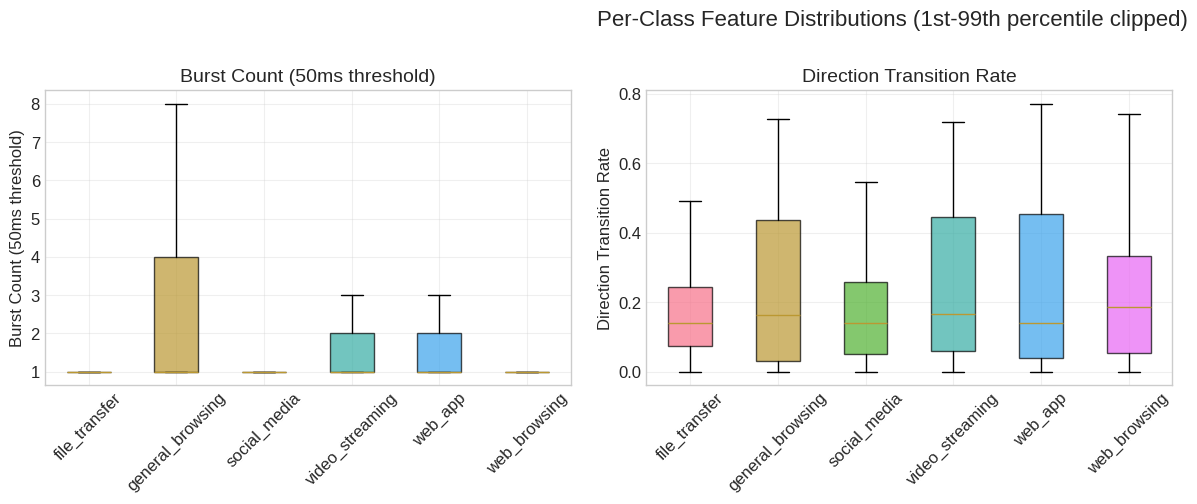

  💾 /content/drive/MyDrive/quic-project/quic_results/eda_feature_distributions.png


In [ ]:
EDA_KEY_FEATURES = [
    ("pkt_size_all_mean",           "Mean Packet Size (bytes)"),
    ("download_byte_fraction",      "Download Byte Fraction"),
    ("flow_duration",               "Flow Duration (s)"),
    ("flow_avg_Bps",                "Average Throughput (B/s)"),
    ("iat_all_median",              "Median IAT (s)"),
    ("burst_50ms_count",            "Burst Count (50ms threshold)"),
    ("burst_50ms_periodicity_score","Burst Periodicity Score"),
    ("dir_transition_rate",         "Direction Transition Rate"),
    ("rate_all_cv",                 "Rate Coefficient of Variation"),
]
EDA_KEY_FEATURES = [(c, n) for c, n in EDA_KEY_FEATURES
                    if c in feature_matrix_ml.columns]
n_plots = len(EDA_KEY_FEATURES)
n_cols = 3
n_rows = (n_plots + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = axes.flatten() if n_rows > 1 else (axes if isinstance(axes, np.ndarray) else [axes])
for idx, (feat, label) in enumerate(EDA_KEY_FEATURES):
    ax = axes[idx]
    plot_data, plot_labels, plot_colors = [], [], []
    for cls in class_names:
        vals = feature_matrix_ml[feature_matrix_ml["traffic_label"] == cls][feat].dropna()
        if len(vals) < 5:
            continue
        clip_hi = vals.quantile(0.99)
        clip_lo = vals.quantile(0.01)
        vals = vals.clip(clip_lo, clip_hi)
        plot_data.append(vals.values)
        plot_labels.append(cls)
        plot_colors.append(CLASS_COLORS[cls])
    if not plot_data:
        ax.set_visible(False)
        continue
    bp = ax.boxplot(plot_data, labels=plot_labels, patch_artist=True, showfliers=False)
    for patch, c in zip(bp["boxes"], plot_colors):
        patch.set_facecolor(c); patch.set_alpha(0.7)
    ax.set_title(label)
    ax.set_ylabel(label)
    ax.tick_params(axis="x", rotation=45)
for j in range(len(EDA_KEY_FEATURES), len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Per-Class Feature Distributions (1st-99th percentile clipped)",
             fontsize=16, y=1.005)
plt.tight_layout()
out = save_fig(fig, "eda_feature_distributions.png")
plt.show()
print(f"   {out}")


  Subsampled to 1,104 connections (~184 per class)
  Running UMAP (n_components=2, deterministic mode, n_jobs=1)...
  Done in 12.1s


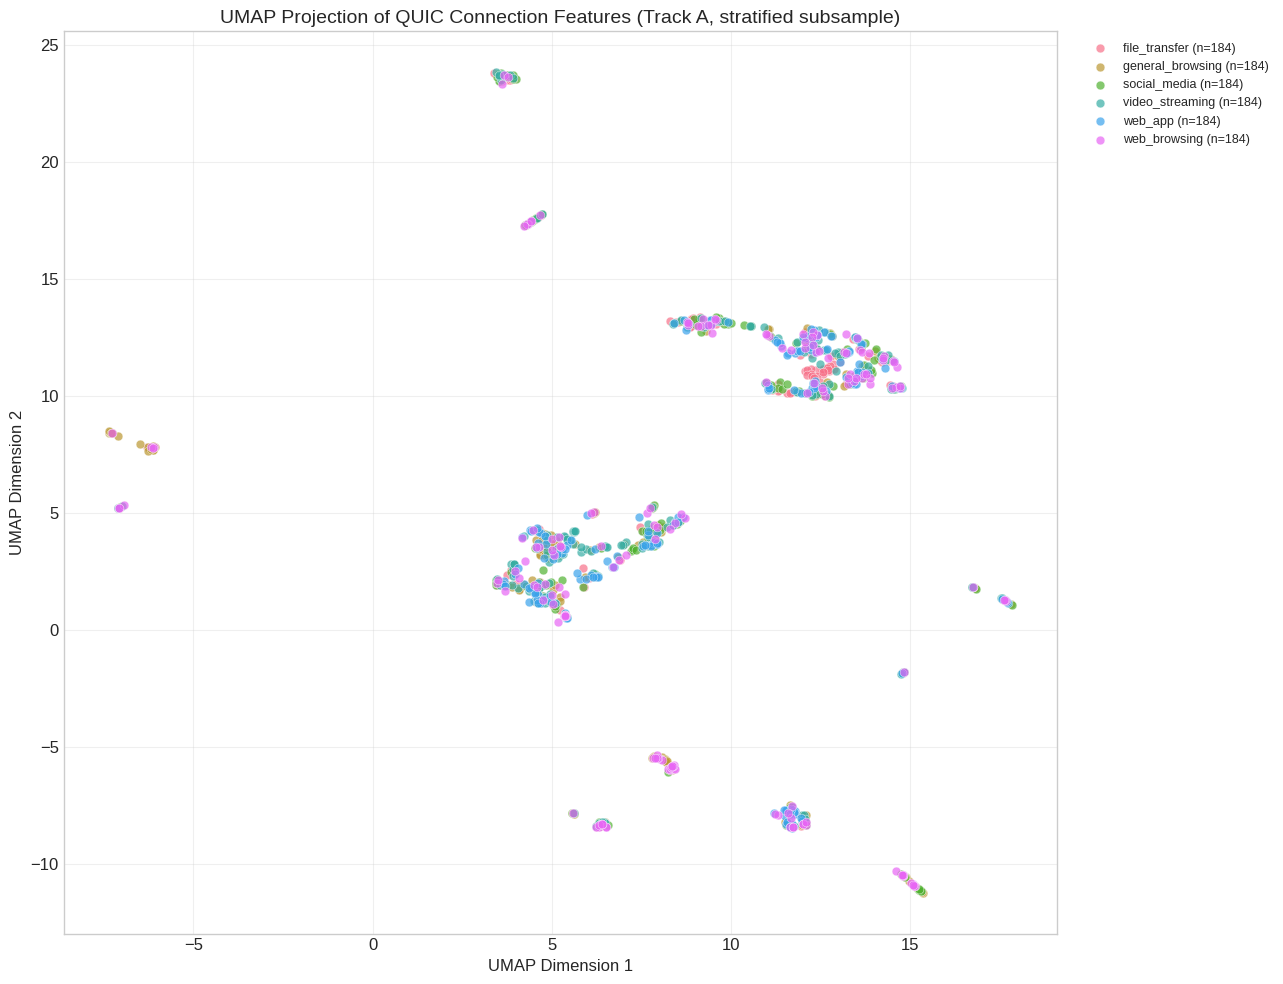

  💾 /content/drive/MyDrive/quic-project/quic_results/eda_umap_track_a.png


In [ ]:
try:
    import umap
except ImportError:
    print("[INFO] umap-learn not installed, skipping UMAP.")
    umap = None
if umap is not None:
    from sklearn.preprocessing import StandardScaler
    rng = np.random.RandomState(SEED)
    target_per_class = min(500, feature_matrix_ml["traffic_label"].value_counts().min())
    sampled_indices = []
    for cls in class_names:
        cls_pool = np.where(feature_matrix_ml["traffic_label"].values == cls)[0]
        chosen = rng.choice(cls_pool, size=min(target_per_class, len(cls_pool)), replace=False)
        sampled_indices.extend(chosen)
    sampled_indices = np.array(sampled_indices)
    print(f"  Subsampled to {len(sampled_indices):,} connections "
          f"(~{target_per_class} per class)")
    X_umap_raw = feature_matrix_ml.iloc[sampled_indices][TRACK_A_FEATURES]
    X_umap_raw = X_umap_raw.replace([np.inf, -np.inf], np.nan).fillna(X_umap_raw.median())
    labels_umap = feature_matrix_ml.iloc[sampled_indices]["traffic_label"].values
    scaler = StandardScaler()
    X_umap_std = scaler.fit_transform(X_umap_raw)
    print(f"  Running UMAP (n_components=2, deterministic mode, n_jobs=1)...")
    t0 = time.time()
    reducer = umap.UMAP(
        n_components=2, n_neighbors=15, min_dist=0.1,
        metric="euclidean", random_state=SEED, n_jobs=1,
    )
    emb = reducer.fit_transform(X_umap_std)
    print(f"  Done in {time.time() - t0:.1f}s")
    fig, ax = plt.subplots(figsize=(13, 10))
    for cls in class_names:
        mask = labels_umap == cls
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   c=[CLASS_COLORS[cls]], label=f"{cls} (n={mask.sum()})",
                   alpha=0.7, s=40, edgecolors="white", linewidth=0.4)
    ax.set_xlabel("UMAP Dimension 1")
    ax.set_ylabel("UMAP Dimension 2")
    ax.set_title("UMAP Projection of QUIC Connection Features (Track A, stratified subsample)")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
    plt.tight_layout()
    out = save_fig(fig, "eda_umap_track_a.png")
    plt.show()
    print(f"   {out}")
    del X_umap_raw, X_umap_std, emb
    gc.collect()


XA_train_imp shape: (1307, 257)
y_train length: 1307
XA_train shape: (1307, 257)
X_train not defined
  Computing mutual information for 257 features on 1,307 training samples...
  Done in 5.7s

  Top-20 features by mutual information with traffic class:
pkt_size_down_p5         0.299732
pkt_size_down_min        0.283055
pkt_size_down_p10        0.275478
first_n_mean_size        0.263954
payload_efficiency       0.260641
first_n_total_bytes      0.257118
first_2_signed_size      0.252540
first_4_signed_size      0.248913
pkt_size_all_p5          0.244911
pkt_size_up_min          0.240783
payload_p5               0.240529
first_6_signed_size      0.236560
first_1_signed_size      0.228264
first_0_signed_size      0.228232
burst_100ms_bytes_max    0.225596
pkt_size_up_p10          0.225054
pkt_size_all_min         0.224014
pkt_size_down_p95        0.221714
payload_p90              0.219921
payload_range            0.216576


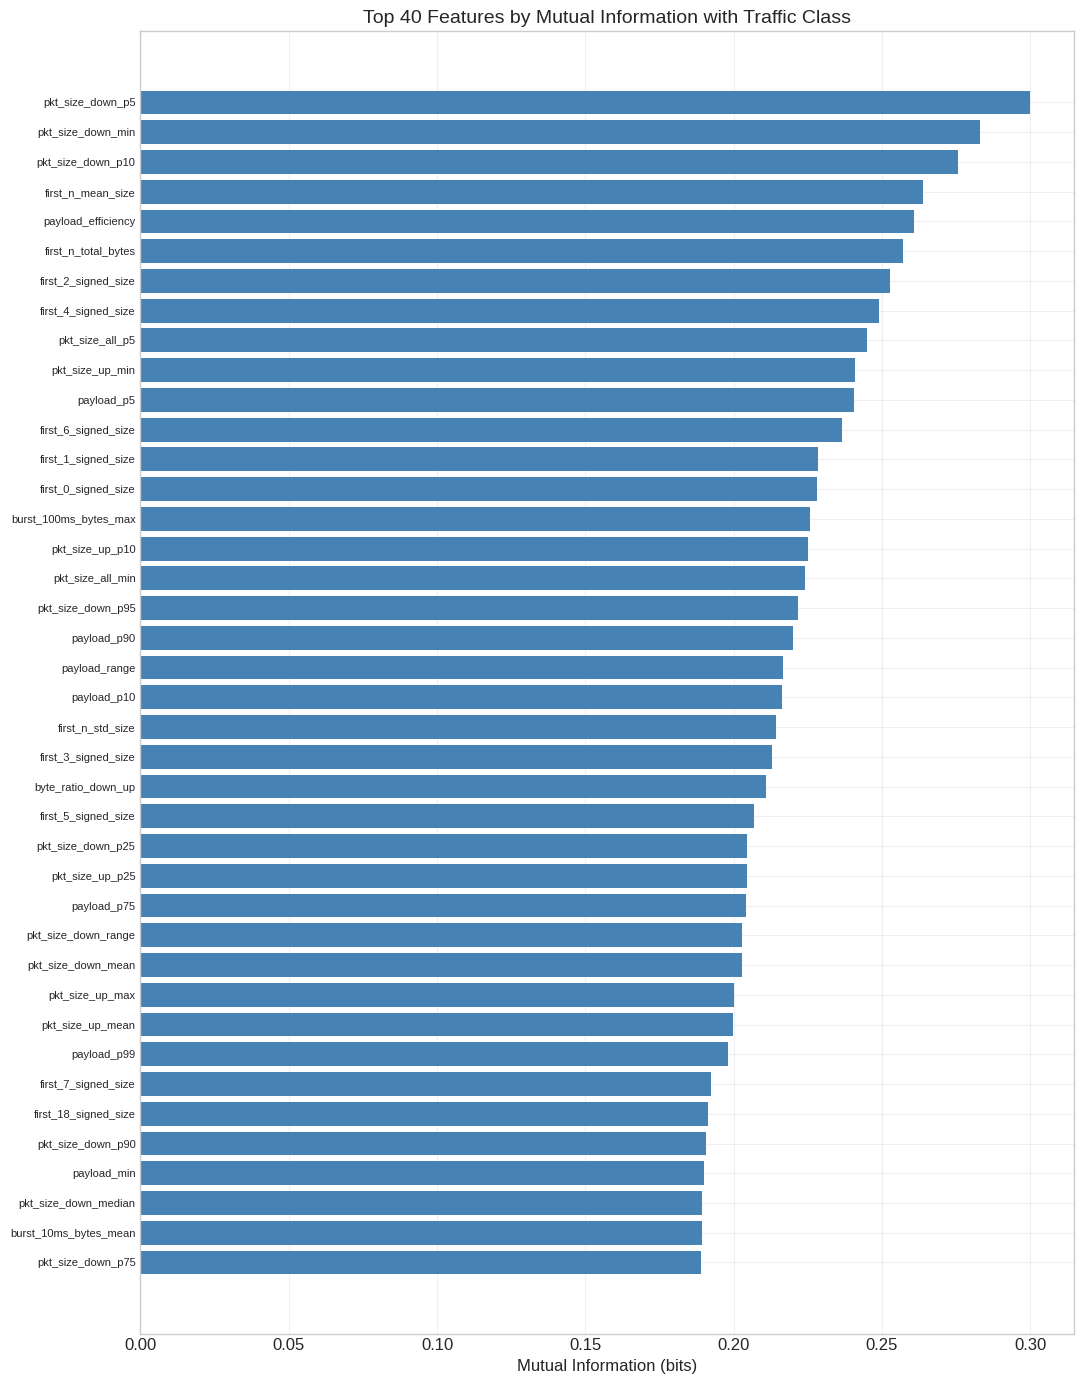


  💾 /content/drive/MyDrive/quic-project/quic_results/eda_mutual_information.png


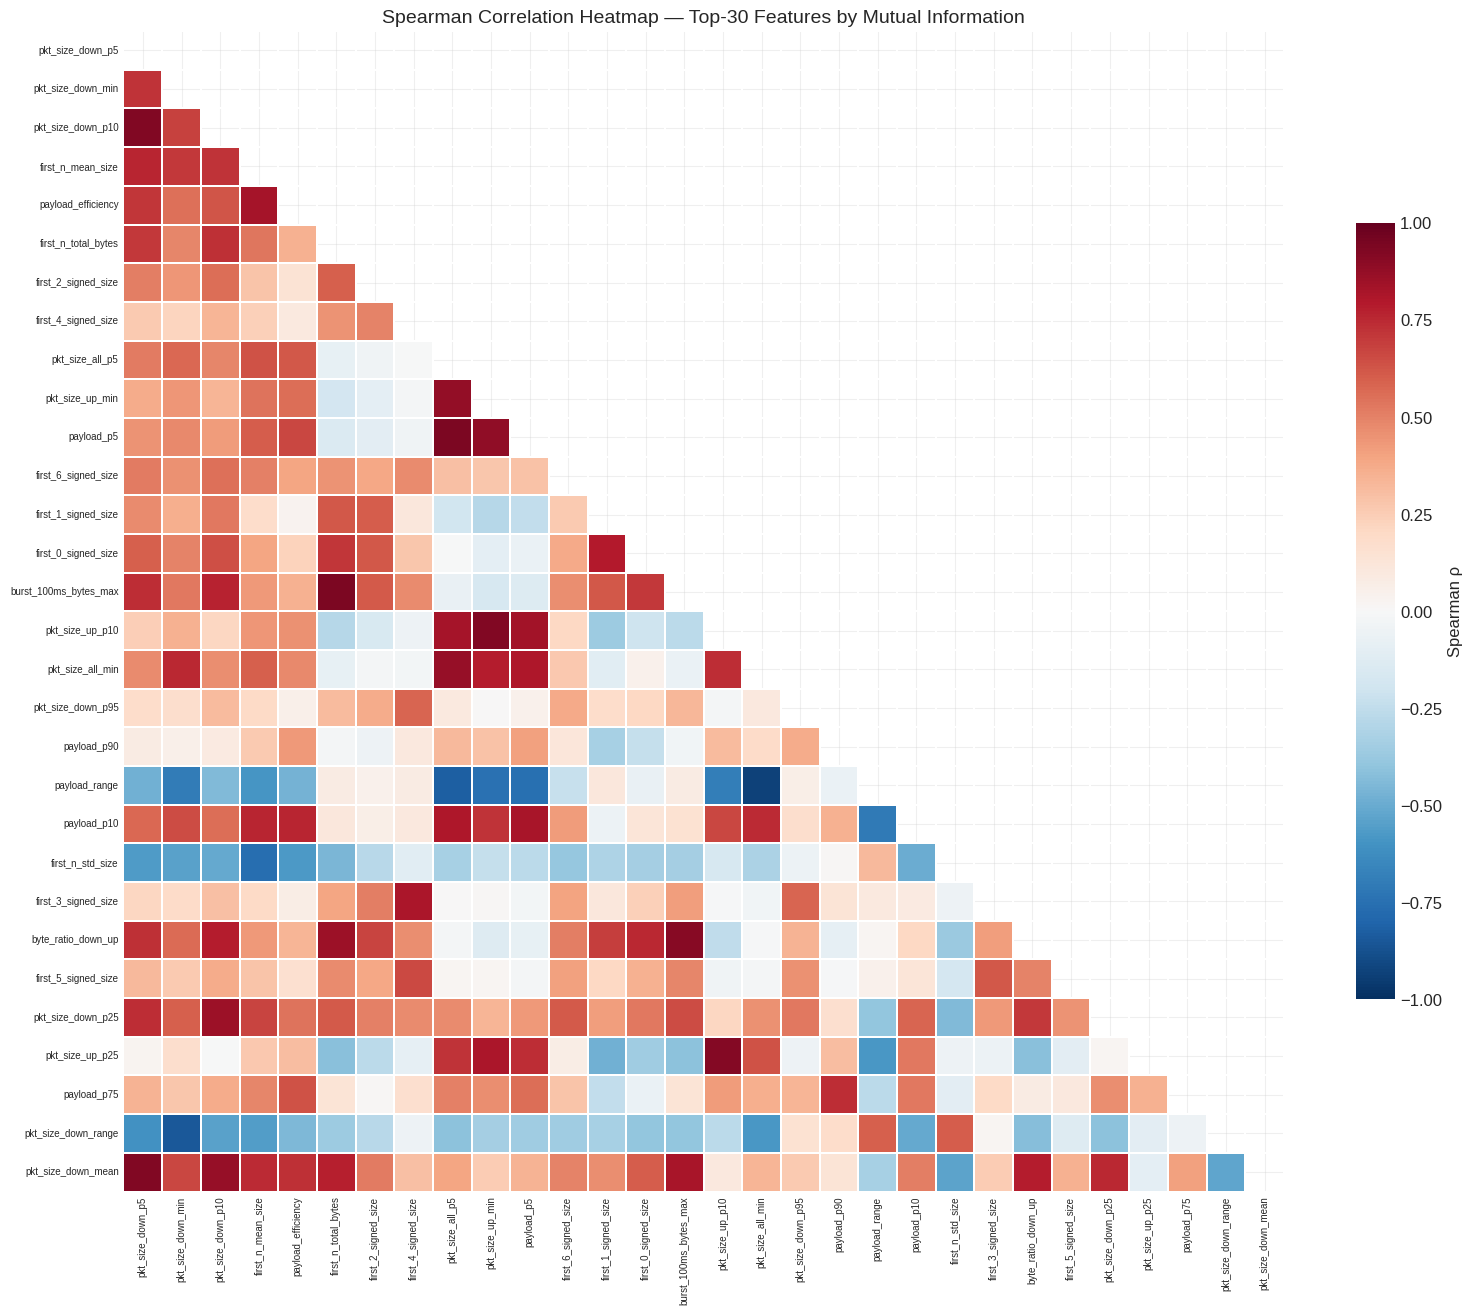

  💾 /content/drive/MyDrive/quic-project/quic_results/eda_correlation_heatmap.png


In [ ]:
from sklearn.feature_selection import mutual_info_classif
print("XA_train_imp shape:", XA_train.shape)
print("y_train length:", len(y_train))
try:
    print("XA_train shape:", XA_train.shape)
except NameError:
    print("XA_train not defined")
try:
    print("X_train shape:", X_train.shape)
except NameError:
    print("X_train not defined")
print(f"  Computing mutual information for {len(TRACK_A_FEATURES)} features "
      f"on {len(y_train):,} training samples...")
t0 = time.time()
mi_scores = mutual_info_classif(
    XA_train, y_train, random_state=SEED, n_jobs=-1,
)
mi_series = pd.Series(mi_scores, index=TRACK_A_FEATURES).sort_values(ascending=False)
print(f"  Done in {time.time() - t0:.1f}s")
print(f"\n  Top-20 features by mutual information with traffic class:")
print(mi_series.head(20).to_string())
fig, ax = plt.subplots(figsize=(11, 14))
top_n = min(40, len(mi_series))
top = mi_series.head(top_n).sort_values()
ax.barh(top.index, top.values, color="steelblue")
ax.set_xlabel("Mutual Information (bits)")
ax.set_title(f"Top {top_n} Features by Mutual Information with Traffic Class")
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
out = save_fig(fig, "eda_mutual_information.png")
plt.show()
print(f"\n   {out}")
top_30 = mi_series.head(30).index.tolist()
corr_30 = feature_matrix_ml[top_30].corr(method="spearman", min_periods=50)
fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_30, dtype=bool))
sns.heatmap(corr_30, mask=mask, cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.3, ax=ax,
            cbar_kws={"shrink": 0.6, "label": "Spearman ρ"},
            annot=False)
ax.set_title("Spearman Correlation Heatmap — Top-30 Features by Mutual Information",
             fontsize=14)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
out = save_fig(fig, "eda_correlation_heatmap.png")
plt.show()
print(f"   {out}")
mi_series.to_csv(Path(RESULTS_DIR) / "feature_mutual_information.csv",
                 header=["mutual_information"])


  Loaded 1,007,260 packets for time-series visualization


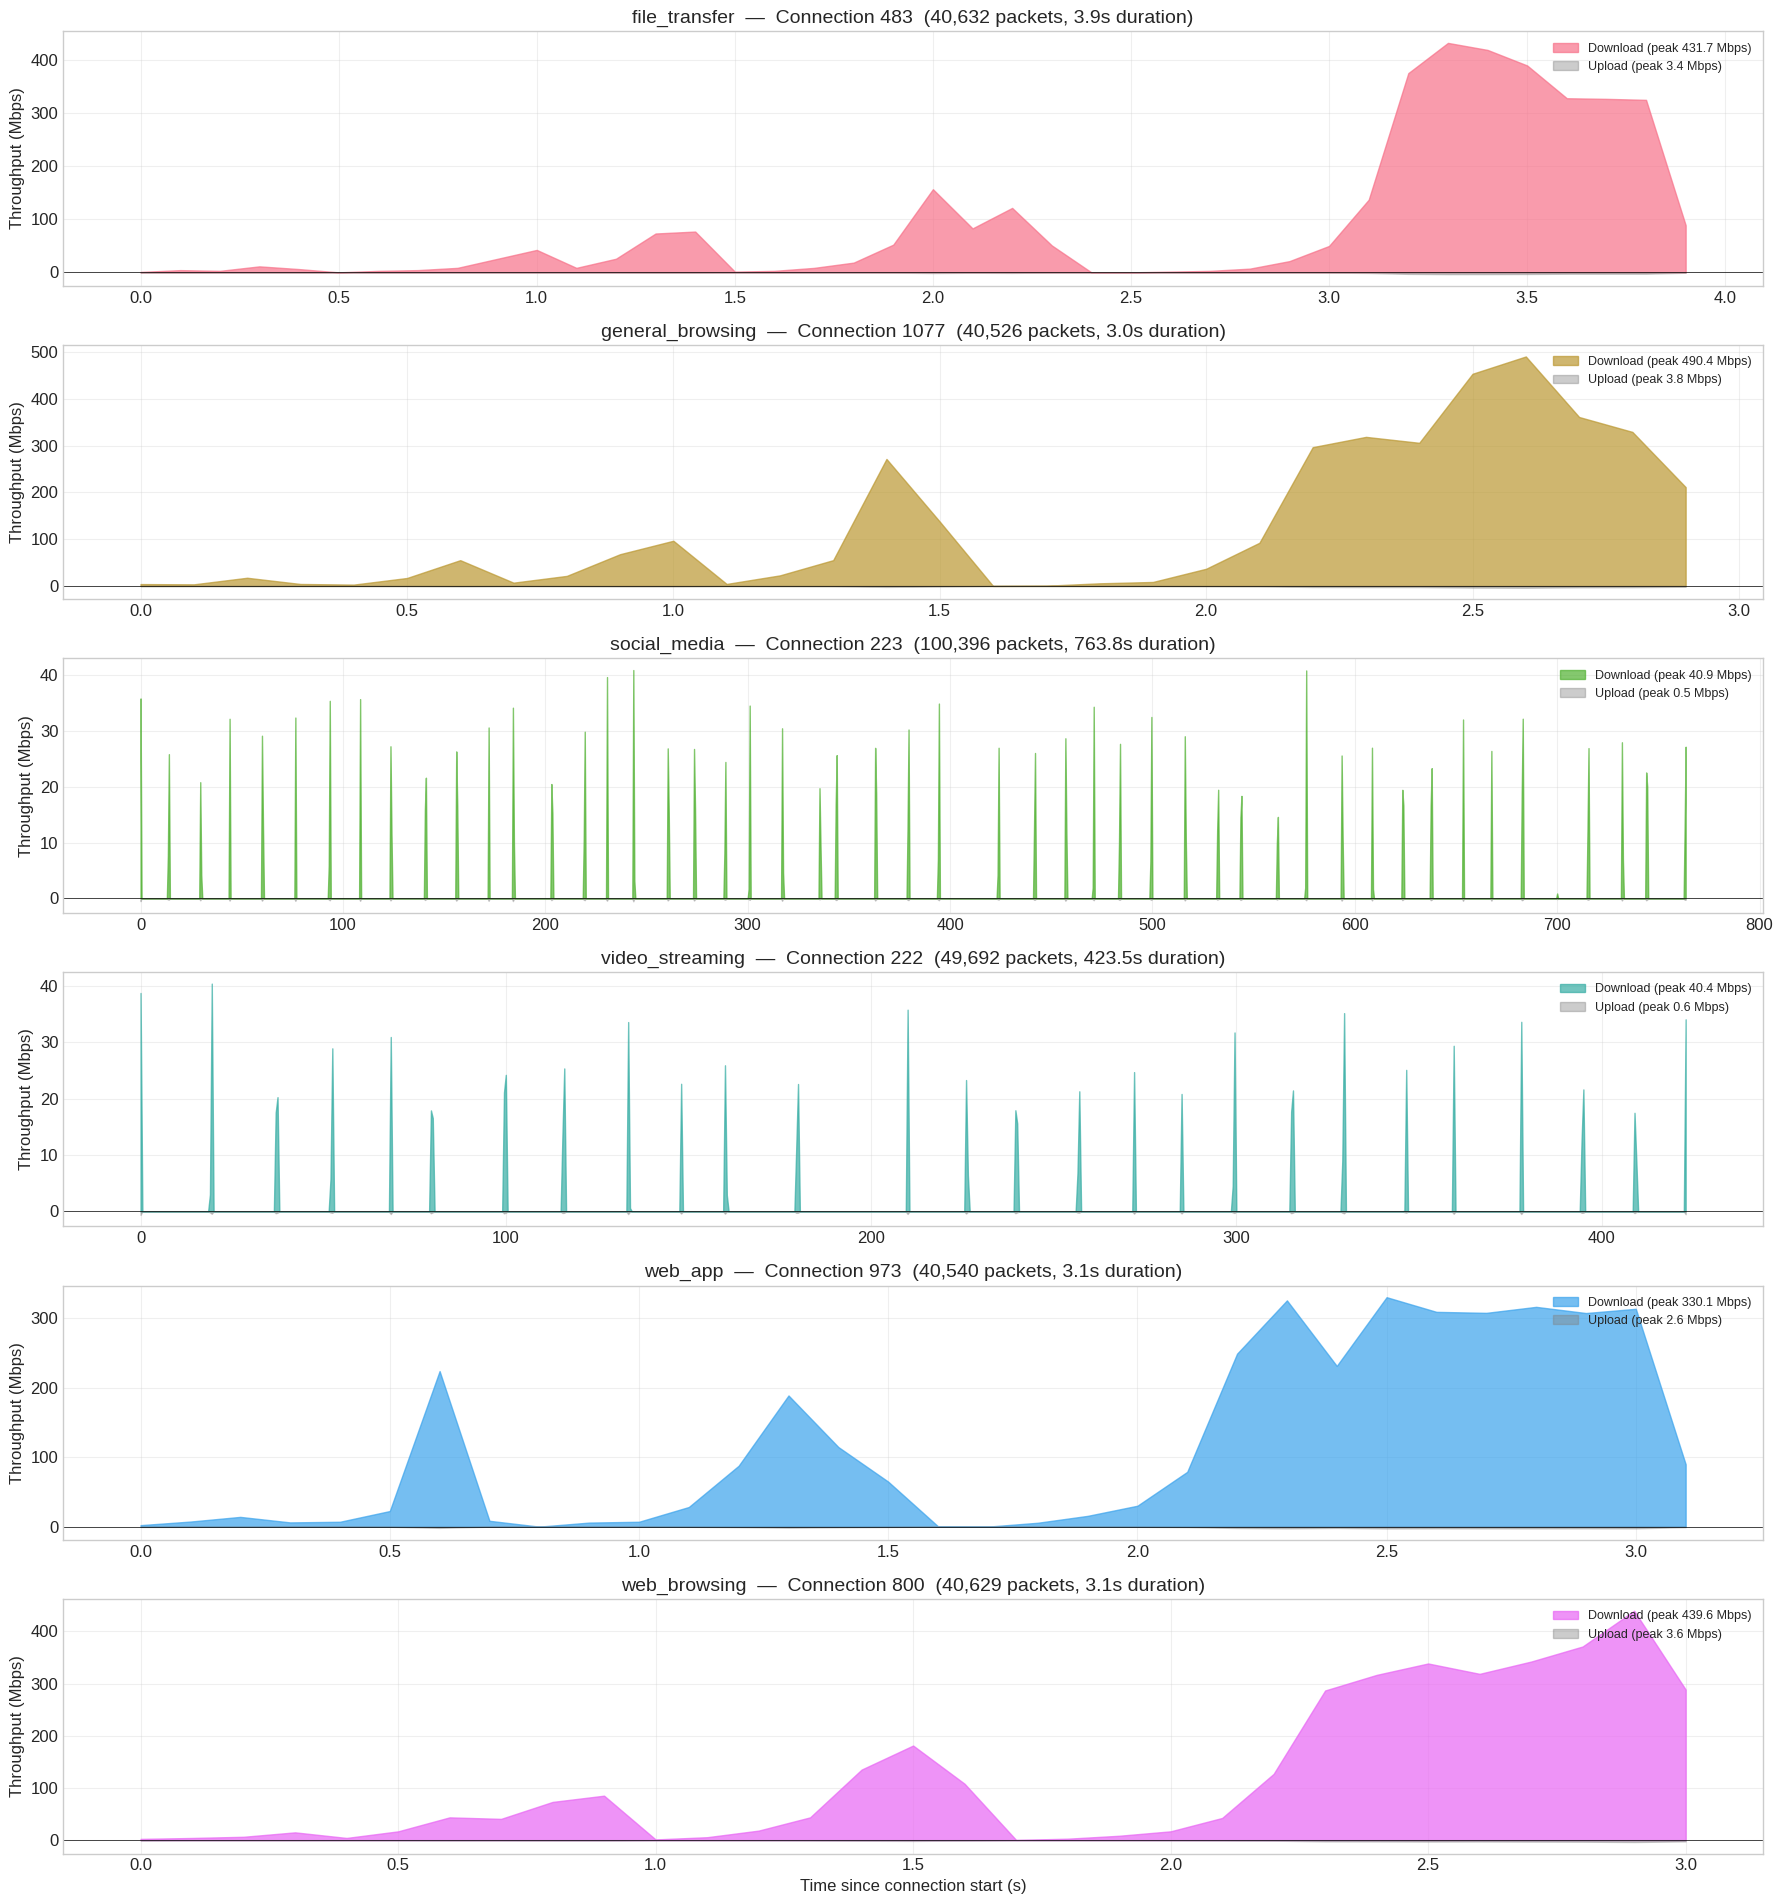

  💾 /content/drive/MyDrive/quic-project/quic_results/eda_throughput_timeseries.png


22909

In [ ]:
packets_path = Path(PROCESSED_DIR) / "packets_clean.parquet"
df_packets = pd.read_parquet(packets_path,
                             columns=["connection_id", "frame_time_epoch",
                                      "frame_len", "direction"])
print(f"  Loaded {len(df_packets):,} packets for time-series visualization")
n_classes_plot = n_classes
fig, axes = plt.subplots(n_classes_plot, 1, figsize=(18, 3.2 * n_classes_plot), sharex=False)
if n_classes_plot == 1:
    axes = [axes]
for idx, cls in enumerate(class_names):
    ax = axes[idx]
    candidates = feature_matrix_ml[feature_matrix_ml["traffic_label"] == cls]
    if len(candidates) == 0:
        ax.set_visible(False)
        continue
    pkt_counts = (df_packets[df_packets["connection_id"]
                             .isin(candidates["connection_id"].values)]
                  .groupby("connection_id").size()
                  .sort_values(ascending=False))
    if len(pkt_counts) == 0:
        ax.set_visible(False)
        continue
    best_conn = int(pkt_counts.index[0])
    pkts = (df_packets[df_packets["connection_id"] == best_conn]
            .sort_values("frame_time_epoch"))
    ts = pkts["frame_time_epoch"].to_numpy()
    sz = pkts["frame_len"].to_numpy()
    di = pkts["direction"].to_numpy()
    duration = ts[-1] - ts[0]
    if duration <= 0:
        ax.set_visible(False); continue
    bin_width = 0.1 if duration < 5 else 0.5
    n_bins = max(int(np.ceil(duration / bin_width)), 1)
    bin_idx = np.minimum(((ts - ts[0]) / bin_width).astype(int), n_bins - 1)
    b_up   = np.zeros(n_bins); b_down = np.zeros(n_bins)
    np.add.at(b_down, bin_idx[di == "server_to_client"], sz[di == "server_to_client"])
    np.add.at(b_up,   bin_idx[di == "client_to_server"], sz[di == "client_to_server"])
    mbps_down = b_down * 8 / bin_width / 1e6
    mbps_up   = b_up   * 8 / bin_width / 1e6
    t_axis = np.arange(n_bins) * bin_width
    ax.fill_between(t_axis,  mbps_down, alpha=0.7, color=CLASS_COLORS[cls],
                    label=f"Download (peak {mbps_down.max():.1f} Mbps)")
    ax.fill_between(t_axis, -mbps_up,   alpha=0.4, color="gray",
                    label=f"Upload (peak {mbps_up.max():.1f} Mbps)")
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_ylabel("Throughput (Mbps)")
    ax.set_title(f"{cls}  —  Connection {best_conn}  "
                 f"({len(pkts):,} packets, {duration:.1f}s duration)")
    ax.legend(loc="upper right", fontsize=9)
axes[-1].set_xlabel("Time since connection start (s)")
plt.tight_layout()
out = save_fig(fig, "eda_throughput_timeseries.png")
plt.show()
print(f"   {out}")
del df_packets
gc.collect()


In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, f1_score, classification_report
print(f"XGBoost version: {xgb.__version__}")
def build_xgb_model(n_classes_local: int, n_train: int, n_features: int) -> xgb.XGBClassifier:
    if n_train < 1_000:
        n_estimators = 400; early = 40
    elif n_train < 10_000:
        n_estimators = 800; early = 60
    else:
        n_estimators = 1200; early = 80
    max_depth = 6 if n_features < 200 else 8
    return xgb.XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=3,
        reg_alpha=0.05,
        reg_lambda=1.0,
        gamma=0.1,
        objective="multi:softprob" if n_classes_local > 2 else "binary:logistic",
        eval_metric="mlogloss" if n_classes_local > 2 else "logloss",
        tree_method="hist",
        max_bin=256,
        random_state=SEED,
        n_jobs=-1,
        early_stopping_rounds=early,
    )
def train_xgb(name: str, X_tr, y_tr, X_va, y_va, X_te, y_te, sample_w):
    print(f"\n{'─' * 72}")
    print(f"  XGBoost — {name}")
    print(f"{'─' * 72}")
    print(f"  Train: {X_tr.shape}, Val: {X_va.shape}, Test: {X_te.shape}")
    model = build_xgb_model(n_classes, len(X_tr), X_tr.shape[1])
    t0 = time.time()
    model.fit(
        X_tr, y_tr,
        sample_weight=sample_w,
        eval_set=[(X_va, y_va)],
        verbose=False,
    )
    train_time = time.time() - t0
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)
    acc  = accuracy_score(y_te, y_pred)
    f1_m = f1_score(y_te, y_pred, average="macro")
    f1_w = f1_score(y_te, y_pred, average="weighted")
    print(f"   Trained in {train_time:.1f}s, best_iteration={model.best_iteration}")
    print(f"     Accuracy        : {acc:.4f}")
    print(f"     F1 (macro)      : {f1_m:.4f}")
    print(f"     F1 (weighted)   : {f1_w:.4f}")
    return {
        "model": model, "y_pred": y_pred, "y_prob": y_prob,
        "accuracy": acc, "f1_macro": f1_m, "f1_weighted": f1_w,
        "train_time_s": train_time, "best_iter": model.best_iteration,
    }
results_xgb_A = train_xgb("Track A (Full Features)",
                          XA_train_with_nan, y_train,
                          XA_val_with_nan,   y_val,
                          XA_test_with_nan,  y_test,
                          sample_weights_train)
results_xgb_B = train_xgb("Track B (Behavioral Only)",
                          XB_train_with_nan, y_train,
                          XB_val_with_nan,   y_val,
                          XB_test_with_nan,  y_test,
                          sample_weights_train)
print(f"\n{'=' * 72}")
print(f"XGBoost test F1 (macro):  Track A = {results_xgb_A['f1_macro']:.4f}   "
      f"Track B = {results_xgb_B['f1_macro']:.4f}")
delta = results_xgb_A["f1_macro"] - results_xgb_B["f1_macro"]
print(f"  Δ (A - B) = {delta:+.4f}   "
      f"({'large' if abs(delta) > 0.10 else 'modest'} dependence on server fingerprints)")


XGBoost version: 2.0.3

────────────────────────────────────────────────────────────────────────
  XGBoost — Track A (Full Features)
────────────────────────────────────────────────────────────────────────
  Train: (1307, 257), Val: (429, 257), Test: (460, 257)
  ✅ Trained in 19.1s, best_iteration=8
     Accuracy        : 0.3522
     F1 (macro)      : 0.3355
     F1 (weighted)   : 0.3462

────────────────────────────────────────────────────────────────────────
  XGBoost — Track B (Behavioral Only)
────────────────────────────────────────────────────────────────────────
  Train: (1307, 256), Val: (429, 256), Test: (460, 256)
  ✅ Trained in 19.2s, best_iteration=7
     Accuracy        : 0.3891
     F1 (macro)      : 0.3657
     F1 (weighted)   : 0.3802

XGBoost test F1 (macro):  Track A = 0.3355   Track B = 0.3657
  Δ (A - B) = -0.0302   (modest dependence on server fingerprints)


In [ ]:
import lightgbm as lgb
print(f"LightGBM version: {lgb.__version__}")
def build_lgb_model(n_train: int) -> lgb.LGBMClassifier:
    n_est = 400 if n_train < 1_000 else (800 if n_train < 10_000 else 1200)
    return lgb.LGBMClassifier(
        n_estimators=n_est,
        num_leaves=63,
        learning_rate=0.05,
        feature_fraction=0.85,
        bagging_fraction=0.85,
        bagging_freq=5,
        min_child_samples=20,
        reg_alpha=0.05,
        reg_lambda=0.1,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1,
        verbosity=-1,
        force_col_wise=True,
    )
def train_lgb(name: str, X_tr, y_tr, X_va, y_va, X_te, y_te):
    print(f"\n{'─' * 72}")
    print(f"  LightGBM — {name}")
    print(f"{'─' * 72}")
    print(f"  Train: {X_tr.shape}, Val: {X_va.shape}, Test: {X_te.shape}")
    model = build_lgb_model(len(X_tr))
    t0 = time.time()
    early_stop = lgb.early_stopping(stopping_rounds=60, verbose=False)
    log_eval = lgb.log_evaluation(period=0)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        eval_metric="multi_logloss" if n_classes > 2 else "binary_logloss",
        callbacks=[early_stop, log_eval],
    )
    train_time = time.time() - t0
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)
    acc  = accuracy_score(y_te, y_pred)
    f1_m = f1_score(y_te, y_pred, average="macro")
    f1_w = f1_score(y_te, y_pred, average="weighted")
    print(f"   Trained in {train_time:.1f}s, best_iteration={model.best_iteration_}")
    print(f"     Accuracy        : {acc:.4f}")
    print(f"     F1 (macro)      : {f1_m:.4f}")
    print(f"     F1 (weighted)   : {f1_w:.4f}")
    return {
        "model": model, "y_pred": y_pred, "y_prob": y_prob,
        "accuracy": acc, "f1_macro": f1_m, "f1_weighted": f1_w,
        "train_time_s": train_time,
    }
results_lgb_A = train_lgb("Track A (Full Features)",
                          XA_train_with_nan, y_train,
                          XA_val_with_nan,   y_val,
                          XA_test_with_nan,  y_test)
results_lgb_B = train_lgb("Track B (Behavioral Only)",
                          XB_train_with_nan, y_train,
                          XB_val_with_nan,   y_val,
                          XB_test_with_nan,  y_test)
print(f"\n{'=' * 72}")
print(f"LightGBM test F1 (macro):  Track A = {results_lgb_A['f1_macro']:.4f}   "
      f"Track B = {results_lgb_B['f1_macro']:.4f}")


LightGBM version: 4.3.0

────────────────────────────────────────────────────────────────────────
  LightGBM — Track A (Full Features)
────────────────────────────────────────────────────────────────────────
  Train: (1307, 257), Val: (429, 257), Test: (460, 257)
  ✅ Trained in 6.4s, best_iteration=3
     Accuracy        : 0.3370
     F1 (macro)      : 0.3325
     F1 (weighted)   : 0.3349

────────────────────────────────────────────────────────────────────────
  LightGBM — Track B (Behavioral Only)
────────────────────────────────────────────────────────────────────────
  Train: (1307, 256), Val: (429, 256), Test: (460, 256)
  ✅ Trained in 11.2s, best_iteration=9
     Accuracy        : 0.3543
     F1 (macro)      : 0.3497
     F1 (weighted)   : 0.3545

LightGBM test F1 (macro):  Track A = 0.3325   Track B = 0.3497


In [ ]:
from sklearn.ensemble import RandomForestClassifier
def build_rf_model(n_train: int) -> RandomForestClassifier:
    return RandomForestClassifier(
        n_estimators=600 if n_train < 5_000 else 800,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features="sqrt",
        class_weight=None,
        random_state=SEED,
        n_jobs=-1,
    )
def train_rf(name, X_tr, y_tr, X_te, y_te, sample_w):
    print(f"\n{'─' * 72}")
    print(f"  Random Forest — {name}")
    print(f"{'─' * 72}")
    print(f"  Train: {X_tr.shape}, Test: {X_te.shape}")
    model = build_rf_model(len(X_tr))
    t0 = time.time()
    model.fit(X_tr, y_tr, sample_weight=sample_w)
    train_time = time.time() - t0
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)
    return {
        "model": model, "y_pred": y_pred, "y_prob": y_prob,
        "accuracy": accuracy_score(y_te, y_pred),
        "f1_macro": f1_score(y_te, y_pred, average="macro"),
        "f1_weighted": f1_score(y_te, y_pred, average="weighted"),
    }
results_rf_A = train_rf("Track A (Full Features)",
                        XA_train, y_train, XA_test, y_test,
                        sample_weights_train)
results_rf_B = train_rf("Track B (Behavioral Only)",
                        XB_train, y_train, XB_test, y_test,
                        sample_weights_train)
print(f"\n  RF test F1 (macro):  Track A = {results_rf_A['f1_macro']:.4f}   "
      f"Track B = {results_rf_B['f1_macro']:.4f}")



────────────────────────────────────────────────────────────────────────
  Random Forest — Track A (Full Features)
────────────────────────────────────────────────────────────────────────
  Train: (1307, 257), Test: (460, 257)

────────────────────────────────────────────────────────────────────────
  Random Forest — Track B (Behavioral Only)
────────────────────────────────────────────────────────────────────────
  Train: (1307, 256), Test: (460, 256)

  RF test F1 (macro):  Track A = 0.3466   Track B = 0.3436


In [ ]:
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    TORCH_AVAILABLE = True
except ImportError:
    print("  [SKIP] PyTorch not installed. Run `%pip install -q torch` to enable.")
    TORCH_AVAILABLE = False
if TORCH_AVAILABLE:
    SEQ_LEN = 30
    def build_sequence_tensor(idx_array):
        sigsize = np.zeros((len(idx_array), SEQ_LEN), dtype="float32")
        logiat  = np.zeros((len(idx_array), SEQ_LEN), dtype="float32")
        cols_ss = [f"first_{i}_signed_size" for i in range(SEQ_LEN)]
        cols_it = [f"first_{i}_iat"         for i in range(SEQ_LEN)]
        cols_ss = [c for c in cols_ss if c in feature_matrix_ml.columns]
        cols_it = [c for c in cols_it if c in feature_matrix_ml.columns]
        sub = feature_matrix_ml.iloc[idx_array]
        for i, c in enumerate(cols_ss):
            sigsize[:, i] = sub[c].fillna(0).values / 1500.0
        for i, c in enumerate(cols_it):
            logiat[:, i] = np.log1p(np.maximum(sub[c].fillna(0).values, 0)) / 5.0
        return np.stack([sigsize, logiat], axis=1).astype("float32")
    Xs_train = torch.from_numpy(build_sequence_tensor(train_idx))
    Xs_val   = torch.from_numpy(build_sequence_tensor(val_idx))
    Xs_test  = torch.from_numpy(build_sequence_tensor(test_idx))
    yt_train = torch.from_numpy(y_train).long()
    yt_val   = torch.from_numpy(y_val).long()
    yt_test  = torch.from_numpy(y_test).long()
    print(f"  Seq tensors: train={tuple(Xs_train.shape)}, val={tuple(Xs_val.shape)}, test={tuple(Xs_test.shape)}")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    torch.manual_seed(SEED)
    class QuicCNN(nn.Module):
        def __init__(self, n_classes, seq_len=SEQ_LEN):
            super().__init__()
            self.feat = nn.Sequential(
                nn.Conv1d(2, 64, 5, padding=2), nn.BatchNorm1d(64), nn.ReLU(),
                nn.Conv1d(64, 64, 3, padding=1), nn.BatchNorm1d(64), nn.ReLU(),
                nn.MaxPool1d(2),
                nn.Conv1d(64, 128, 3, padding=1), nn.BatchNorm1d(128), nn.ReLU(),
                nn.AdaptiveAvgPool1d(1), nn.Flatten(),
            )
            self.head = nn.Sequential(
                nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3),
                nn.Linear(64, n_classes),
            )
        def forward(self, x): return self.head(self.feat(x))
    model_cnn = QuicCNN(n_classes).to(device)
    cls_w_t   = torch.from_numpy(class_w_train.astype("float32")).to(device)
    crit      = nn.CrossEntropyLoss(weight=cls_w_t)
    opt       = torch.optim.AdamW(model_cnn.parameters(), lr=1e-3, weight_decay=1e-4)
    train_dl  = DataLoader(TensorDataset(Xs_train, yt_train), batch_size=64, shuffle=True)
    best_f1, best_state, patience, bad = 0.0, None, 30, 0
    for epoch in range(200):
        model_cnn.train()
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model_cnn(xb), yb); loss.backward(); opt.step()
        model_cnn.eval()
        with torch.no_grad():
            val_logits = model_cnn(Xs_val.to(device)).cpu().numpy()
        val_pred = val_logits.argmax(axis=1)
        val_f1   = f1_score(y_val, val_pred, average="macro")
        if val_f1 > best_f1:
            best_f1, best_state, bad = val_f1, {k:v.cpu().clone() for k,v in model_cnn.state_dict().items()}, 0
        else:
            bad += 1
            if bad >= patience:
                print(f"  Early stop @ epoch {epoch}, best val F1 = {best_f1:.4f}")
                break
    model_cnn.load_state_dict(best_state)
    model_cnn.eval()
    with torch.no_grad():
        test_logits = model_cnn(Xs_test.to(device)).cpu().numpy()
    test_prob = torch.softmax(torch.from_numpy(test_logits), dim=1).numpy()
    test_pred = test_logits.argmax(axis=1)
    f1_cnn_m  = f1_score(y_test, test_pred, average="macro")
    f1_cnn_w  = f1_score(y_test, test_pred, average="weighted")
    acc_cnn   = accuracy_score(y_test, test_pred)
    print(f"\n  CNN test results:")
    print(f"    Accuracy        : {acc_cnn:.4f}")
    print(f"    F1 (macro)      : {f1_cnn_m:.4f}")
    print(f"    F1 (weighted)   : {f1_cnn_w:.4f}")
    results_cnn = {"y_pred": test_pred, "y_prob": test_prob,
                   "accuracy": acc_cnn, "f1_macro": f1_cnn_m, "f1_weighted": f1_cnn_w}


  Seq tensors: train=(1307, 2, 30), val=(429, 2, 30), test=(460, 2, 30)
  Early stop @ epoch 70, best val F1 = 0.2173

  CNN test results:
    Accuracy        : 0.2326
    F1 (macro)      : 0.2064
    F1 (weighted)   : 0.2411


In [ ]:
from sklearn.utils.class_weight import compute_sample_weight
min_class_dev = int(np.bincount(y_dev).min())
N_FOLDS = max(2, min(5, min_class_dev))
print(f"  Min class size in dev = {min_class_dev}  →  using {N_FOLDS}-fold CV")
cv = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
def run_group_cv(model_factory, X_dev_loc, y_dev_loc, groups_dev_loc,
                 needs_sample_weight: bool, use_eval_set: bool,
                 label: str):
    fold_scores = []
    for fold_no, (tr, va) in enumerate(cv.split(X_dev_loc, y_dev_loc, groups=groups_dev_loc), 1):
        X_tr_f = X_dev_loc.iloc[tr] if hasattr(X_dev_loc, "iloc") else X_dev_loc[tr]
        X_va_f = X_dev_loc.iloc[va] if hasattr(X_dev_loc, "iloc") else X_dev_loc[va]
        y_tr_f, y_va_f = y_dev_loc[tr], y_dev_loc[va]
        model = model_factory()
        kwargs = {}
        if needs_sample_weight:
            kwargs["sample_weight"] = compute_sample_weight("balanced", y_tr_f)
        if use_eval_set:
            kwargs["eval_set"] = [(X_va_f, y_va_f)]
            kwargs["verbose"]  = False
        model.fit(X_tr_f, y_tr_f, **kwargs)
        pred = model.predict(X_va_f)
        fold_scores.append(f1_score(y_va_f, pred, average="macro"))
        print(f"     Fold {fold_no}: F1_macro = {fold_scores[-1]:.4f}")
    arr = np.array(fold_scores)
    print(f"   → {label} CV F1_macro = {arr.mean():.4f} ± {arr.std():.4f}")
    return arr
print(f"\n{'─' * 72}")
print(f"  XGBoost CV  —  Track A")
print(f"{'─' * 72}")
cv_xgb_A = run_group_cv(
    lambda: build_xgb_model(n_classes, int(len(y_dev) * (N_FOLDS - 1) / N_FOLDS),
                            XA_dev_with_nan.shape[1]),
    XA_dev_with_nan, y_dev, groups_dev,
    needs_sample_weight=True, use_eval_set=True, label="XGBoost-A",
)
print(f"\n{'─' * 72}")
print(f"  XGBoost CV  —  Track B")
print(f"{'─' * 72}")
cv_xgb_B = run_group_cv(
    lambda: build_xgb_model(n_classes, int(len(y_dev) * (N_FOLDS - 1) / N_FOLDS),
                            XB_dev_with_nan.shape[1]),
    XB_dev_with_nan, y_dev, groups_dev,
    needs_sample_weight=True, use_eval_set=True, label="XGBoost-B",
)
print(f"\n{'─' * 72}")
print(f"  LightGBM CV  —  Track A")
print(f"{'─' * 72}")
cv_lgb_A = run_group_cv(
    lambda: build_lgb_model(int(len(y_dev) * (N_FOLDS - 1) / N_FOLDS)),
    XA_dev_with_nan, y_dev, groups_dev,
    needs_sample_weight=False, use_eval_set=False, label="LightGBM-A",
)
print(f"\n{'─' * 72}")
print(f"  LightGBM CV  —  Track B")
print(f"{'─' * 72}")
cv_lgb_B = run_group_cv(
    lambda: build_lgb_model(int(len(y_dev) * (N_FOLDS - 1) / N_FOLDS)),
    XB_dev_with_nan, y_dev, groups_dev,
    needs_sample_weight=False, use_eval_set=False, label="LightGBM-B",
)
print(f"\n{'─' * 72}")
print(f"  Random Forest CV  —  Track A")
print(f"{'─' * 72}")
cv_rf_A = run_group_cv(
    lambda: build_rf_model(int(len(y_dev) * (N_FOLDS - 1) / N_FOLDS)),
    XA_dev, y_dev, groups_dev,
    needs_sample_weight=False, use_eval_set=False, label="RandomForest-A",
)
print(f"\n{'─' * 72}")
print(f"  Random Forest CV  —  Track B")
print(f"{'─' * 72}")
cv_rf_B = run_group_cv(
    lambda: build_rf_model(int(len(y_dev) * (N_FOLDS - 1) / N_FOLDS)),
    XB_dev, y_dev, groups_dev,
    needs_sample_weight=False, use_eval_set=False, label="RandomForest-B",
)
cv_summary = pd.DataFrame({
    "Model":           ["XGBoost",       "XGBoost",       "LightGBM",      "LightGBM",
                        "RandomForest",  "RandomForest"],
    "Track":           ["A (Full)",      "B (Behavioral)","A (Full)",      "B (Behavioral)",
                        "A (Full)",      "B (Behavioral)"],
    "CV_F1_macro":     [cv_xgb_A.mean(), cv_xgb_B.mean(), cv_lgb_A.mean(), cv_lgb_B.mean(),
                        cv_rf_A.mean(),  cv_rf_B.mean()],
    "CV_F1_std":       [cv_xgb_A.std(),  cv_xgb_B.std(),  cv_lgb_A.std(),  cv_lgb_B.std(),
                        cv_rf_A.std(),   cv_rf_B.std()],
    "Holdout_F1_macro":[results_xgb_A["f1_macro"], results_xgb_B["f1_macro"],
                        results_lgb_A["f1_macro"], results_lgb_B["f1_macro"],
                        results_rf_A["f1_macro"],  results_rf_B["f1_macro"]],
})
print(f"\n{'=' * 72}")
print(f"GROUP-AWARE CROSS-VALIDATION SUMMARY")
print(f"{'=' * 72}")
print(cv_summary.round(4).to_string(index=False))
cv_summary.to_csv(Path(RESULTS_DIR) / "cv_summary.csv", index=False)
print(f"\n   Saved -> {Path(RESULTS_DIR) / 'cv_summary.csv'}")


  Min class size in dev = 105  →  using 5-fold CV

────────────────────────────────────────────────────────────────────────
  XGBoost CV  —  Track A
────────────────────────────────────────────────────────────────────────
     Fold 1: F1_macro = 0.2889
     Fold 2: F1_macro = 0.1984
     Fold 3: F1_macro = 0.2094
     Fold 4: F1_macro = 0.3648
     Fold 5: F1_macro = 0.1432
   → XGBoost-A CV F1_macro = 0.2409 ± 0.0775

────────────────────────────────────────────────────────────────────────
  XGBoost CV  —  Track B
────────────────────────────────────────────────────────────────────────
     Fold 1: F1_macro = 0.3104
     Fold 2: F1_macro = 0.1704
     Fold 3: F1_macro = 0.2436
     Fold 4: F1_macro = 0.3435
     Fold 5: F1_macro = 0.1202
   → XGBoost-B CV F1_macro = 0.2376 ± 0.0835

────────────────────────────────────────────────────────────────────────
  LightGBM CV  —  Track A
────────────────────────────────────────────────────────────────────────
     Fold 1: F1_macro = 0.3289
  

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
N_OPTUNA_TRIALS = 50
def objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators",      300, 1500, step=50),
        "max_depth":         trial.suggest_int("max_depth",         3, 10),
        "learning_rate":     trial.suggest_float("learning_rate",   0.01, 0.20, log=True),
        "subsample":         trial.suggest_float("subsample",       0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree",0.6, 1.0),
        "min_child_weight":  trial.suggest_int("min_child_weight",  1, 10),
        "reg_alpha":         trial.suggest_float("reg_alpha",       1e-3, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda",      1e-3, 10.0, log=True),
        "gamma":             trial.suggest_float("gamma",           0.0, 5.0),
    }
    sgkf = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=SEED)
    scores = []
    for in_tr, in_va in sgkf.split(XA_dev_with_nan, y_dev, groups=groups_dev):
        X_tr, X_va = XA_dev_with_nan.iloc[in_tr], XA_dev_with_nan.iloc[in_va]
        y_tr, y_va = y_dev[in_tr], y_dev[in_va]
        sw, _ = compute_softer_weights(y_tr, alpha=0.5)
        model = xgb.XGBClassifier(
            **params,
            objective="multi:softprob", eval_metric="mlogloss",
            tree_method="hist", random_state=SEED, n_jobs=-1,
            early_stopping_rounds=50,
        )
        model.fit(X_tr, y_tr, sample_weight=sw, eval_set=[(X_va, y_va)], verbose=False)
        pred = model.predict(X_va)
        scores.append(f1_score(y_va, pred, average="weighted"))
    return float(np.mean(scores))
print(f"  Optuna budget: {N_OPTUNA_TRIALS} trials × 3-fold group CV")
print(f"  Optimization target: F1_WEIGHTED on inner CV\n")
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED),
                            pruner=optuna.pruners.MedianPruner(n_startup_trials=5))
study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)
print(f"\n  Best inner-CV F1_weighted: {study.best_value:.4f}")
print(f"  Best params:")
for k, v in study.best_params.items():
    print(f"    {k:<22} = {v}")
best_params = dict(study.best_params)
def _final_fit(X_tr, y_tr, X_va, y_va, sw):
    model = xgb.XGBClassifier(
        **best_params,
        objective="multi:softprob", eval_metric="mlogloss",
        tree_method="hist", random_state=SEED, n_jobs=-1,
        early_stopping_rounds=50,
    )
    model.fit(X_tr, y_tr, sample_weight=sw, eval_set=[(X_va, y_va)], verbose=False)
    return model
print(f"\n  Final refit (Track A) with train + early-stop on val...")
final_A = _final_fit(XA_train_with_nan, y_train, XA_val_with_nan, y_val, sample_weights_train)
pred_A  = final_A.predict(XA_test_with_nan); prob_A = final_A.predict_proba(XA_test_with_nan)
f1_A    = f1_score(y_test, pred_A, average="macro")
print(f"  Final refit (Track B) with train + early-stop on val...")
final_B = _final_fit(XB_train_with_nan, y_train, XB_val_with_nan, y_val, sample_weights_train)
pred_B  = final_B.predict(XB_test_with_nan); prob_B = final_B.predict_proba(XB_test_with_nan)
f1_B    = f1_score(y_test, pred_B, average="macro")
tuned_xgb_A = {"model": final_A, "y_pred": pred_A, "y_prob": prob_A,
               "accuracy": accuracy_score(y_test, pred_A), "f1_macro": f1_A,
               "f1_weighted": f1_score(y_test, pred_A, average="weighted"),
               "best_iter": final_A.best_iteration}
tuned_xgb_B = {"model": final_B, "y_pred": pred_B, "y_prob": prob_B,
               "accuracy": accuracy_score(y_test, pred_B), "f1_macro": f1_B,
               "f1_weighted": f1_score(y_test, pred_B, average="weighted"),
               "best_iter": final_B.best_iteration}
print(f"\n  Tuned XGBoost test F1_macro:")
print(f"    Track A: {f1_A:.4f}  (baseline was {results_xgb_A['f1_macro']:.4f}, "
      f"Δ = {f1_A - results_xgb_A['f1_macro']:+.4f})")
print(f"    Track B: {f1_B:.4f}  (baseline was {results_xgb_B['f1_macro']:.4f}, "
      f"Δ = {f1_B - results_xgb_B['f1_macro']:+.4f})")


  Optuna budget: 50 trials × 3-fold group CV
  Optimization target: F1_WEIGHTED on inner CV



  0%|          | 0/50 [00:00<?, ?it/s]


  Best inner-CV F1_weighted: 0.2936
  Best params:
    n_estimators           = 1400
    max_depth              = 8
    learning_rate          = 0.19428108983912398
    subsample              = 0.7439680113201477
    colsample_bytree       = 0.9949264498667307
    min_child_weight       = 4
    reg_alpha              = 0.14140505766666384
    reg_lambda             = 0.003123858339488631
    gamma                  = 3.8245953190784663

  Final refit (Track A) with train + early-stop on val...
  Final refit (Track B) with train + early-stop on val...

  Tuned XGBoost test F1_macro:
    Track A: 0.3520  (baseline was 0.3355, Δ = +0.0165)
    Track B: 0.3506  (baseline was 0.3657, Δ = -0.0151)


In [ ]:
from sklearn.metrics import accuracy_score, f1_score
def soft_voting(track_label, *model_results):
    print(f"\n{'─' * 72}")
    print(f"  Soft-Voting Ensemble — {track_label}")
    print(f"{'─' * 72}")
    probs_list = [res["y_prob"] for res in model_results if res is not None]
    print(f"  Combining {len(probs_list)} models")
    probs = np.stack(probs_list, axis=0)
    avg_prob = probs.mean(axis=0)
    pred = avg_prob.argmax(axis=1)
    acc = accuracy_score(y_test, pred)
    f1m = f1_score(y_test, pred, average="macro")
    f1w = f1_score(y_test, pred, average="weighted")
    print(f"   F1_macro: {f1m:.4f}, F1_weighted: {f1w:.4f}, Acc: {acc:.4f}")
    return {"y_pred": pred, "y_prob": avg_prob,
            "accuracy": acc, "f1_macro": f1m, "f1_weighted": f1w}
results_vote_A = soft_voting("Track A (Full)",
                              results_xgb_A, results_lgb_A, results_rf_A)
results_vote_B = soft_voting("Track B (Behavioral)",
                              results_xgb_B, results_lgb_B, results_rf_B)
results_stack_A = results_vote_A
results_stack_B = results_vote_B



────────────────────────────────────────────────────────────────────────
  Soft-Voting Ensemble — Track A (Full)
────────────────────────────────────────────────────────────────────────
  Combining 3 models
   F1_macro: 0.3512, F1_weighted: 0.3566, Acc: 0.3652

────────────────────────────────────────────────────────────────────────
  Soft-Voting Ensemble — Track B (Behavioral)
────────────────────────────────────────────────────────────────────────
  Combining 3 models
   F1_macro: 0.3582, F1_weighted: 0.3692, Acc: 0.3739


  Computing bootstrap 95% CIs (1000 resamples)...


FINAL TEST-SET RESULTS  (95% bootstrap CIs on F1_macro)
             Model Track Accuracy F1_macro F1_weighted          F1_macro_CI_str
XGBoost (baseline)     A   0.3522   0.3355      0.3462 0.3338  (0.2915, 0.3754)
XGBoost (baseline)     B   0.3891   0.3657      0.3802 0.3640  (0.3204, 0.4111)
   XGBoost (tuned)     A   0.3696   0.3520      0.3676 0.3514  (0.3101, 0.3929)
   XGBoost (tuned)     B   0.3674   0.3506      0.3615 0.3501  (0.3084, 0.3922)
          LightGBM     A   0.3370   0.3325      0.3349 0.3300  (0.2888, 0.3726)
          LightGBM     B   0.3543   0.3497      0.3545 0.3484  (0.3051, 0.3927)
     Random Forest     A   0.3587   0.3466      0.3493 0.3451  (0.3021, 0.3908)
     Random Forest     B   0.3565   0.3436      0.3471 0.3420  (0.2988, 0.3882)
  Stacked Ensemble     A   0.3652   0.3512      0.3566 0.3497  (0.3077, 0.3950)
  Stacked Ensemble     B   0.3739   0.3582      0.3692 0.3569  (0.3116, 0.4046)

  ⭐ Best Tr

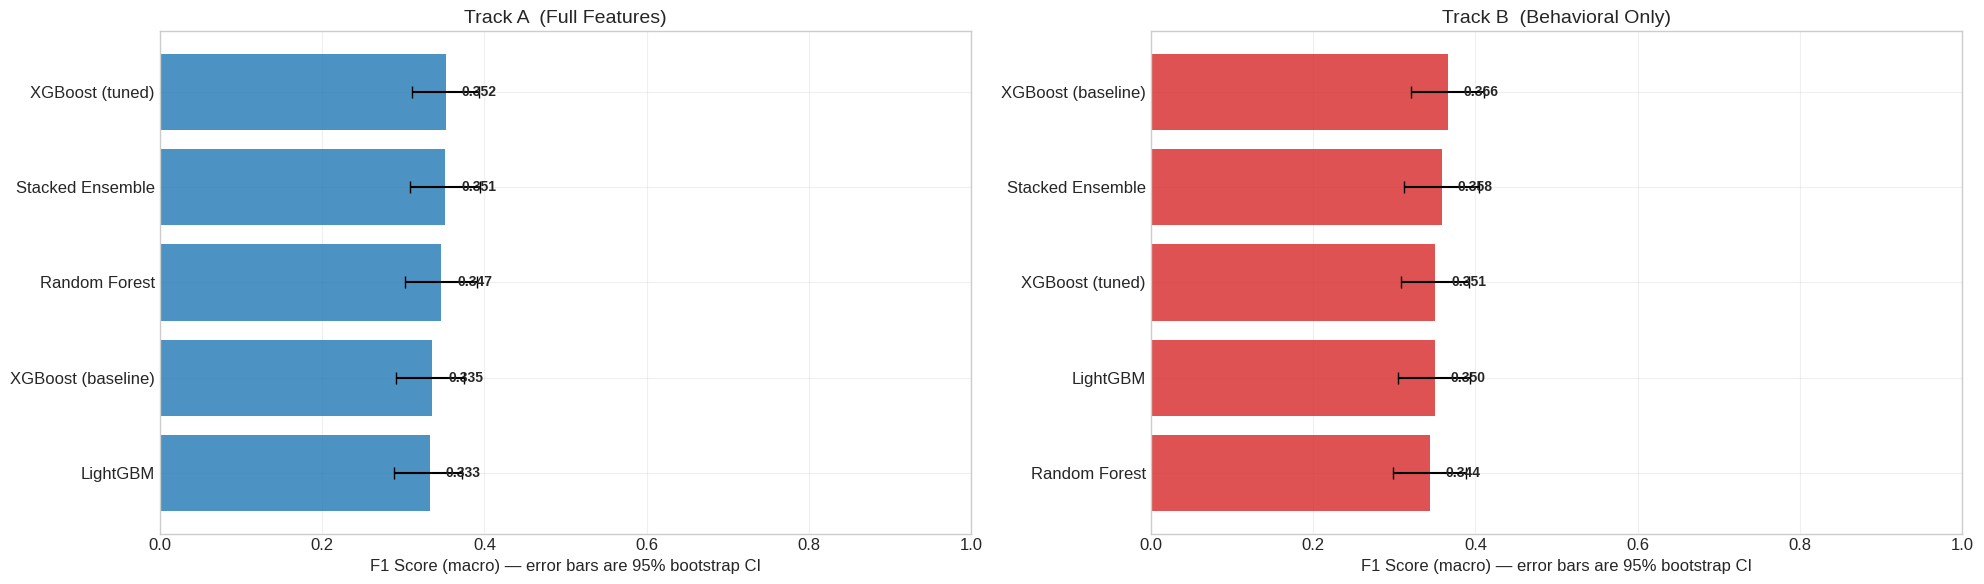

  💾 /content/drive/MyDrive/quic-project/quic_results/final_model_comparison.png


In [ ]:
N_BOOTSTRAP = 1000
def bootstrap_f1_ci(y_true, y_pred, n_boot: int = N_BOOTSTRAP, seed: int = SEED):
    rng = np.random.RandomState(seed)
    n = len(y_true)
    scores = np.empty(n_boot, dtype="float64")
    for i in range(n_boot):
        idx = rng.randint(0, n, n)
        scores[i] = f1_score(y_true[idx], y_pred[idx], average="macro")
    return float(scores.mean()), float(np.percentile(scores, 2.5)), float(np.percentile(scores, 97.5))
print(f"  Computing bootstrap 95% CIs ({N_BOOTSTRAP} resamples)...\n")
all_models = [
    ("XGBoost (baseline)",  "A", results_xgb_A["y_pred"]),
    ("XGBoost (baseline)",  "B", results_xgb_B["y_pred"]),
    ("XGBoost (tuned)",     "A", tuned_xgb_A["y_pred"]),
    ("XGBoost (tuned)",     "B", tuned_xgb_B["y_pred"]),
    ("LightGBM",            "A", results_lgb_A["y_pred"]),
    ("LightGBM",            "B", results_lgb_B["y_pred"]),
    ("Random Forest",       "A", results_rf_A["y_pred"]),
    ("Random Forest",       "B", results_rf_B["y_pred"]),
    ("Stacked Ensemble",    "A", results_stack_A["y_pred"]),
    ("Stacked Ensemble",    "B", results_stack_B["y_pred"]),
]
rows = []
for name, track, y_pred in all_models:
    mean_f1, lo, hi = bootstrap_f1_ci(y_test, y_pred)
    rows.append({
        "Model":           name,
        "Track":           track,
        "Accuracy":        accuracy_score(y_test, y_pred),
        "F1_macro":        f1_score(y_test, y_pred, average="macro"),
        "F1_weighted":     f1_score(y_test, y_pred, average="weighted"),
        "F1_macro_CI_lo":  lo,
        "F1_macro_CI_hi":  hi,
        "F1_macro_CI_str": f"{mean_f1:.4f}  ({lo:.4f}, {hi:.4f})",
    })
final_table = pd.DataFrame(rows)
final_table_display = final_table.copy()
for c in ["Accuracy", "F1_macro", "F1_weighted"]:
    final_table_display[c] = final_table_display[c].apply(lambda x: f"{x:.4f}")
print(f"\n{'=' * 90}")
print(f"FINAL TEST-SET RESULTS  (95% bootstrap CIs on F1_macro)")
print(f"{'=' * 90}")
cols_show = ["Model", "Track", "Accuracy", "F1_macro", "F1_weighted", "F1_macro_CI_str"]
print(final_table_display[cols_show].to_string(index=False))
best_A = final_table[final_table.Track == "A"].sort_values("F1_macro", ascending=False).iloc[0]
best_B = final_table[final_table.Track == "B"].sort_values("F1_macro", ascending=False).iloc[0]
print(f"\n  ⭐ Best Track A  : {best_A['Model']}  "
      f"F1={best_A['F1_macro']:.4f}  [CI: {best_A['F1_macro_CI_lo']:.4f}, {best_A['F1_macro_CI_hi']:.4f}]")
print(f"  ⭐ Best Track B  : {best_B['Model']}  "
      f"F1={best_B['F1_macro']:.4f}  [CI: {best_B['F1_macro_CI_lo']:.4f}, {best_B['F1_macro_CI_hi']:.4f}]")
final_table.to_csv(Path(RESULTS_DIR) / "final_model_comparison.csv", index=False)
print(f"\n   {Path(RESULTS_DIR) / 'final_model_comparison.csv'}")
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
for ax, track in zip(axes, ["A", "B"]):
    sub = final_table[final_table.Track == track].sort_values("F1_macro")
    ypos = np.arange(len(sub))
    err_lo = sub["F1_macro"].values - sub["F1_macro_CI_lo"].values
    err_hi = sub["F1_macro_CI_hi"].values - sub["F1_macro"].values
    ax.barh(ypos, sub["F1_macro"], xerr=[err_lo, err_hi],
            color=TRACK_COLORS[track], alpha=0.8,
            error_kw={"ecolor": "black", "capsize": 4, "linewidth": 1.5})
    ax.set_yticks(ypos)
    ax.set_yticklabels(sub["Model"])
    ax.set_xlabel("F1 Score (macro) — error bars are 95% bootstrap CI")
    ax.set_title(f"Track {track}  ({'Full Features' if track == 'A' else 'Behavioral Only'})")
    ax.set_xlim(0, 1)
    for i, v in enumerate(sub["F1_macro"]):
        ax.text(v + 0.02, i, f"{v:.3f}", va="center", fontsize=10, fontweight="bold")
plt.tight_layout()
out = save_fig(fig, "final_model_comparison.png")
plt.show()
print(f"   {out}")


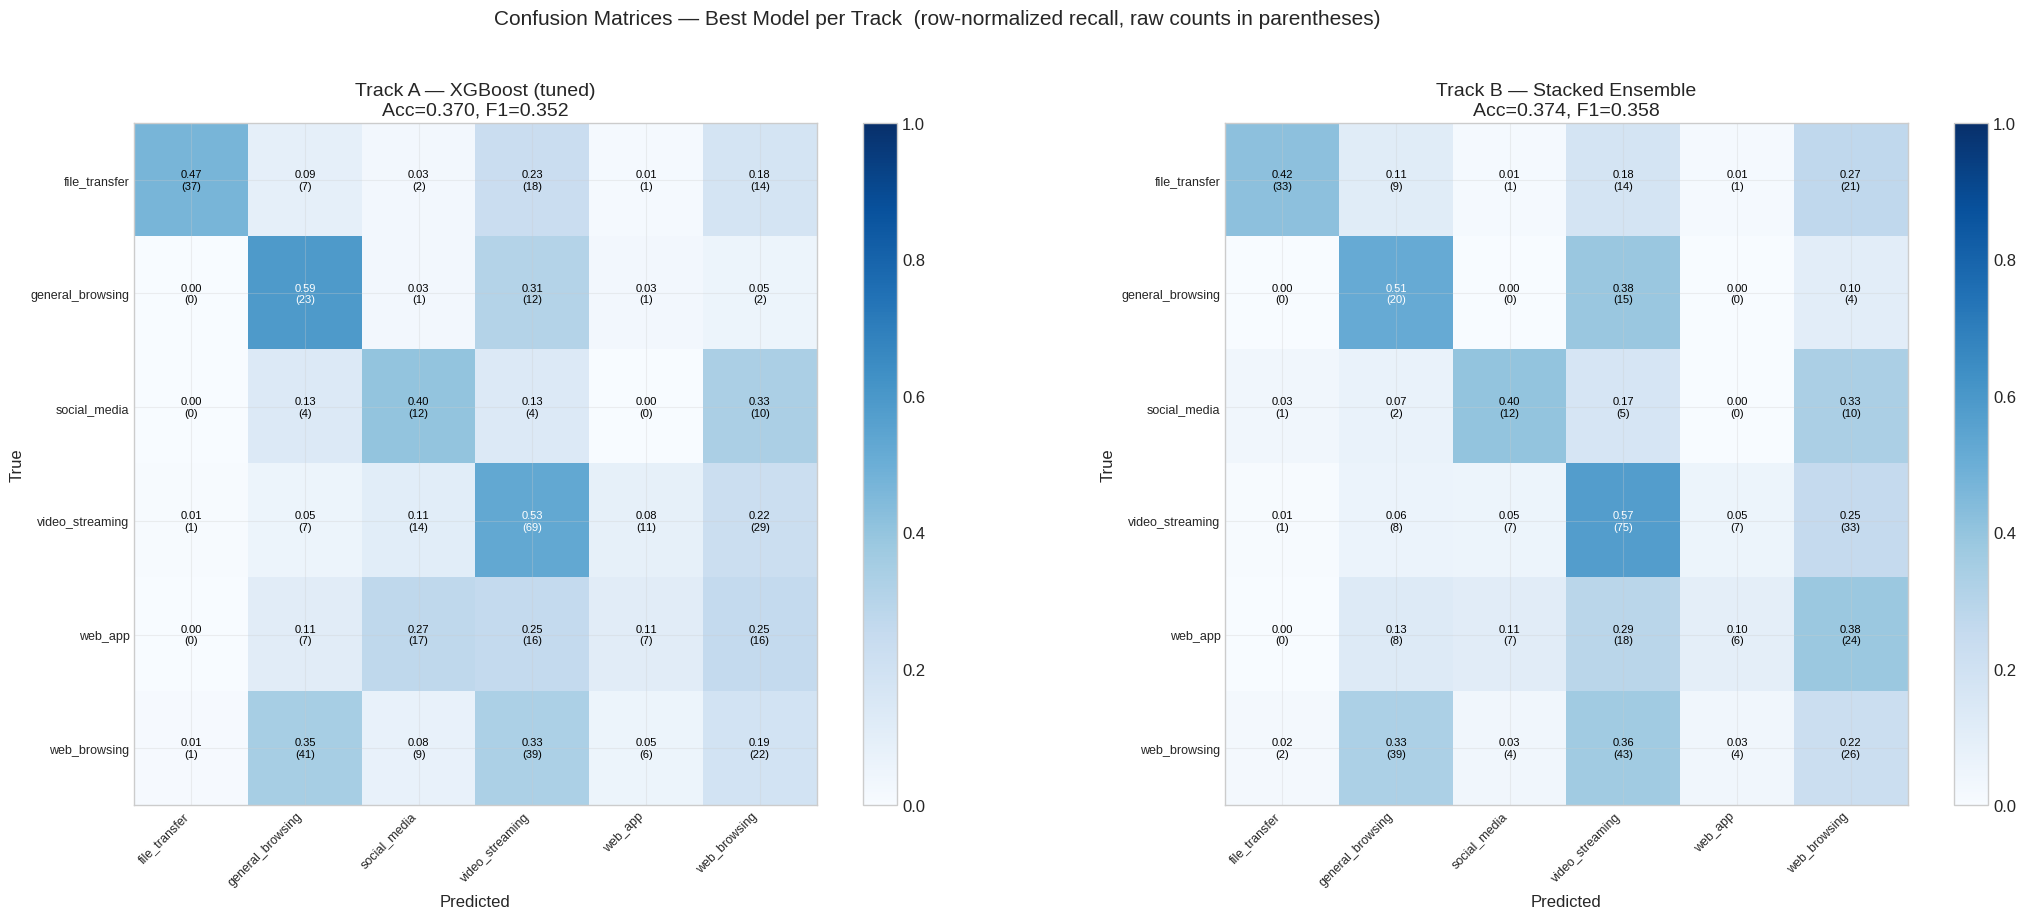

  💾 /content/drive/MyDrive/quic-project/quic_results/confusion_matrices_best.png

────────────────────────────────────────────────────────────────────────
  Per-class report — Track A (XGBoost (tuned)):
────────────────────────────────────────────────────────────────────────
                  precision    recall  f1-score   support

   file_transfer     0.9487    0.4684    0.6271        79
general_browsing     0.2584    0.5897    0.3594        39
    social_media     0.2182    0.4000    0.2824        30
 video_streaming     0.4367    0.5267    0.4775       131
         web_app     0.2692    0.1111    0.1573        63
    web_browsing     0.2366    0.1864    0.2085       118

        accuracy                         0.3696       460
       macro avg     0.3946    0.3804    0.3520       460
    weighted avg     0.4210    0.3696    0.3676       460


────────────────────────────────────────────────────────────────────────
  Per-class report — Track B (Stacked Ensemble):
──────────────────

582

In [ ]:
from sklearn.metrics import confusion_matrix
y_pred_best_A = (tuned_xgb_A["y_pred"]
                 if tuned_xgb_A["f1_macro"] >= results_stack_A["f1_macro"]
                 else results_stack_A["y_pred"])
y_pred_best_B = (tuned_xgb_B["y_pred"]
                 if tuned_xgb_B["f1_macro"] >= results_stack_B["f1_macro"]
                 else results_stack_B["y_pred"])
best_name_A = "XGBoost (tuned)" if tuned_xgb_A["f1_macro"] >= results_stack_A["f1_macro"] else "Stacked Ensemble"
best_name_B = "XGBoost (tuned)" if tuned_xgb_B["f1_macro"] >= results_stack_B["f1_macro"] else "Stacked Ensemble"
def plot_confusion(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(n_classes))
    cm_n = cm.astype("float") / cm.sum(axis=1, keepdims=True).clip(min=1)
    im = ax.imshow(cm_n, cmap="Blues", vmin=0, vmax=1)
    for i in range(n_classes):
        for j in range(n_classes):
            val   = cm_n[i, j]
            count = cm[i, j]
            color = "white" if val > 0.5 else "black"
            ax.text(j, i, f"{val:.2f}\n({count})", ha="center", va="center",
                    color=color, fontsize=8)
    ax.set_xticks(range(n_classes))
    ax.set_yticks(range(n_classes))
    ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(class_names, fontsize=9)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title)
    return im
fig, axes = plt.subplots(1, 2, figsize=(22, 9))
im1 = plot_confusion(axes[0], y_test, y_pred_best_A,
                     f"Track A — {best_name_A}\n"
                     f"Acc={accuracy_score(y_test, y_pred_best_A):.3f}, "
                     f"F1={f1_score(y_test, y_pred_best_A, average='macro'):.3f}")
im2 = plot_confusion(axes[1], y_test, y_pred_best_B,
                     f"Track B — {best_name_B}\n"
                     f"Acc={accuracy_score(y_test, y_pred_best_B):.3f}, "
                     f"F1={f1_score(y_test, y_pred_best_B, average='macro'):.3f}")
fig.colorbar(im1, ax=axes[0], fraction=0.04)
fig.colorbar(im2, ax=axes[1], fraction=0.04)
plt.suptitle("Confusion Matrices — Best Model per Track  "
             "(row-normalized recall, raw counts in parentheses)",
             fontsize=15, y=1.02)
plt.tight_layout()
out = save_fig(fig, "confusion_matrices_best.png")
plt.show()
print(f"   {out}")
print(f"\n{'─' * 72}")
print(f"  Per-class report — Track A ({best_name_A}):")
print(f"{'─' * 72}")
print(classification_report(y_test, y_pred_best_A, target_names=class_names,
                            digits=4, zero_division=0))
print(f"\n{'─' * 72}")
print(f"  Per-class report — Track B ({best_name_B}):")
print(f"{'─' * 72}")
print(classification_report(y_test, y_pred_best_B, target_names=class_names,
                            digits=4, zero_division=0))
(Path(RESULTS_DIR) / "classification_report_track_a.txt").write_text(
    classification_report(y_test, y_pred_best_A, target_names=class_names, digits=4, zero_division=0))
(Path(RESULTS_DIR) / "classification_report_track_b.txt").write_text(
    classification_report(y_test, y_pred_best_B, target_names=class_names, digits=4, zero_division=0))


  Computing SHAP for 460 test samples...
  Done in 0.1s
  SHAP type: ndarray, shape: (460, 257, 6)


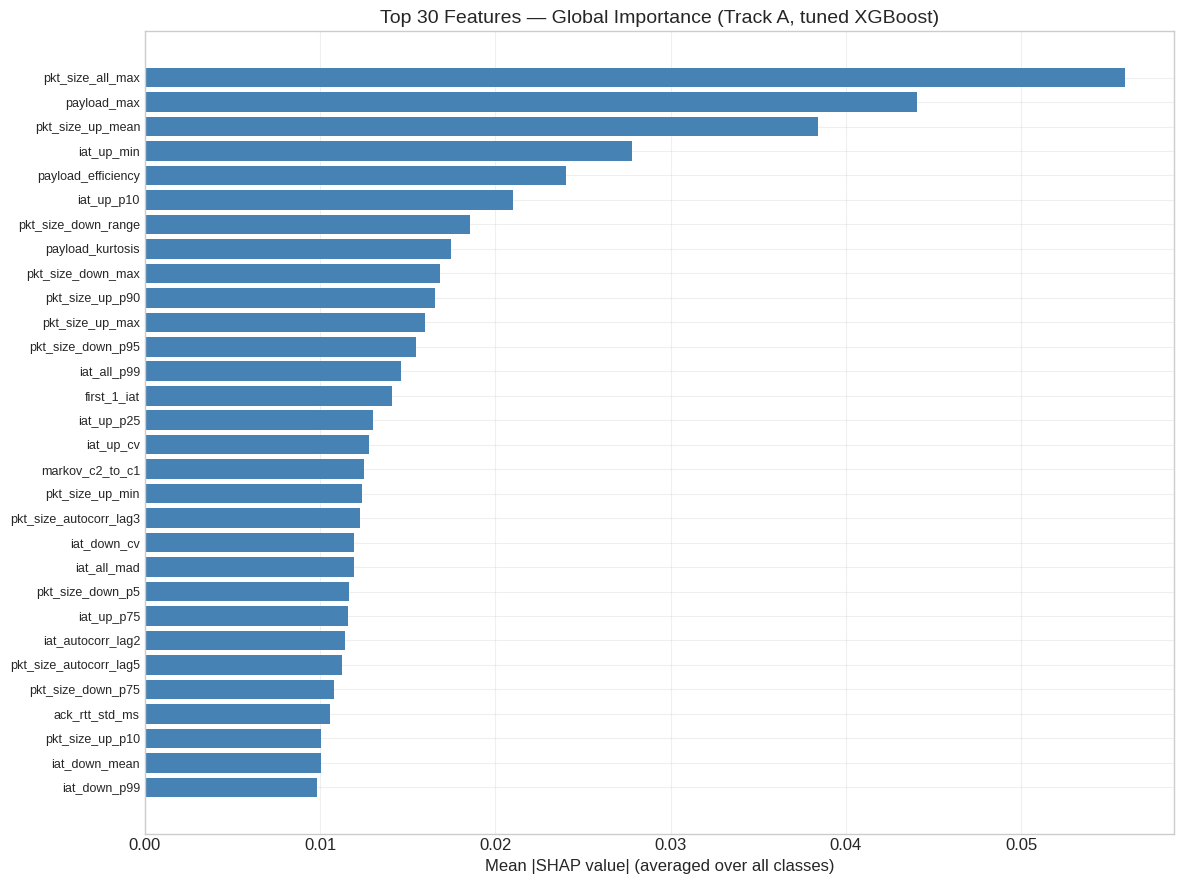

  💾 /content/drive/MyDrive/quic-project/quic_results/shap_global_importance.png


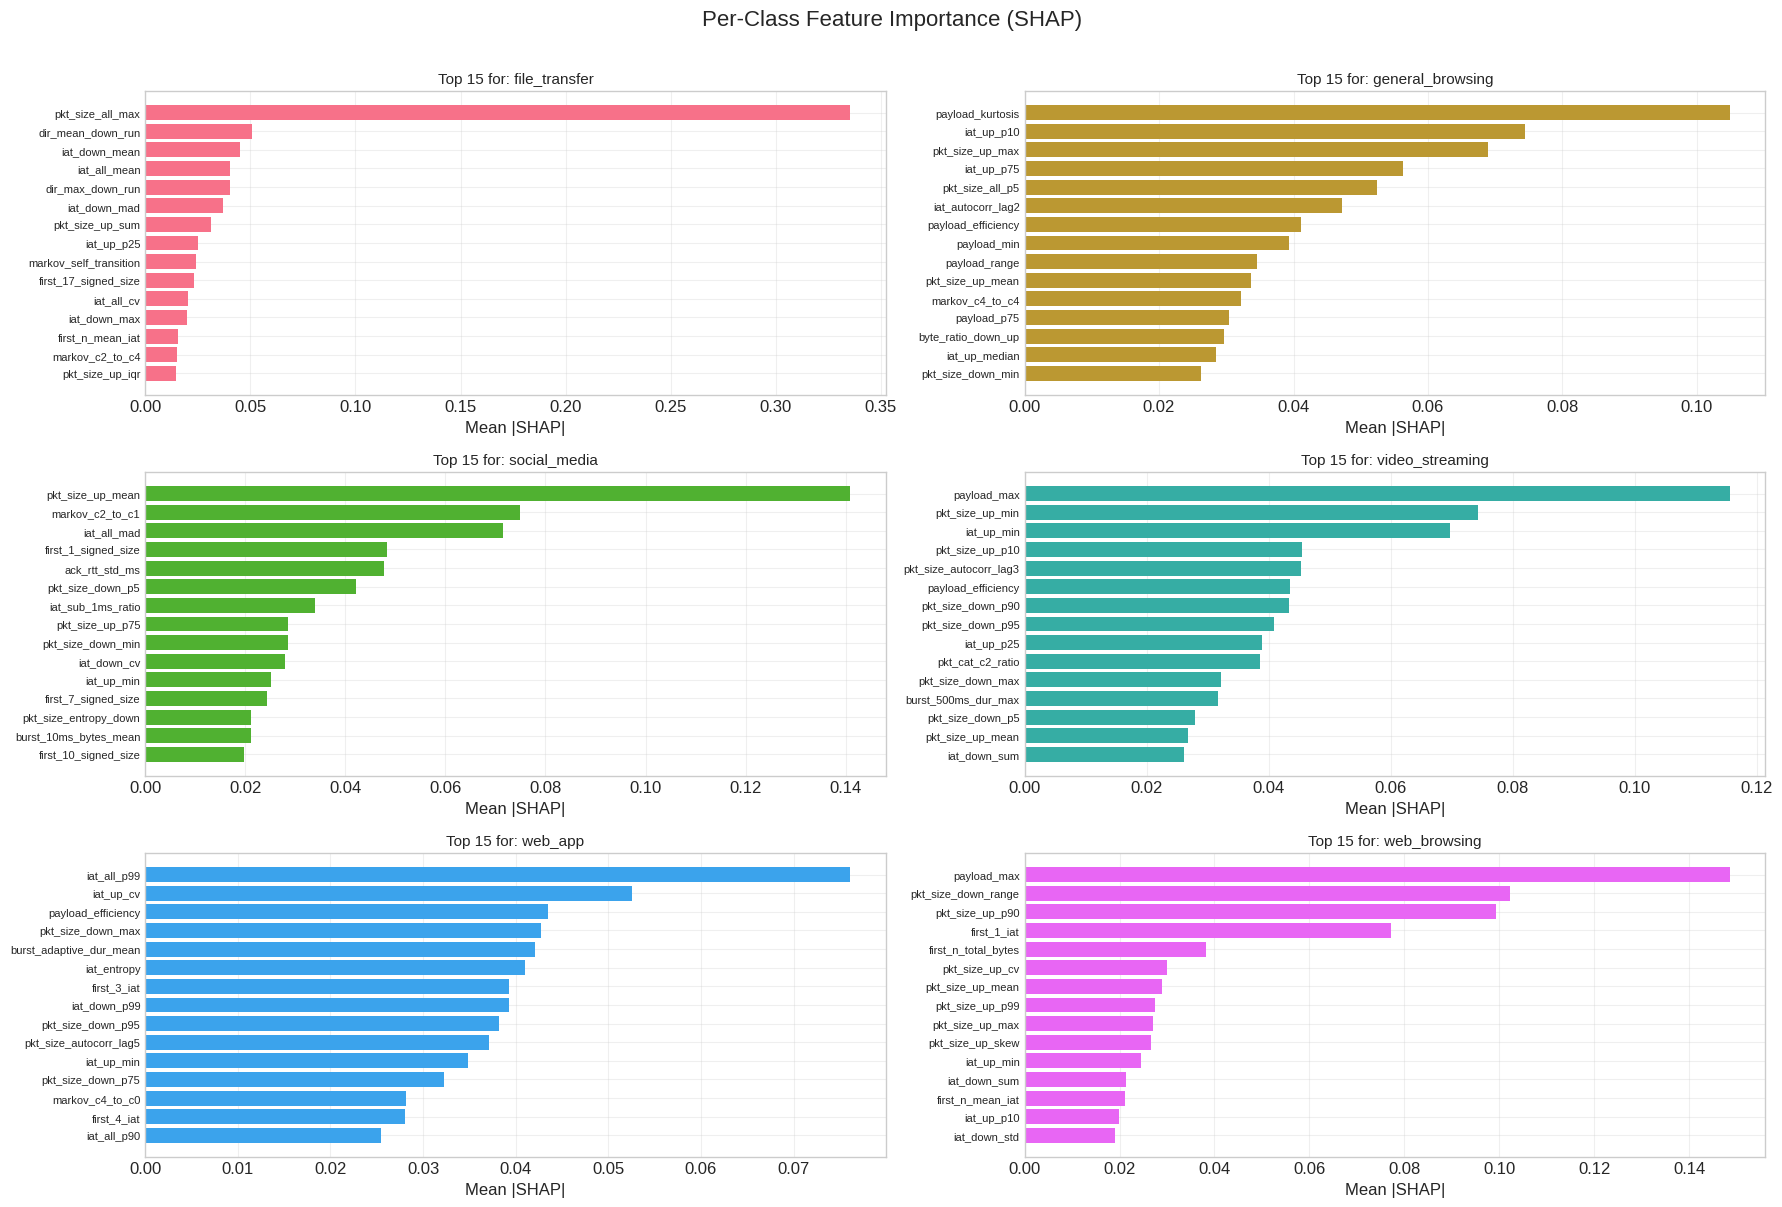

  💾 /content/drive/MyDrive/quic-project/quic_results/shap_per_class.png


In [ ]:
import shap
shap_model    = tuned_xgb_A["model"]
shap_X_source = XA_test_with_nan
n_shap = min(800, len(shap_X_source))
shap_X = shap_X_source.sample(n=n_shap, random_state=SEED)
print(f"  Computing SHAP for {n_shap} test samples...")
t0 = time.time()
explainer = shap.TreeExplainer(
    shap_model,
    model_output="raw",
    feature_perturbation="tree_path_dependent",
)
shap_values = explainer.shap_values(shap_X)
print(f"  Done in {time.time() - t0:.1f}s")
print(f"  SHAP type: {type(shap_values).__name__}, "
      f"shape: {getattr(shap_values, 'shape', [a.shape for a in shap_values][:1] if isinstance(shap_values, list) else 'N/A')}")
if isinstance(shap_values, list):
    shap_arr_3d = np.stack(shap_values, axis=-1)
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_arr_3d = shap_values
else:
    shap_arr_3d = shap_values[..., np.newaxis]
mean_abs_global = np.mean(np.abs(shap_arr_3d), axis=(0, 2))
imp_series = pd.Series(mean_abs_global, index=shap_X.columns).sort_values(ascending=False)
top_n = 30
top = imp_series.head(top_n).sort_values()
fig, ax = plt.subplots(figsize=(12, max(8, top_n * 0.3)))
ax.barh(top.index, top.values, color="steelblue")
ax.set_xlabel("Mean |SHAP value| (averaged over all classes)")
ax.set_title(f"Top {top_n} Features — Global Importance (Track A, tuned XGBoost)")
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()
out = save_fig(fig, "shap_global_importance.png")
plt.show()
print(f"   {out}")
n_classes_plot = n_classes
n_per_class = 15
fig, axes = plt.subplots((n_classes_plot + 1) // 2, 2,
                          figsize=(18, 4 * ((n_classes_plot + 1) // 2)))
axes = np.array(axes).flatten()
for ci, cname in enumerate(class_names):
    ax = axes[ci]
    class_shap = np.mean(np.abs(shap_arr_3d[:, :, ci]), axis=0)
    cs_series = pd.Series(class_shap, index=shap_X.columns).sort_values(ascending=True)
    top_per_cls = cs_series.tail(n_per_class)
    ax.barh(top_per_cls.index, top_per_cls.values, color=CLASS_COLORS[cname])
    ax.set_title(f"Top {n_per_class} for: {cname}", fontsize=11)
    ax.set_xlabel("Mean |SHAP|")
    ax.tick_params(axis="y", labelsize=8)
for j in range(n_classes_plot, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Per-Class Feature Importance (SHAP)", fontsize=16, y=1.005)
plt.tight_layout()
out = save_fig(fig, "shap_per_class.png")
plt.show()
print(f"   {out}")
imp_series.to_csv(Path(RESULTS_DIR) / "shap_global_importance.csv",
                  header=["mean_abs_shap"])



FEATURE CATEGORY IMPORTANCE (aggregated SHAP)
                                 total_importance  mean_importance  n_features  pct_of_total
category                                                                                    
A: Packet Size                             0.3513           0.0060          59     33.134800
B: Inter-Arrival Time                      0.2656           0.0060          44     25.054701
E: Direction & First-N                     0.1758           0.0024          72     16.583401
I: Payload Patterns                        0.1216           0.0061          20     11.468500
H: Markov & Sequence                       0.0570           0.0020          29      5.375300
I: Sequence Patterns                       0.0335           0.0067           5      3.158100
C: Burst & Periodicity                     0.0268           0.0014          19      2.532700
D: Flow & Throughput                       0.0143           0.0048           3      1.351900
J: ACK & Handshake RTT 

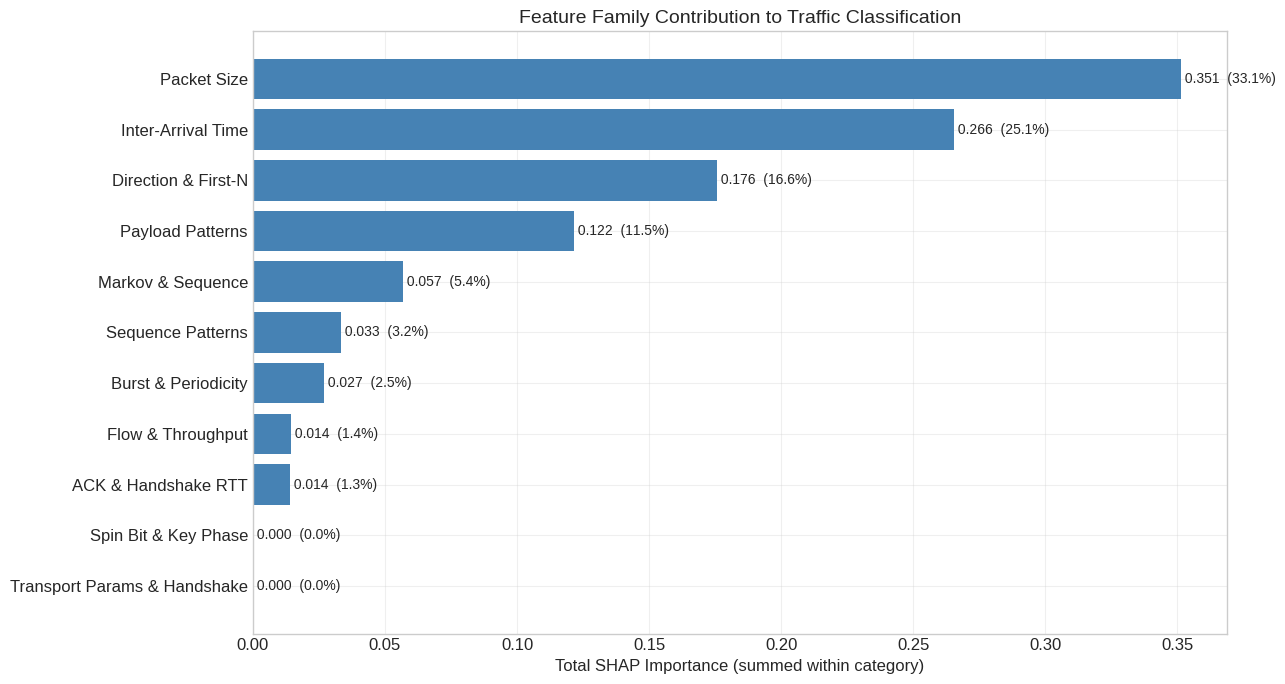

  💾 /content/drive/MyDrive/quic-project/quic_results/shap_category_importance.png


In [ ]:
def feature_category(name: str) -> str:
    if name.startswith("pkt_size_autocorr"):       return "I: Sequence Patterns"
    if name.startswith("pkt_size") or name.startswith("pkt_small") or \
       name.startswith("pkt_medium") or name.startswith("pkt_large") or \
       name.startswith("pkt_mtu") or name.startswith("byte_ratio") or \
       name.startswith("download") or name.startswith("upload") or \
       name.startswith("n_distinct_sizes") or name.startswith("pkt_cat") or \
       name.startswith("has_upload") or name.startswith("has_download"):
        return "A: Packet Size"
    if name.startswith("iat"):                     return "B: Inter-Arrival Time"
    if name.startswith("burst") or name.startswith("psd"):
        return "C: Burst & Periodicity"
    if name.startswith("flow") or name.startswith("rate"):
        return "D: Flow & Throughput"
    if name.startswith("dir") or name.startswith("first_"):
        return "E: Direction & First-N"
    if name.startswith("spin") or name.startswith("key_phase") or \
       name.startswith("n_short"):
        return "F: Spin Bit & Key Phase"
    if name.startswith("tp_") or name.startswith("quic_transport_parameter_") or \
       name.startswith("has_initial") or name.startswith("has_0rtt") or \
       name.startswith("has_handshake") or name.startswith("has_retry") or \
       name.startswith("handshake") or name.startswith("dcid") or \
       name.startswith("n_unique") or name.startswith("long_header") or \
       name.startswith("client_ttl") or name.startswith("estimated_hops") or \
       name.startswith("dscp") or name.startswith("ecn") or \
       name.startswith("server_port"):
        return "G: Transport Params & Handshake"
    if name.startswith("markov") or name.startswith("consecutive") or \
       name.startswith("max_same"):
        return "H: Markov & Sequence"
    if name.startswith("payload"):                 return "I: Payload Patterns"
    if name.startswith("ack_rtt") or name.startswith("server_processing"):
        return "J: ACK & Handshake RTT"
    if name == "n_packets":                        return "K: Connection Size"
    return "Other"
feature_groups = pd.DataFrame({
    "feature":  imp_series.index,
    "shap":     imp_series.values,
    "category": [feature_category(f) for f in imp_series.index],
})
group_summary = (feature_groups.groupby("category")
                                .agg(total_importance=("shap", "sum"),
                                     mean_importance=("shap", "mean"),
                                     n_features=("shap", "count"))
                                .sort_values("total_importance", ascending=False))
group_summary["pct_of_total"] = group_summary["total_importance"] / group_summary["total_importance"].sum() * 100
print(f"\n{'=' * 72}")
print(f"FEATURE CATEGORY IMPORTANCE (aggregated SHAP)")
print(f"{'=' * 72}")
print(group_summary.round(4).to_string())
fig, ax = plt.subplots(figsize=(13, 7))
short_names = [c.split(": ", 1)[1] if ": " in c else c for c in group_summary.index]
ax.barh(short_names, group_summary["total_importance"], color="steelblue")
for i, (v, pct) in enumerate(zip(group_summary["total_importance"],
                                   group_summary["pct_of_total"])):
    ax.text(v, i, f" {v:.3f}  ({pct:.1f}%)", va="center", fontsize=10)
ax.set_xlabel("Total SHAP Importance (summed within category)")
ax.set_title("Feature Family Contribution to Traffic Classification")
ax.invert_yaxis()
plt.tight_layout()
out = save_fig(fig, "shap_category_importance.png")
plt.show()
print(f"   {out}")
group_summary.to_csv(Path(RESULTS_DIR) / "shap_category_importance.csv")



────────────────────────────────────────────────────────────────────────
  Per-class metrics — Track A (XGBoost (tuned))
────────────────────────────────────────────────────────────────────────
           Class  Support  Precision  Recall     F1  F1 CI Lo  F1 CI Hi
   file_transfer       79     0.9487  0.4684 0.6271    0.5124    0.7257
general_browsing       39     0.2584  0.5897 0.3594    0.2500    0.4691
    social_media       30     0.2182  0.4000 0.2824    0.1538    0.4124
 video_streaming      131     0.4367  0.5267 0.4775    0.4046    0.5502
         web_app       63     0.2692  0.1111 0.1573    0.0533    0.2479
    web_browsing      118     0.2366  0.1864 0.2085    0.1379    0.2743

────────────────────────────────────────────────────────────────────────
  Per-class metrics — Track B (Stacked Ensemble)
────────────────────────────────────────────────────────────────────────
           Class  Support  Precision  Recall     F1  F1 CI Lo  F1 CI Hi
   file_transfer       79     0.8

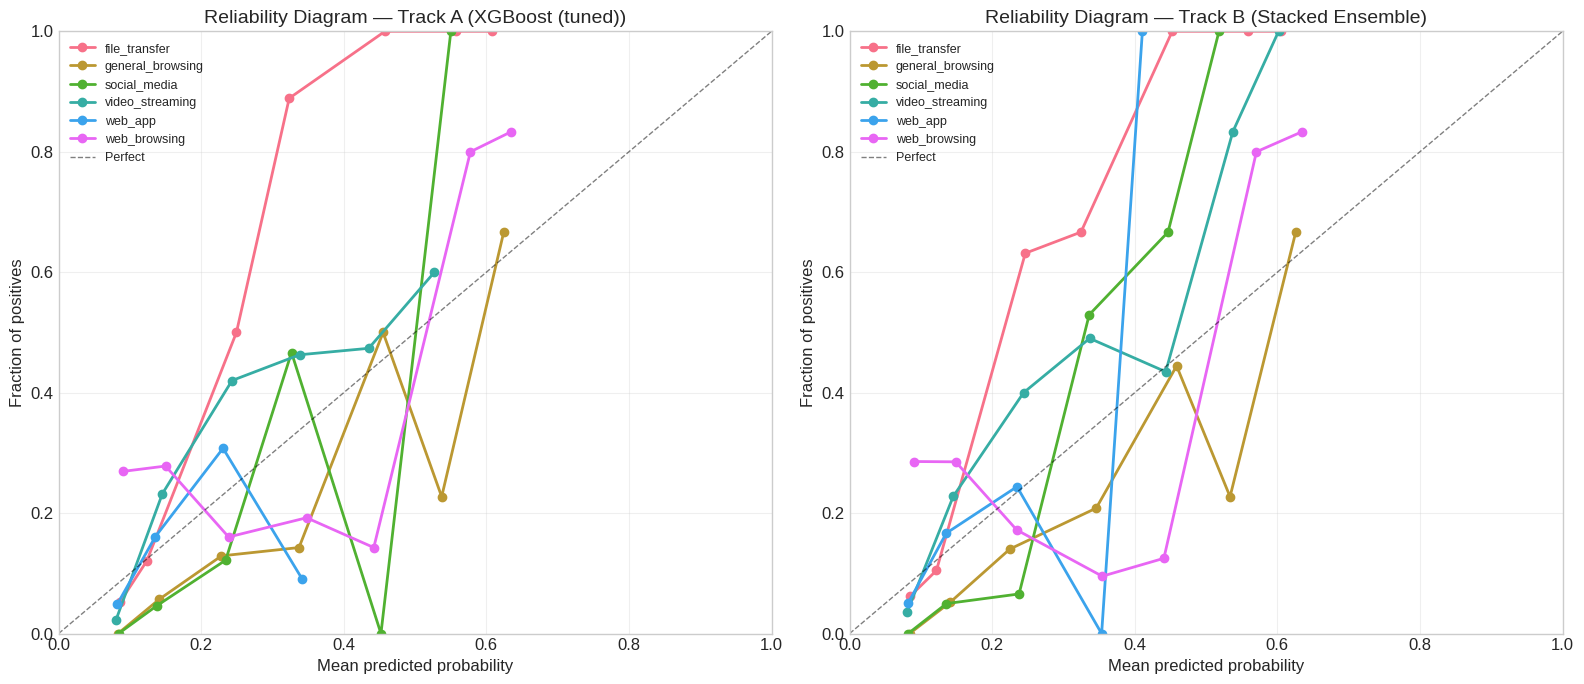

  💾 /content/drive/MyDrive/quic-project/quic_results/reliability_diagrams.png


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score as sk_f1
from sklearn.calibration import calibration_curve
def per_class_bootstrap_ci(y_true, y_pred, n_classes, n_boot=N_BOOTSTRAP, seed=SEED):
    rng = np.random.RandomState(seed)
    n = len(y_true)
    out = []
    for ci in range(n_classes):
        f1s = np.empty(n_boot, dtype="float64")
        for b in range(n_boot):
            idx = rng.randint(0, n, n)
            mask = (y_true[idx] == ci) | (y_pred[idx] == ci)
            if mask.sum() == 0:
                f1s[b] = np.nan
                continue
            f1s[b] = sk_f1(y_true[idx], y_pred[idx], labels=[ci],
                            average="macro", zero_division=0)
        f1s = f1s[~np.isnan(f1s)]
        if len(f1s) == 0:
            out.append((np.nan, np.nan, np.nan))
        else:
            out.append((float(f1s.mean()),
                        float(np.percentile(f1s, 2.5)),
                        float(np.percentile(f1s, 97.5))))
    return out
def per_class_metrics_table(y_true, y_pred, y_prob, label):
    print(f"\n{'─' * 72}")
    print(f"  Per-class metrics — {label}")
    print(f"{'─' * 72}")
    prec = precision_score(y_true, y_pred, average=None, zero_division=0)
    rec  = recall_score(y_true, y_pred, average=None, zero_division=0)
    f1s  = sk_f1(y_true, y_pred, average=None, zero_division=0)
    ci   = per_class_bootstrap_ci(y_true, y_pred, n_classes)
    rows = []
    for i, name in enumerate(class_names):
        support = int((y_true == i).sum())
        mean_ci, lo, hi = ci[i]
        rows.append({
            "Class":      name,
            "Support":    support,
            "Precision":  prec[i],
            "Recall":     rec[i],
            "F1":         f1s[i],
            "F1 CI Lo":   lo,
            "F1 CI Hi":   hi,
        })
    df = pd.DataFrame(rows)
    print(df.round(4).to_string(index=False))
    return df
per_class_A = per_class_metrics_table(y_test, y_pred_best_A,
                                       tuned_xgb_A["y_prob"],
                                       f"Track A ({best_name_A})")
per_class_B = per_class_metrics_table(y_test, y_pred_best_B,
                                       tuned_xgb_B["y_prob"],
                                       f"Track B ({best_name_B})")
per_class_A.to_csv(Path(RESULTS_DIR) / "per_class_metrics_track_a.csv", index=False)
per_class_B.to_csv(Path(RESULTS_DIR) / "per_class_metrics_track_b.csv", index=False)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax_idx, (label, y_prob) in enumerate([
    (f"Track A ({best_name_A})", tuned_xgb_A["y_prob"]),
    (f"Track B ({best_name_B})", tuned_xgb_B["y_prob"]),
]):
    ax = axes[ax_idx]
    for ci, cname in enumerate(class_names):
        y_bin = (y_test == ci).astype(int)
        if y_bin.sum() < 5:
            continue
        try:
            frac_pos, mean_pred = calibration_curve(y_bin, y_prob[:, ci],
                                                     n_bins=10, strategy="uniform")
            ax.plot(mean_pred, frac_pos, "o-", color=CLASS_COLORS[cname], label=cname,
                    linewidth=2, markersize=6)
        except ValueError:
            continue
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Perfect")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.set_title(f"Reliability Diagram — {label}")
    ax.legend(fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout()
out = save_fig(fig, "reliability_diagrams.png")
plt.show()
print(f"   {out}")


  Running 7 ablations with 5-fold group-CV...
     All Features (Track A)               n= 257  F1 = 0.2409 ± 0.0775
     Behavioral Only (Track B)            n= 256  F1 = 0.2376 ± 0.0835
     No Transport Params                  n= 257  F1 = 0.2409 ± 0.0775
     No First-N Features                  n= 192  F1 = 0.2487 ± 0.0846
     First-N Only                         n=  65  F1 = 0.1935 ± 0.0543
     Burst + Periodicity Only             n=  19  F1 = 0.1732 ± 0.0450
     Packet-Size Only                     n=  62  F1 = 0.2374 ± 0.0642


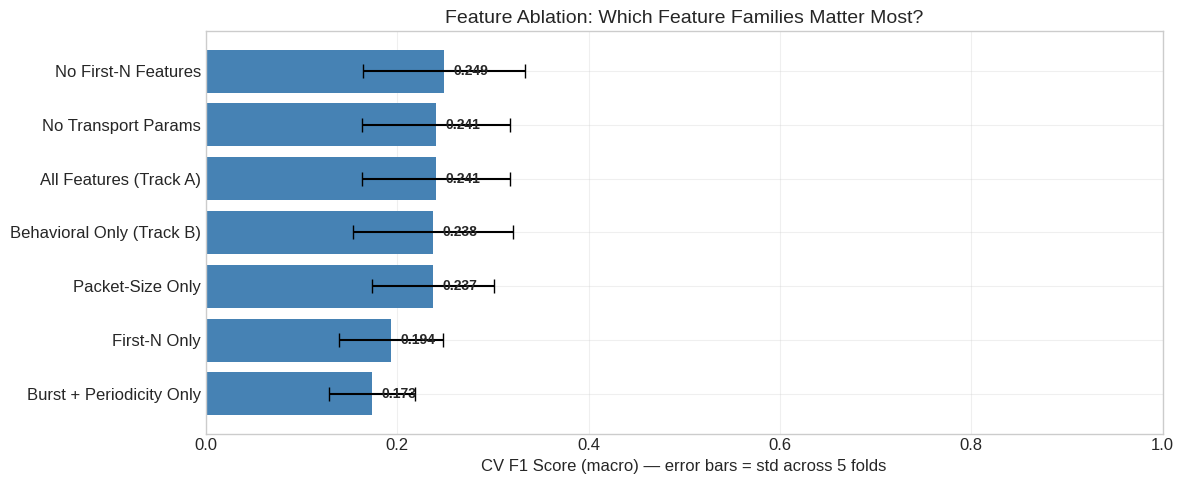


  💾 /content/drive/MyDrive/quic-project/quic_results/feature_ablation.png


In [ ]:
def ablation_feature_set(name: str, predicate) -> list:
    cols = [c for c in TRACK_A_FEATURES if predicate(c)]
    return cols
ABLATION_SETS = {
    "All Features (Track A)":      TRACK_A_FEATURES,
    "Behavioral Only (Track B)":   TRACK_B_FEATURES,
    "No Transport Params":         [c for c in TRACK_A_FEATURES
                                     if not (c.startswith("tp_") or
                                             c.startswith("quic_transport_parameter_") or
                                             c in {"long_header_ratio", "dcid_length",
                                                   "n_unique_dcids", "has_initial",
                                                   "has_0rtt", "has_handshake", "has_retry",
                                                   "handshake_duration"})],
    "No First-N Features":         [c for c in TRACK_A_FEATURES if not c.startswith("first_")],
    "First-N Only":                [c for c in TRACK_A_FEATURES if c.startswith("first_")],
    "Burst + Periodicity Only":    [c for c in TRACK_A_FEATURES if c.startswith(("burst_", "psd_"))],
    "Packet-Size Only":            [c for c in TRACK_A_FEATURES if c.startswith(("pkt_size", "pkt_small",
                                                                                  "pkt_medium", "pkt_large",
                                                                                  "pkt_mtu", "n_distinct_sizes",
                                                                                  "pkt_cat", "byte_ratio",
                                                                                  "download_", "upload_"))],
}
ABLATION_SETS = {k: v for k, v in ABLATION_SETS.items()
                  if len(v) >= 5 and all(c in feature_matrix_ml.columns for c in v)}
print(f"  Running {len(ABLATION_SETS)} ablations with {N_FOLDS}-fold group-CV...")
ablation_rows = []
for name, cols in ABLATION_SETS.items():
    X_dev_ab = feature_matrix_ml.iloc[dev_idx][cols].astype("float32") \
                                .replace([np.inf, -np.inf], np.nan)
    scores = []
    for tr, va in cv.split(X_dev_ab, y_dev, groups=groups_dev):
        sw = compute_sample_weight("balanced", y_dev[tr])
        model = build_xgb_model(n_classes,
                                 int(len(y_dev) * (N_FOLDS-1) / N_FOLDS),
                                 X_dev_ab.shape[1])
        model.fit(X_dev_ab.iloc[tr], y_dev[tr],
                  sample_weight=sw,
                  eval_set=[(X_dev_ab.iloc[va], y_dev[va])],
                  verbose=False)
        pred = model.predict(X_dev_ab.iloc[va])
        scores.append(f1_score(y_dev[va], pred, average="macro"))
    mean_f1 = float(np.mean(scores)); std_f1 = float(np.std(scores))
    ablation_rows.append({
        "Feature Set":  name,
        "N Features":   len(cols),
        "CV F1_macro":  mean_f1,
        "CV F1_std":    std_f1,
    })
    print(f"     {name:<35}  n={len(cols):>4}  F1 = {mean_f1:.4f} ± {std_f1:.4f}")
ablation_df = pd.DataFrame(ablation_rows).sort_values("CV F1_macro", ascending=False)
ablation_df.to_csv(Path(RESULTS_DIR) / "feature_ablation.csv", index=False)
fig, ax = plt.subplots(figsize=(12, max(5, len(ablation_df) * 0.5)))
sorted_for_plot = ablation_df.sort_values("CV F1_macro")
ypos = np.arange(len(sorted_for_plot))
ax.barh(ypos, sorted_for_plot["CV F1_macro"],
        xerr=sorted_for_plot["CV F1_std"],
        color="steelblue", error_kw={"ecolor": "black", "capsize": 5})
ax.set_yticks(ypos)
ax.set_yticklabels(sorted_for_plot["Feature Set"])
ax.set_xlabel("CV F1 Score (macro) — error bars = std across 5 folds")
ax.set_xlim(0, 1)
ax.set_title("Feature Ablation: Which Feature Families Matter Most?")
for i, v in enumerate(sorted_for_plot["CV F1_macro"]):
    ax.text(v + 0.01, i, f"{v:.3f}", va="center", fontsize=10, fontweight="bold")
plt.tight_layout()
out = save_fig(fig, "feature_ablation.png")
plt.show()
print(f"\n   {out}")


  Building early-classification curve (6 points)...

     n=  3  A (with TP)   features=  6  F1=0.2459 ± 0.0369
     n=  3  B (no TP)     features=  5  F1=0.2419 ± 0.0490
     n=  5  A (with TP)   features= 10  F1=0.2257 ± 0.0546
     n=  5  B (no TP)     features=  9  F1=0.2249 ± 0.0422
     n= 10  A (with TP)   features= 20  F1=0.2315 ± 0.0447
     n= 10  B (no TP)     features= 19  F1=0.2339 ± 0.0462
     n= 15  A (with TP)   features= 30  F1=0.2177 ± 0.0389
     n= 15  B (no TP)     features= 29  F1=0.2237 ± 0.0369
     n= 20  A (with TP)   features= 40  F1=0.2136 ± 0.0401
     n= 20  B (no TP)     features= 39  F1=0.2281 ± 0.0503
     n= 30  A (with TP)   features= 60  F1=0.2153 ± 0.0345
     n= 30  B (no TP)     features= 59  F1=0.2226 ± 0.0375


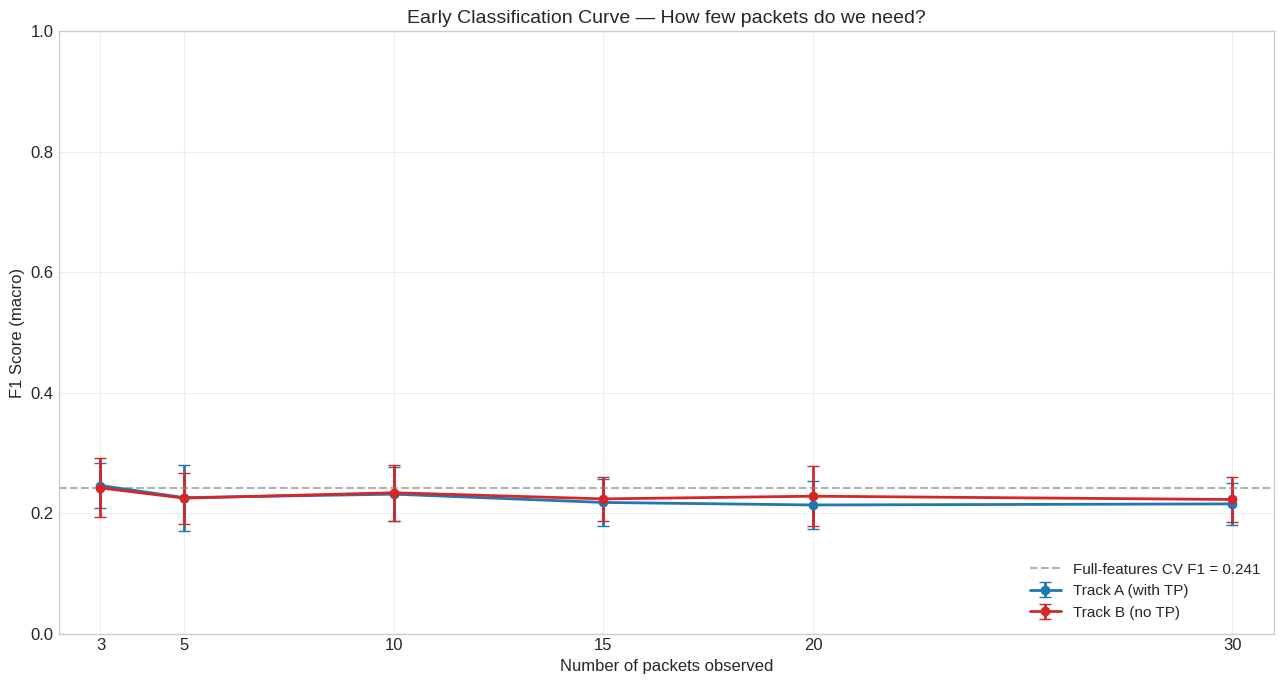


  💾 /content/drive/MyDrive/quic-project/quic_results/early_classification.png


In [ ]:
def early_features(n_pkts: int) -> list:
    base = [f"first_{i}_signed_size" for i in range(n_pkts)] + \
           [f"first_{i}_iat"         for i in range(n_pkts)]
    aggr_safe = ["first_n_available"]
    tp_safe = [c for c in TRACK_A_FEATURES if c.startswith("tp_")]
    cols = list(set(base + aggr_safe + tp_safe))
    return [c for c in cols if c in feature_matrix_ml.columns]
N_PACKET_VALUES = [3, 5, 10, 15, 20, 30]
def early_features_B(n_pkts: int) -> list:
    base = [f"first_{i}_signed_size" for i in range(n_pkts)] + \
           [f"first_{i}_iat"         for i in range(n_pkts)]
    return [c for c in base if c in feature_matrix_ml.columns]
print(f"  Building early-classification curve ({len(N_PACKET_VALUES)} points)...\n")
early_rows = []
for n_pkts in N_PACKET_VALUES:
    for track_label, feat_fn, palette in [("A (with TP)", early_features, TRACK_COLORS["A"]),
                                            ("B (no TP)",    early_features_B, TRACK_COLORS["B"])]:
        cols = feat_fn(n_pkts)
        if len(cols) < 3:
            continue
        X_dev_e = (feature_matrix_ml.iloc[dev_idx][cols].astype("float32")
                    .replace([np.inf, -np.inf], np.nan))
        scores = []
        for tr, va in cv.split(X_dev_e, y_dev, groups=groups_dev):
            sw = compute_sample_weight("balanced", y_dev[tr])
            model = xgb.XGBClassifier(
                n_estimators=300, max_depth=5, learning_rate=0.08,
                random_state=SEED, n_jobs=-1, tree_method="hist", max_bin=256,
                objective="multi:softprob" if n_classes > 2 else "binary:logistic",
                eval_metric="mlogloss" if n_classes > 2 else "logloss",
                early_stopping_rounds=30,
            )
            model.fit(X_dev_e.iloc[tr], y_dev[tr],
                      sample_weight=sw,
                      eval_set=[(X_dev_e.iloc[va], y_dev[va])], verbose=False)
            scores.append(f1_score(y_dev[va], model.predict(X_dev_e.iloc[va]),
                                    average="macro"))
        early_rows.append({
            "n_packets":   n_pkts,
            "track":       track_label,
            "n_features":  len(cols),
            "f1_mean":     float(np.mean(scores)),
            "f1_std":      float(np.std(scores)),
            "color":       palette,
        })
        print(f"     n={n_pkts:>3}  {track_label:<12}  features={len(cols):>3}  "
              f"F1={np.mean(scores):.4f} ± {np.std(scores):.4f}")
fig, ax = plt.subplots(figsize=(13, 7))
for track_lbl in sorted(set(r["track"] for r in early_rows)):
    sub = [r for r in early_rows if r["track"] == track_lbl]
    xs   = [r["n_packets"]  for r in sub]
    ys   = [r["f1_mean"]    for r in sub]
    errs = [r["f1_std"]     for r in sub]
    color = sub[0]["color"]
    ax.errorbar(xs, ys, yerr=errs, marker="o", linewidth=2, capsize=4,
                color=color, label=f"Track {track_lbl}")
ref = max(cv_xgb_A.mean(), cv_lgb_A.mean(), cv_rf_A.mean())
ax.axhline(ref, color="gray", linestyle="--", alpha=0.6,
           label=f"Full-features CV F1 = {ref:.3f}")
ax.set_xlabel("Number of packets observed")
ax.set_ylabel("F1 Score (macro)")
ax.set_title("Early Classification Curve — How few packets do we need?")
ax.set_xticks(N_PACKET_VALUES)
ax.set_xlim(min(N_PACKET_VALUES) - 1, max(N_PACKET_VALUES) + 1)
ax.set_ylim(0, 1)
ax.legend(fontsize=11, loc="lower right")
plt.tight_layout()
out = save_fig(fig, "early_classification.png")
plt.show()
print(f"\n   {out}")
pd.DataFrame(early_rows).to_csv(Path(RESULTS_DIR) / "early_classification.csv", index=False)


In [ ]:
source_files = feature_matrix_ml["source_file"].unique().tolist()
print(f"  Distinct source files: {len(source_files)}")
if len(source_files) < 3:
    print(f"  [SKIP] Need ≥3 source files for LOO.")
    leave_one_out_results = None
else:
    leave_one_out_rows = []
    print(f"  Running leave-one-file-out CV...\n")
    for held_out in source_files:
        test_mask  = (feature_matrix_ml["source_file"] == held_out).values
        train_mask = ~test_mask
        if test_mask.sum() < 10 or train_mask.sum() < 100:
            continue
        test_labels = feature_matrix_ml.iloc[np.where(test_mask)[0]]["traffic_label"]
        if test_labels.nunique() < 2:
            continue
        X_tr = (feature_matrix_ml.iloc[np.where(train_mask)[0]][TRACK_A_FEATURES]
                 .astype("float32").replace([np.inf, -np.inf], np.nan))
        X_te = (feature_matrix_ml.iloc[np.where(test_mask)[0]][TRACK_A_FEATURES]
                 .astype("float32").replace([np.inf, -np.inf], np.nan))
        y_tr_orig = y_all[np.where(train_mask)[0]]
        y_te_orig = y_all[np.where(test_mask)[0]]
        local_classes = np.unique(y_tr_orig)
        if len(local_classes) < 2:
            continue
        local_map = {c: i for i, c in enumerate(local_classes)}
        y_tr = np.array([local_map[c] for c in y_tr_orig], dtype="int64")
        keep = np.array([c in local_map for c in y_te_orig])
        if keep.sum() < 2:
            continue
        y_te = np.array([local_map[c] for c in y_te_orig[keep]], dtype="int64")
        X_te_kept = X_te.iloc[np.where(keep)[0]].reset_index(drop=True)
        dropped = int((~keep).sum())
        sw, _ = compute_softer_weights(y_tr, alpha=0.5)
        model = xgb.XGBClassifier(
            n_estimators=600, max_depth=6, learning_rate=0.05,
            subsample=0.85, colsample_bytree=0.85,
            min_child_weight=3, reg_alpha=0.05, reg_lambda=1.0, gamma=0.1,
            objective="multi:softprob" if len(local_classes) > 2 else "binary:logistic",
            eval_metric="mlogloss" if len(local_classes) > 2 else "logloss",
            tree_method="hist", random_state=SEED, n_jobs=-1,
        )
        from sklearn.model_selection import train_test_split as tts
        try:
            X_tr_in, X_va, y_tr_in, y_va = tts(X_tr, y_tr, test_size=0.10,
                                                random_state=SEED, stratify=y_tr)
            sw_in, _ = compute_softer_weights(y_tr_in, alpha=0.5)
            model.set_params(early_stopping_rounds=50)
            model.fit(X_tr_in, y_tr_in, sample_weight=sw_in,
                      eval_set=[(X_va, y_va)], verbose=False)
        except ValueError:
            model.set_params(early_stopping_rounds=None)
            model.fit(X_tr, y_tr, sample_weight=sw)
        pred = model.predict(X_te_kept)
        f1   = f1_score(y_te, pred, average="macro")
        acc  = accuracy_score(y_te, pred)
        leave_one_out_rows.append({
            "held_out":          held_out,
            "n_train":           int(train_mask.sum()),
            "n_test":            int(test_mask.sum()),
            "n_test_kept":       int(keep.sum()),
            "n_test_dropped":    dropped,
            "n_classes_local":   len(local_classes),
            "accuracy":          acc,
            "f1_macro":          f1,
        })
        print(f"     Holdout '{held_out:<60}'  "
              f"n_test={int(keep.sum()):>4}{('('+str(dropped)+' dropped)') if dropped else '':>10}  "
              f"F1={f1:.4f}  acc={acc:.4f}")
    leave_one_out_results = pd.DataFrame(leave_one_out_rows)
    if len(leave_one_out_results) > 0:
        print(f"\n  Across {len(leave_one_out_results)} held-out files:")
        for stat in ("mean", "std", "min", "max"):
            v = getattr(leave_one_out_results["f1_macro"], stat)()
            print(f"    F1 macro {stat:<5} : {v:.4f}")
        leave_one_out_results.to_csv(Path(RESULTS_DIR) / "leave_one_file_out.csv", index=False)
        fig, ax = plt.subplots(figsize=(13, max(5, len(leave_one_out_results) * 0.35)))
        sorted_loo = leave_one_out_results.sort_values("f1_macro")
        ax.barh(sorted_loo["held_out"], sorted_loo["f1_macro"], color="steelblue")
        ax.axvline(leave_one_out_results["f1_macro"].mean(), color="red",
                    linestyle="--", label=f"Mean = {leave_one_out_results['f1_macro'].mean():.3f}")
        ax.set_xlabel("F1 macro on held-out source file")
        ax.set_title("Per-Source-File Generalization (Leave-One-Out, fixed)")
        ax.set_xlim(0, 1); ax.legend()
        plt.tight_layout()
        plt.savefig(Path(RESULTS_DIR) / "leave_one_file_out.png", dpi=120, bbox_inches="tight")
        plt.show()


  Distinct source files: 26
  Running leave-one-file-out CV...



In [ ]:
import joblib, sys, sklearn
production_model_A = tuned_xgb_A["model"] if tuned_xgb_A["f1_macro"] >= results_stack_A["f1_macro"] \
                                          else None
production_model_B = tuned_xgb_B["model"] if tuned_xgb_B["f1_macro"] >= results_stack_B["f1_macro"] \
                                          else None
model_dir = Path(RESULTS_DIR) / "production_bundle"
model_dir.mkdir(parents=True, exist_ok=True)
if production_model_A is not None:
    production_model_A.save_model(str(model_dir / "model_track_a.json"))
    joblib.dump(production_model_A, model_dir / "model_track_a.pkl")
    print(f"   Model (Track A): {model_dir / 'model_track_a.json'}")
if production_model_B is not None:
    production_model_B.save_model(str(model_dir / "model_track_b.json"))
    joblib.dump(production_model_B, model_dir / "model_track_b.pkl")
    print(f"   Model (Track B): {model_dir / 'model_track_b.json'}")
joblib.dump(imputer_A, model_dir / "imputer_track_a.pkl")
joblib.dump(imputer_B, model_dir / "imputer_track_b.pkl")
joblib.dump(label_encoder, model_dir / "label_encoder.pkl")
def df_quick_hash(df):
    return hashlib.md5(pd.util.hash_pandas_object(df.iloc[:1000], index=False).values).hexdigest()
schema = {
    "schema_version": "1.0",
    "created_utc": pd.Timestamp.utcnow().isoformat(),
    "track_a": {
        "feature_columns_in_order": list(TRACK_A_FEATURES),
        "n_features":               len(TRACK_A_FEATURES),
        "imputer_medians":          imputer_A.statistics_.tolist(),
        "test_metrics": {
            "accuracy":     float(tuned_xgb_A["accuracy"]),
            "f1_macro":     float(tuned_xgb_A["f1_macro"]),
            "f1_weighted":  float(tuned_xgb_A["f1_weighted"]),
        },
        "best_params":  best_params,
    },
    "track_b": {
        "feature_columns_in_order": list(TRACK_B_FEATURES),
        "n_features":               len(TRACK_B_FEATURES),
        "imputer_medians":          imputer_B.statistics_.tolist(),
        "test_metrics": {
            "accuracy":     float(tuned_xgb_B["accuracy"]),
            "f1_macro":     float(tuned_xgb_B["f1_macro"]),
            "f1_weighted":  float(tuned_xgb_B["f1_weighted"]),
        },
        "best_params":  best_params,
    },
    "label_classes":     list(class_names),
    "n_classes":         int(n_classes),
    "global_constants":  {
        "markov_size_bins":      _GLOBAL_SIZE_BINS.tolist() if "_GLOBAL_SIZE_BINS" in globals() else None,
        "ack_delay_decode_mode": ACK_DELAY_DECODE_MODE if "ACK_DELAY_DECODE_MODE" in globals() else "unknown",
    },
    "environment": {
        "python":     sys.version.split()[0],
        "sklearn":    sklearn.__version__,
        "xgboost":    xgb.__version__,
        "lightgbm":   lgb.__version__,
        "pandas":     pd.__version__,
        "numpy":      np.__version__,
    },
    "training_data": {
        "n_connections":          int(len(feature_matrix_ml)),
        "n_groups":               int(pd.Series(groups_all).nunique()),
        "label_distribution":     {k: int(v) for k, v in feature_matrix_ml["traffic_label"].value_counts().items()},
        "feature_matrix_md5_sample": df_quick_hash(feature_matrix_ml),
    },
    "seed": SEED,
}
schema_path = model_dir / "schema.json"
schema_path.write_text(json.dumps(schema, indent=2, default=str))
print(f"   Schema:  {schema_path}")
sample_predictions = pd.DataFrame({
    "connection_id":      feature_matrix_ml.iloc[test_idx]["connection_id"].values[:20],
    "true_label":         label_encoder.inverse_transform(y_test[:20]),
    "predicted_label_A":  label_encoder.inverse_transform(y_pred_best_A[:20]),
    "predicted_label_B":  label_encoder.inverse_transform(y_pred_best_B[:20]),
    "confidence_A":       tuned_xgb_A["y_prob"][:20].max(axis=1),
    "confidence_B":       tuned_xgb_B["y_prob"][:20].max(axis=1),
})
sample_predictions.to_csv(model_dir / "sample_predictions.csv", index=False)
print(f"   Sample predictions: {model_dir / 'sample_predictions.csv'}")
print(f"\n  Round-trip verification (load saved model, predict, compare)...")
loaded_model = xgb.XGBClassifier()
loaded_model.load_model(str(model_dir / "model_track_a.json"))
sample_x = XA_test_with_nan.iloc[:50]
ref_pred = production_model_A.predict(sample_x)
new_pred = loaded_model.predict(sample_x)
if np.array_equal(ref_pred, new_pred):
    print(f"   Loaded model matches in-memory model on 50 test samples.")
else:
    n_disagree = (ref_pred != new_pred).sum()
    print(f"  ️  {n_disagree}/50 disagreements between loaded and in-memory model")
print(f"\n  Production bundle ready at: {model_dir}")
print(f"  Total files:")
for f in sorted(model_dir.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"    {f.name:<30}  {size_kb:>10.1f} KB")


  💾 Model (Track A): /content/drive/MyDrive/quic-project/quic_results/production_bundle/model_track_a.json
  💾 Schema:  /content/drive/MyDrive/quic-project/quic_results/production_bundle/schema.json
  💾 Sample predictions: /content/drive/MyDrive/quic-project/quic_results/production_bundle/sample_predictions.csv

  Round-trip verification (load saved model, predict, compare)...
  ✅ Loaded model matches in-memory model on 50 test samples.

  Production bundle ready at: /content/drive/MyDrive/quic-project/quic_results/production_bundle
  Total files:
    imputer_track_a.pkl                    6.4 KB
    imputer_track_b.pkl                    6.4 KB
    label_encoder.pkl                      0.6 KB
    model_track_a.json                   234.6 KB
    model_track_a.pkl                    292.7 KB
    sample_predictions.csv                 1.5 KB
    schema.json                           23.8 KB


In [ ]:
class QuicTrafficClassifier:
    def __init__(self, bundle_dir: Path, track: str = "A"):
        bundle_dir = Path(bundle_dir)
        track = track.upper()
        assert track in ("A", "B"), "track must be 'A' or 'B'"
        self.track = track
        with open(bundle_dir / "schema.json") as f:
            self.schema = json.load(f)
        track_schema = self.schema[f"track_{track.lower()}"]
        self.feature_columns = track_schema["feature_columns_in_order"]
        self.model = xgb.XGBClassifier()
        self.model.load_model(str(bundle_dir / f"model_track_{track.lower()}.json"))
        self.imputer = joblib.load(bundle_dir / f"imputer_track_{track.lower()}.pkl")
        self.label_encoder = joblib.load(bundle_dir / "label_encoder.pkl")
        self.n_features  = len(self.feature_columns)
        self.class_names = list(self.label_encoder.classes_)
    def _build_input_matrix(self, X_in):
        if isinstance(X_in, dict):
            X_in = pd.DataFrame([X_in])
        elif isinstance(X_in, pd.Series):
            X_in = X_in.to_frame().T
        elif not isinstance(X_in, pd.DataFrame):
            raise TypeError(f"Unsupported input type: {type(X_in)}")
        for c in self.feature_columns:
            if c not in X_in.columns:
                X_in[c] = np.nan
        X_aligned = X_in[self.feature_columns].astype("float32")
        X_aligned = X_aligned.replace([np.inf, -np.inf], np.nan)
        return X_aligned
    def predict(self, X_in) -> pd.DataFrame:
        X = self._build_input_matrix(X_in)
        probs = self.model.predict_proba(X)
        preds = probs.argmax(axis=1)
        out = pd.DataFrame({
            "predicted_label": self.label_encoder.inverse_transform(preds),
            "confidence":      probs.max(axis=1),
        })
        for ci, cn in enumerate(self.class_names):
            out[f"prob_{cn}"] = probs[:, ci]
        return out
    def predict_one(self, features: dict) -> dict:
        return self.predict(features).iloc[0].to_dict()
print(f"  Self-test: instantiate classifier and check predictions on test set...")
clf_A = QuicTrafficClassifier(model_dir, track="A")
clf_B = QuicTrafficClassifier(model_dir, track="B")
print(f"    Track A — feature count: {clf_A.n_features},   classes: {clf_A.class_names}")
print(f"    Track B — feature count: {clf_B.n_features},   classes: {clf_B.class_names}")
preds_A_wrapped = clf_A.predict(XA_test_with_nan)
preds_A_raw     = tuned_xgb_A["model"].predict(XA_test_with_nan)
preds_A_wrapped_int = label_encoder.transform(preds_A_wrapped["predicted_label"].values)
agreement = (preds_A_wrapped_int == preds_A_raw).mean() * 100
print(f"    Wrapper-vs-raw agreement on test set (Track A): {agreement:.2f}%")
assert agreement >= 99.9, "Wrapper diverges from raw model — investigate!"
demo_idx = int(np.random.RandomState(SEED).randint(0, len(XA_test_with_nan)))
demo_feats = XA_test_with_nan.iloc[demo_idx].to_dict()
demo_truth = label_encoder.inverse_transform([y_test[demo_idx]])[0]
demo_result = clf_A.predict_one(demo_feats)
print(f"\n  Demo single-prediction:")
print(f"    True label      : {demo_truth}")
print(f"    Predicted (A)   : {demo_result['predicted_label']}   "
      f"(confidence {demo_result['confidence']:.3f})")
joblib.dump(QuicTrafficClassifier, model_dir / "classifier_class.pkl")
print(f"\n   Saved classifier wrapper class to {model_dir / 'classifier_class.pkl'}")
print(f"\n  Usage in production code:")
print(f"      from classifier_class import QuicTrafficClassifier")
print(f"      clf = QuicTrafficClassifier('production_bundle/', track='A')")
print(f"      result = clf.predict_one(connection_features_dict)")


  Self-test: instantiate classifier and check predictions on test set...


XGBoostError: [14:34:00] /workspace/src/common/io.cc:147: Opening /content/drive/MyDrive/quic-project/quic_results/production_bundle/model_track_b.json failed: No such file or directory
Stack trace:
  [bt] (0) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so(+0x1ba24e) [0x7cb3e5de424e]
  [bt] (1) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so(+0x1e66f3) [0x7cb3e5e106f3]
  [bt] (2) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so(+0x16e731) [0x7cb3e5d98731]
  [bt] (3) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so(XGBoosterLoadModel+0xb9) [0x7cb3e5d989f9]
  [bt] (4) /lib/x86_64-linux-gnu/libffi.so.8(+0x7e2e) [0x7cb46f793e2e]
  [bt] (5) /lib/x86_64-linux-gnu/libffi.so.8(+0x4493) [0x7cb46f790493]
  [bt] (6) /usr/lib/python3.12/lib-dynload/_ctypes.cpython-312-x86_64-linux-gnu.so(+0x98c1) [0x7cb470b108c1]
  [bt] (7) /usr/lib/python3.12/lib-dynload/_ctypes.cpython-312-x86_64-linux-gnu.so(+0x8ffe) [0x7cb470b0fffe]
  [bt] 

In [ ]:
import textwrap
def fmt_pct(x): return f"{x * 100:.2f}%"
def fmt_f1(x): return f"{x:.4f}"
total_packets_used   = manifest["part1"]["n_quic_packets"]   if "manifest" in globals() and "part1" in manifest else "(re-run preserved manifest)"
total_noise_packets  = manifest["part1"]["n_noise_packets"]  if "manifest" in globals() and "part1" in manifest else "(re-run preserved manifest)"
quic_id_rate         = (total_packets_used / (total_packets_used + total_noise_packets)) \
                        if isinstance(total_packets_used, int) else None
bs_A = bootstrap_f1_ci(y_test, y_pred_best_A)
bs_B = bootstrap_f1_ci(y_test, y_pred_best_B)
report_md = f
report_path = Path(RESULTS_DIR) / "hpe_classification_report.md"
report_path.write_text(report_md, encoding="utf-8")
print(f"\n{'=' * 72}")
print(f"   FINAL REPORT WRITTEN")
print(f"{'=' * 72}")
print(f"  {report_path}")
print(f"  Size: {report_path.stat().st_size / 1024:.1f} KB")
print("\n" + report_md)
print(f"\n{'=' * 72}")
print(f"  ALL OUTPUT FILES IN RESULTS_DIR")
print(f"{'=' * 72}")
all_files = sorted(Path(RESULTS_DIR).rglob("*"))
for f in all_files:
    if not f.is_file():
        continue
    rel = f.relative_to(Path(RESULTS_DIR))
    sz  = f.stat().st_size
    sz_str = f"{sz / 1024:.1f} KB" if sz < 1e6 else f"{sz / 1e6:.1f} MB"
    print(f"  {str(rel):<55} {sz_str:>12}")
if "_LOG" in globals() and hasattr(_LOG, "save"):
    _LOG.save(Path(RESULTS_DIR) / "run_transcript.txt")
    print(f"\n   Saved console transcript to: {Path(RESULTS_DIR) / 'run_transcript.txt'}")
print(f"\n   PART 1 (Identification & Classification) COMPLETE.")
print(f"   All HPE deliverable #1 (QUIC flow detector) + classification outputs ready.")
print(f"    Next phase: policing logic (token bucket / EWMA) + trade-off analysis.")
